<a href="https://colab.research.google.com/github/Komal2008/Exoplanet-detection/blob/main/Astrobit_Transit_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starter Pipeline — Transit Detection in Kepler Photometry

This notebook runs **end to end**: it loads a light curve, cleans it, searches for a
periodic transit signal, and writes a valid submission file.

It is deliberately simple. It is a **floor to beat, not a solution to tweak.**
Every stage below is the most obvious thing that works, and every stage can be
improved substantially. Your job is to replace them.

## The pipeline

```
raw SAP flux
  -> mask bad cadences        (quality flags)
  -> normalise per quarter    (remove inter-quarter jumps)
  -> detrend                  (remove stellar variability + drift)
  -> BLS period search        (find the transit)
  -> threshold + report       (decide, and measure)
```

## Read this before you start

**A naive period grid will find nothing.** This is the single biggest trap in
this problem. A full-resolution BLS search to 400 days needs ~14 million trial
periods — roughly 5 hours *per star*. If you instead use a coarse fixed grid,
your trial periods land too far from the true one, the fold smears the transit
away, and you detect nothing at all — even for signals that are obvious by eye.

The pipeline below uses a **coarse-to-fine** search: a wide cheap sweep to
localise candidates, then a fine sweep around each peak. That makes the search
tractable. Understand this part before changing it.

**Develop on a handful of stars.** Run the full set only when you have something
worth testing.

In [4]:
!pip install -q astropy pyarrow pandas numpy matplotlib

In [ ]:
import glob
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.timeseries import BoxLeastSquares

warnings.filterwarnings("ignore")

# point these at wherever you unzipped the packs
TRAIN_DIR = "train"
DEV_DIR = "dev"
PRIVATE_DIR = "private"

print("train  ", len(glob.glob(f"{TRAIN_DIR}/*.parquet")), "stars")
print("dev    ", len(glob.glob(f"{DEV_DIR}/*.parquet")), "stars")
print("private", len(glob.glob(f"{PRIVATE_DIR}/*.parquet")), "stars")

train   0 stars
dev     0 stars
private 0 stars


In [5]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir("/content")[:30])

Current directory:
/content

Files/folders here:
['.config', 'sample_data']


In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
import os

print(os.listdir("/content/drive/MyDrive")[:50])

['Classroom', 'mu.samarth.edu.in index.php examstudent hall-admit-card view?id=4732d296a8717af7b52319e7aa3368119567ff22b8c3efa8a93169ba0418305c271301.pdf', 'leaving certificate .pdf', 'Komal document', 'assign 1.pdf', 'Business Model Whiteboard (2).pptx', 'assign 3_choladeck_compressed.pdf', 'campus marketplace assign4 1.1&1.2.pdf', 'campus marketplace marketing.png', 'campus marketplace pitch.pptx', 'Digital Sticker_ Introduction to Retrieval-Augmented Generation.png', 'Digital sticker_Ethical Considerations for Generative AI.png', 'Komalpandey.pdf', 'KOMAL_RESUME (3).pdf', 'KOMAL_RESUME (2).pdf', 'Letter.gdoc', 'uniconnect.pptx', 'Untitled presentation (1).gslides', 'Untitled presentation.gslides', 'Astra_AIpptx.gslides', 'Uniconnect.gslides', 'Screenshot 2026-03-25 210520.png', 'streakbuddy.png', 'mudzen.png', 'Saved from Chrome', 'Screenshot 2026-05-13 005326.png', 'Screenshot 2026-05-13 005612 (1).png', 'Screenshot 2026-05-13 005612.png', 'Screenshot 2026-05-13 005825.png', 'Scree

In [8]:
import os

ASTROBIT_DIR = "/content/drive/MyDrive/astrobit"

print("Astrobit folder exists:", os.path.exists(ASTROBIT_DIR))
print("\nContents:")
print(os.listdir(ASTROBIT_DIR))

Astrobit folder exists: False

Contents:


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/astrobit'

In [9]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for d in dirs:
        if "astro" in d.lower():
            matches.append(os.path.join(root, d))

print("Astrobit-related folders found:")
for m in matches:
    print(m)

Astrobit-related folders found:
/content/drive/MyDrive/Astrobit


In [10]:
import os
import glob

ASTROBIT_DIR = "/content/drive/MyDrive/Astrobit"

TRAIN_DIR = f"{ASTROBIT_DIR}/train_pack"
DEV_DIR = f"{ASTROBIT_DIR}/dev_pack"

print("Train folder:", os.path.exists(TRAIN_DIR))
print("Dev folder:", os.path.exists(DEV_DIR))

print("\nTrain files:", len(glob.glob(f"{TRAIN_DIR}/*.parquet")))
print("Dev files:", len(glob.glob(f"{DEV_DIR}/*.parquet")))

Train folder: True
Dev folder: True

Train files: 0
Dev files: 0


In [11]:
import os

print("TRAIN_PACK:")
for root, dirs, files in os.walk(TRAIN_DIR):
    print(root, "->", len(files), "files")
    if files:
        print("   ", files[:10])

print("\nDEV_PACK:")
for root, dirs, files in os.walk(DEV_DIR):
    print(root, "->", len(files), "files")
    if files:
        print("   ", files[:10])

TRAIN_PACK:
/content/drive/MyDrive/Astrobit/train_pack -> 2 files
    ['train_labels.csv', 'train_truth.csv']
/content/drive/MyDrive/Astrobit/train_pack/train -> 269 files
    ['KIC_10911073.parquet', 'KIC_5894197.parquet', 'KIC_5941160.parquet', 'KIC_9836563.parquet', 'KIC_11760235.parquet', 'KIC_4274340.parquet', 'KIC_2991562.parquet', 'KIC_5736909.parquet', 'KIC_2987027.parquet', 'KIC_11017901.parquet']

DEV_PACK:
/content/drive/MyDrive/Astrobit/dev_pack -> 2 files
    ['dev_truth.csv', 'dev_labels.csv']
/content/drive/MyDrive/Astrobit/dev_pack/dev -> 89 files
    ['KIC_10718455.parquet', 'KIC_10262466.parquet', 'KIC_7686244.parquet', 'KIC_7301073.parquet', 'KIC_2301053.parquet', 'KIC_5512411.parquet', 'KIC_11457664.parquet', 'KIC_10453542.parquet', 'KIC_5121408.parquet', 'KIC_6528104.parquet']


In [12]:
TRAIN_DIR = "train"
DEV_DIR = "dev"
PRIVATE_DIR = "private"

In [13]:
ASTROBIT_DIR = "/content/drive/MyDrive/Astrobit"

TRAIN_DIR = f"{ASTROBIT_DIR}/train_pack/train"
DEV_DIR = f"{ASTROBIT_DIR}/dev_pack/dev"

TRAIN_LABELS = f"{ASTROBIT_DIR}/train_pack/train_labels.csv"
TRAIN_TRUTH = f"{ASTROBIT_DIR}/train_pack/train_truth.csv"

DEV_LABELS = f"{ASTROBIT_DIR}/dev_pack/dev_labels.csv"
DEV_TRUTH = f"{ASTROBIT_DIR}/dev_pack/dev_truth.csv"

print("train  ", len(glob.glob(f"{TRAIN_DIR}/*.parquet")), "stars")
print("dev    ", len(glob.glob(f"{DEV_DIR}/*.parquet")), "stars")

train   269 stars
dev     89 stars


In [14]:
train_labels = pd.read_csv(TRAIN_LABELS)
train_truth = pd.read_csv(TRAIN_TRUTH)

dev_labels = pd.read_csv(DEV_LABELS)
dev_truth = pd.read_csv(DEV_TRUTH)

print("TRAIN LABELS:", train_labels.shape)
print("TRAIN TRUTH :", train_truth.shape)
print("DEV LABELS  :", dev_labels.shape)
print("DEV TRUTH   :", dev_truth.shape)

print("\nTrain labels:")
display(train_labels.head())

print("\nTrain truth:")
display(train_truth.head())

TRAIN LABELS: (269, 7)
TRAIN TRUTH : (90, 9)
DEV LABELS  : (89, 7)
DEV TRUTH   : (30, 9)

Train labels:


,kepid,label,koi_disposition,kepmag,teff,logg,radius
0,7763491,0,NONE,13.169,6068,4.327,1.071
1,5991815,0,NONE,14.207,6014,4.330,1.129
2,8041825,0,NONE,14.147,5981,4.452,1.022
3,2445665,0,NONE,12.792,5396,4.607,0.717
4,8165946,1,CONFIRMED,13.862,6201,4.472,0.989



Train truth:


,kepid,injected,bin,period_days,epoch_t0,depth_ppm,duration_hours,rp_rs,n_transits
0,6431254,1,earth_analog,250.80200,330.64766,109.6,11.472,0.01047,5
1,4364882,1,earth_analog,235.27610,167.95569,212.7,11.230,0.01458,6
2,10911073,1,earth_analog,249.75851,343.97222,157.5,11.456,0.01255,5
3,4370718,1,earth_analog,234.04208,221.28781,153.1,11.210,0.01237,5
4,7766199,1,earth_analog,325.77894,437.20429,122.6,12.517,0.01107,2


## 1. What a light curve looks like

Each file is a single star's brightness over ~4 years, sampled every 29.4 minutes.

| column | meaning |
|---|---|
| `time` | days |
| `flux` | raw SAP flux — **not** detrended |
| `flux_err` | uncertainty per measurement |
| `quality` | bitmask; 0 means good |
| `quarter` | which ~90-day observing quarter |

The flux is **raw**. Removing instrumental and stellar signals without destroying
the transit is a core part of the problem, not a preprocessing detail.

In [15]:
files = sorted(glob.glob(f"{TRAIN_DIR}/*.parquet"))
df = pd.read_parquet(files[0])

print(df.shape)
print(df.head())
print(f"\nbaseline: {df.time.max() - df.time.min():.0f} days")
print(f"quarters: {sorted(df.quarter.unique())}")
print(f"bad cadences: {(df.quality != 0).mean():.1%}")

(65031, 5)
         time          flux  flux_err  quality  quarter
0  131.512362  25258.015625  4.912865        0        1
1  131.532796  25253.623047  4.911165        0        1
2  131.553230  25249.341797  4.910938        0        1
3  131.573664  25258.361328  4.911520        0        1
4  131.594099  25256.476562  4.911935        0        1

baseline: 1459 days
quarters: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17)]
bad cadences: 10.0%


In [16]:
import pyarrow.parquet as pq

sample_file = glob.glob(f"{TRAIN_DIR}/*.parquet")[0]

sample_df = pq.read_table(sample_file).to_pandas()

print("File:")
print(sample_file)

print("\nShape:")
print(sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
display(sample_df.head())

File:
/content/drive/MyDrive/Astrobit/train_pack/train/KIC_10911073.parquet

Shape:
(51722, 5)

Columns:
['time', 'flux', 'flux_err', 'quality', 'quarter']

First 5 rows:


,time,flux,flux_err,quality,quarter
0,131.512347,31599.189453,5.338795,0,1
1,131.532781,31591.394531,5.338359,0,1
2,131.553215,31591.380859,5.338151,0,1
3,131.573649,31610.312500,5.339406,0,1
4,131.594084,31600.583984,5.338677,0,1


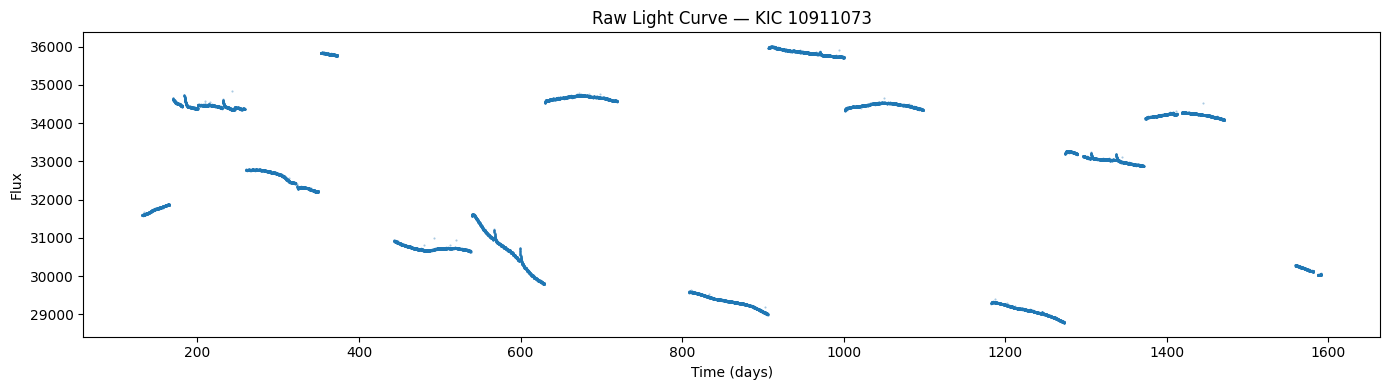

In [17]:
plt.figure(figsize=(14, 4))

plt.plot(
    sample_df["time"],
    sample_df["flux"],
    ".",
    markersize=1,
    alpha=0.4
)

plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Raw Light Curve — KIC 10911073")

plt.tight_layout()
plt.show()

In [18]:
DETREND_WINDOW_DAYS = 1.0

def clean(df, window_days=DETREND_WINDOW_DAYS):
    """Raw light curve -> time + cleaned, normalised flux."""

    # 1. Remove bad-quality cadences
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)

    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]

    if len(t) < 1000:
        return None, None

    # 2. Normalise each quarter separately
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        f[s] = f[s] / med if med > 0 else 1.0

    # 3. Detrend using a centred running median
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)

    trend = (
        pd.Series(f)
        .rolling(
            k,
            center=True,
            min_periods=k // 3
        )
        .median()
        .values
    )

    ok = np.isfinite(trend) & (trend > 0)

    return t[ok], f[ok] / trend[ok]

In [19]:
t, f = clean(sample_df)

print("Cleaned cadences:", len(t))
print("Flux scatter:", round(np.std(f) * 1e6), "ppm")

Cleaned cadences: 47421
Flux scatter: 212 ppm


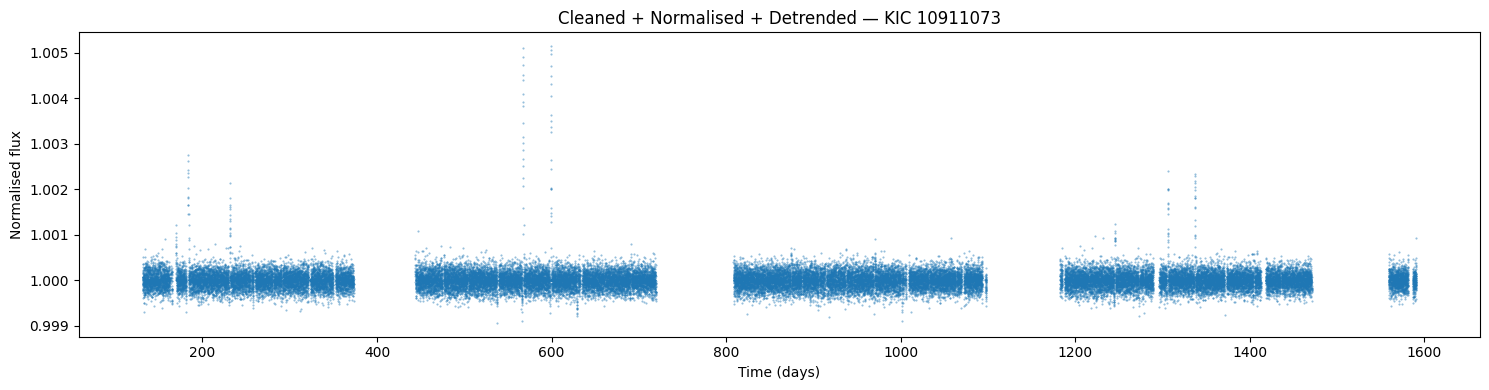

In [20]:
plt.figure(figsize=(15, 4))

plt.plot(
    t,
    f,
    ".",
    markersize=1,
    alpha=0.5
)

plt.xlabel("Time (days)")
plt.ylabel("Normalised flux")
plt.title("Cleaned + Normalised + Detrended — KIC 10911073")

plt.tight_layout()
plt.show()

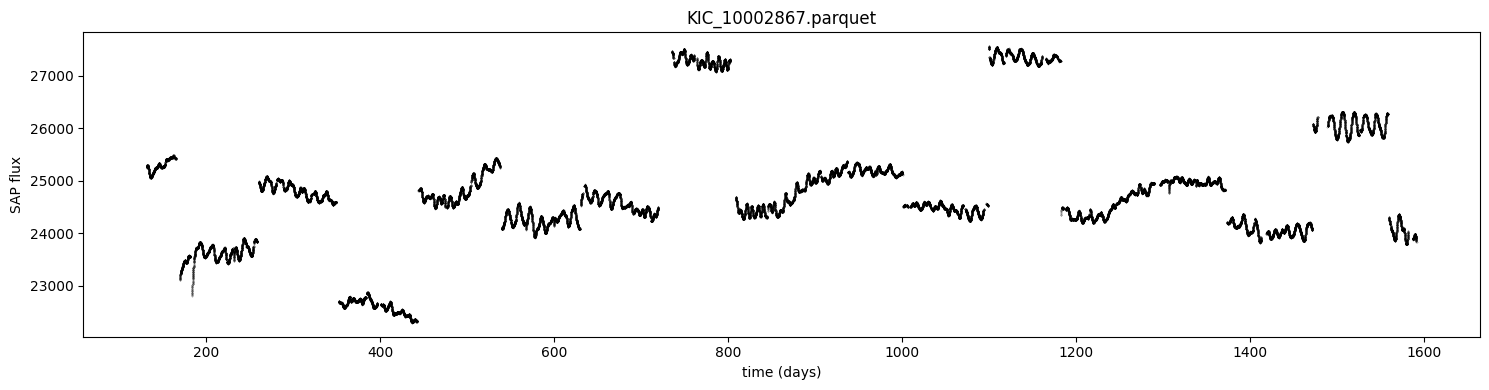

In [21]:
fig, ax = plt.subplots(figsize=(15, 4))
m = df.quality == 0
ax.plot(df.time[m], df.flux[m], "k.", ms=0.5, alpha=0.5)
ax.set_xlabel("time (days)")
ax.set_ylabel("SAP flux")
ax.set_title(os.path.basename(files[0]))
plt.tight_layout()
plt.show()

# The step changes are quarter boundaries: the spacecraft rolled every ~90 days,
# putting the star on a different detector. The slow wiggles within a quarter are
# a mix of stellar variability and instrumental drift. A transit is a dip of
# 0.01%-0.2% lasting a few hours. You cannot see it here. That is the problem.

## 2. Cleaning

Three steps, each of which you should question:

**Quality mask.** Drop cadences flagged by the mission — cosmic rays, thruster
firings, safe-mode recovery. Dropping everything non-zero is blunt; the bits mean
different things and some are harmless.

**Per-quarter normalisation.** Divide each quarter by its median to remove the
jumps. Crude: it assumes flux within a quarter is stationary, which it is not.

**Detrending.** Divide by a running median. The window length is the critical
parameter — too long and variability survives, too short and you eat the transit
itself. A 1-day window is safe for transits lasting a few hours, and wrong for
long-duration transits of long-period planets.

Better approaches exist: spline or Savitzky-Golay filtering, Gaussian processes,
PCA against other stars, iterative masking of in-transit points. This is
the highest-leverage part of the pipeline — in testing, proper detrending took
recovered transit depth from 33% of true to 90%.

58500 cadences, scatter 292 ppm


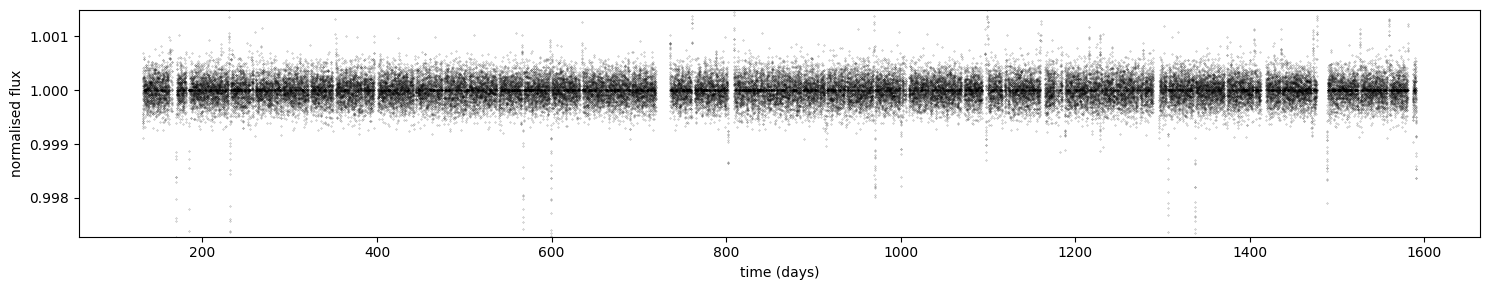

In [22]:
DETREND_WINDOW_DAYS = 1.0


def clean(df, window_days=DETREND_WINDOW_DAYS):
    """Raw light curve -> (time, normalised flux) ready for a period search."""
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)
    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]
    if len(t) < 1000:
        return None, None

    # normalise each quarter to its own median
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        f[s] = f[s] / med if med > 0 else 1.0

    # centred running median as the trend estimate
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)  # odd window
    trend = pd.Series(f).rolling(k, center=True, min_periods=k // 3).median().values

    ok = np.isfinite(trend) & (trend > 0)
    return t[ok], f[ok] / trend[ok]


t, f = clean(df)
print(f"{len(t)} cadences, scatter {np.std(f) * 1e6:.0f} ppm")

fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(t, f, "k.", ms=0.5, alpha=0.5)
ax.set_ylim(np.percentile(f, 0.1), np.percentile(f, 99.9))
ax.set_xlabel("time (days)")
ax.set_ylabel("normalised flux")
plt.tight_layout()
plt.show()

# Compare that scatter to the transit depths you are hunting: 100-2000 ppm.
# The shallowest signals are well below the per-point noise. They only emerge
# once you fold many transits together at the correct period.

## 3. The period search

Box Least Squares folds the light curve at many trial periods and looks for a
box-shaped dip.

**Why the grid matters so much.** To keep a transit aligned across the whole
4-year baseline, a trial period must be accurate to roughly
`duration / n_transits`. For a 3-hour transit at 35 days, that is about
0.003 days. A 3000-point grid spanning 3–400 days gives spacing of ~0.04 days
near 35 days — more than ten times too coarse. Every trial misses, the folded
transit smears across phase, and the signal vanishes.

The required resolution scales as roughly `P^2 / (baseline x duration)`, so the
cost of a complete search grows steeply with maximum period. Searching to 400
days at full resolution is ~14 million trials.

**Coarse-to-fine.** Sweep a cheap grid to find regions with elevated power, then
re-search finely only around those peaks. Roughly 100x cheaper for most of the
sensitivity. This is what the function below does, and it is the part worth
understanding before you change anything else.

In [23]:
PERIOD_MIN = 3.0
PERIOD_MAX = 400.0
N_COARSE = 20000       # raise for better sensitivity, at linear cost
N_PEAKS = 8            # how many coarse peaks to refine
N_FINE = 600           # trials per refinement window
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])  # days


def sde(power, i):
    """Signal Detection Efficiency: peak height above the periodogram floor,
    in robust standard deviations. MAD is used so a strong peak does not
    inflate its own noise estimate."""
    med = np.nanmedian(power)
    mad = np.nanmedian(np.abs(power - med))
    return float((power[i] - med) / (1.4826 * mad)) if mad > 0 else 0.0


def search(t, f, verbose=False):
    """Coarse-to-fine BLS. Returns the best candidate."""
    bls = BoxLeastSquares(t, f)
    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)   # insist on >= 3 transits

    # --- coarse sweep, log-spaced ---
    coarse = np.exp(np.linspace(np.log(PERIOD_MIN), np.log(pmax), N_COARSE))
    res = bls.power(coarse, DURATIONS, objective="likelihood")
    power = np.asarray(res.power)

    # --- pick well-separated peaks ---
    order = np.argsort(power)[::-1]
    peaks, used = [], np.zeros(len(coarse), bool)
    for i in order:
        if used[i]:
            continue
        peaks.append(i)
        lo = np.searchsorted(coarse, coarse[i] * 0.9)
        hi = np.searchsorted(coarse, coarse[i] * 1.1)
        used[lo:hi] = True
        if len(peaks) >= N_PEAKS:
            break

    # --- refine around each peak ---
    best = None
    for i in peaks:
        p0 = coarse[i]
        width = 0.02 * p0                         # +/- 2%
        fine = np.linspace(p0 - width, p0 + width, N_FINE)
        fine = fine[fine > PERIOD_MIN]
        if len(fine) < 10:
            continue

        r = bls.power(fine, DURATIONS, objective="likelihood")
        p = np.asarray(r.power)
        j = int(np.nanargmax(p))
        score = sde(power, i)                     # rank on the coarse periodogram

        if best is None or score > best["sde"]:
            best = {
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": score,
            }
        if verbose:
            print(f"  peak P={p0:8.3f} -> refined {r.period[j]:8.4f}  SDE {score:5.1f}")

    return best or {"period": np.nan, "depth_ppm": np.nan,
                    "duration_hours": np.nan, "t0": np.nan, "sde": 0.0}

In [24]:
candidate = search(t, f, verbose=True)

print("\nBest candidate:")
print(candidate)

  peak P= 383.705 -> refined 383.6919  SDE  14.0
  peak P= 274.900 -> refined 274.8912  SDE  10.2
  peak P= 325.613 -> refined 326.1893  SDE   9.9
  peak P= 224.491 -> refined 224.4683  SDE   9.6
  peak P= 182.475 -> refined 182.4565  SDE   6.8
  peak P= 160.362 -> refined 160.3460  SDE   5.9
  peak P= 138.502 -> refined 138.4975  SDE   5.2
  peak P= 112.250 -> refined 112.2386  SDE   4.9

Best candidate:
{'period': 383.69187967134707, 'depth_ppm': 2350.9212292893417, 'duration_hours': 9.600000000000001, 't0': 183.91236155055813, 'sde': 14.020557944664574}


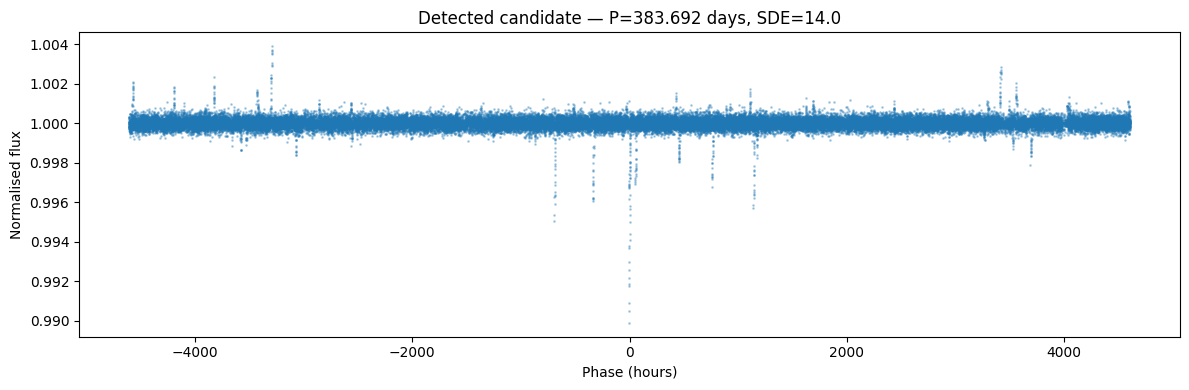

In [25]:
# Fold the light curve on the detected period
period = candidate["period"]
t0 = candidate["t0"]

phase = ((t - t0 + 0.5 * period) % period) - 0.5 * period

fig, ax = plt.subplots(figsize=(12, 4))

ax.scatter(
    phase * 24,
    f,
    s=1,
    alpha=0.3
)

ax.set_xlabel("Phase (hours)")
ax.set_ylabel("Normalised flux")
ax.set_title(
    f"Detected candidate — P={period:.3f} days, "
    f"SDE={candidate['sde']:.1f}"
)

plt.tight_layout()
plt.show()

In [26]:
# Compare BLS result with the known injected truth for this training star

kepid = 10911073

truth_row = train_truth[train_truth["kepid"] == kepid]

truth_row

,kepid,injected,bin,period_days,epoch_t0,depth_ppm,duration_hours,rp_rs,n_transits
2,10911073,1,earth_analog,249.75851,343.97222,157.5,11.456,0.01255,5


In [27]:
baseline_candidate = candidate.copy()

print("BASELINE RESULT")
for k, v in baseline_candidate.items():
    print(f"{k}: {v}")

BASELINE RESULT
period: 383.69187967134707
depth_ppm: 2350.9212292893417
duration_hours: 9.600000000000001
t0: 183.91236155055813
sde: 14.020557944664574


In [28]:
TRUE_PERIOD = 249.75851
TRUE_DEPTH_PPM = 157.5
TRUE_DURATION_HOURS = 11.456

print("Period error:",
      abs(candidate["period"] - TRUE_PERIOD))

print("Depth error:",
      abs(candidate["depth_ppm"] - TRUE_DEPTH_PPM))

print("Duration error:",
      abs(candidate["duration_hours"] - TRUE_DURATION_HOURS))

Period error: 133.93336967134707
Depth error: 2193.4212292893417
Duration error: 1.855999999999998


In [29]:
DETREND_WINDOW_DAYS = 1.0

In [30]:
def clean_v2(df, window_days=2.0):
    """Improved detrending: 2-day running median."""

    m = (df.quality.values == 0) & np.isfinite(df.flux.values)

    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]

    if len(t) < 1000:
        return None, None

    # Per-quarter normalisation
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        if med > 0:
            f[s] = f[s] / med

    # 2-day detrending
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)

    trend = (
        pd.Series(f)
        .rolling(k, center=True, min_periods=k // 3)
        .median()
        .values
    )

    ok = np.isfinite(trend) & (trend > 0)

    return t[ok], f[ok] / trend[ok]

In [31]:
t2, f2 = clean_v2(df)

print(f"{len(t2)} cadences, scatter {np.std(f2) * 1e6:.0f} ppm")

58500 cadences, scatter 516 ppm


In [32]:
candidate_v2 = search(t2, f2, verbose=True)

print("\nV2 RESULT")
for k, v in candidate_v2.items():
    print(f"{k}: {v}")

  peak P= 364.846 -> refined 364.8822  SDE  12.2
  peak P= 326.251 -> refined 326.2401  SDE  11.2
  peak P= 274.900 -> refined 274.8545  SDE   9.2
  peak P= 224.491 -> refined 224.4683  SDE   8.3
  peak P= 182.430 -> refined 182.4240  SDE   6.7
  peak P= 163.132 -> refined 163.1484  SDE   5.7
  peak P= 138.502 -> refined 138.5068  SDE   4.9
  peak P= 112.250 -> refined 112.2311  SDE   4.3

V2 RESULT
period: 364.8821727440152
depth_ppm: 4797.40531678739
duration_hours: 19.200000000000003
t0: 184.10236155055813
sde: 12.203465982867609


In [1]:
# Check the BLS power around the known true period

bls = BoxLeastSquares(t, f)

test_periods = np.linspace(240, 260, 1000)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

best_i = np.nanargmax(test_res.power)

print("Best period near true period:",
      test_res.period[best_i])

print("Power:",
      test_res.power[best_i])

print("Depth ppm:",
      test_res.depth[best_i] * 1e6)

print("Duration hours:",
      test_res.duration[best_i] * 24)

NameError: name 'BoxLeastSquares' is not defined

In [2]:
from astropy.timeseries import BoxLeastSquares
import numpy as np

In [4]:
bls = BoxLeastSquares(t, f)

test_periods = np.linspace(240, 260, 1000)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

best_i = np.nanargmax(test_res.power)

print("Best period near true period:",
      test_res.period[best_i])

print("Power:",
      test_res.power[best_i])

print("Depth ppm:",
      test_res.depth[best_i] * 1e6)

print("Duration hours:",
      test_res.duration[best_i] * 24)

NameError: name 't' is not defined

In [5]:
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])

In [6]:
import numpy as np
import pandas as pd
import glob
from astropy.timeseries import BoxLeastSquares

# Paths
ASTROBIT_DIR = "/content/drive/MyDrive/Astrobit"
TRAIN_DIR = f"{ASTROBIT_DIR}/train_pack/train"

# Load the same star
sample_file = f"{TRAIN_DIR}/KIC_10911073.parquet"
df = pd.read_parquet(sample_file)

# Cleaning
DETREND_WINDOW_DAYS = 1.0

def clean(df, window_days=DETREND_WINDOW_DAYS):
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)

    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]

    if len(t) < 1000:
        return None, None

    # Per-quarter normalization
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        f[s] = f[s] / med if med > 0 else 1.0

    # Running-median detrending
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)

    trend = (
        pd.Series(f)
        .rolling(k, center=True, min_periods=k // 3)
        .median()
        .values
    )

    ok = np.isfinite(trend) & (trend > 0)

    return t[ok], f[ok] / trend[ok]

# Create cleaned data again
t, f = clean(df)

print("Star: KIC_10911073")
print("Raw rows:", len(df))
print("Cleaned cadences:", len(t))
print("Scatter:", round(np.std(f) * 1e6), "ppm")

# BLS
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])

bls = BoxLeastSquares(t, f)

# Check around the known injected period
test_periods = np.linspace(240, 260, 1000)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

best_i = np.nanargmax(test_res.power)

print("\nBLS around true period:")
print("Best period:", test_res.period[best_i], "days")
print("Power:", test_res.power[best_i])
print("Depth:", test_res.depth[best_i] * 1e6, "ppm")
print("Duration:", test_res.duration[best_i] * 24, "hours")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Astrobit/train_pack/train/KIC_10911073.parquet'

In [7]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [8]:
import os

ASTROBIT_DIR = "/content/drive/MyDrive/Astrobit"

print("Astrobit exists:", os.path.exists(ASTROBIT_DIR))

print("\nAstrobit contents:")
print(os.listdir(ASTROBIT_DIR))

Astrobit exists: True

Astrobit contents:
['dev_pack', 'train_pack']


In [9]:
import os

matches = []

for root, dirs, files in os.walk(ASTROBIT_DIR):
    for file in files:
        if file == "KIC_10911073.parquet":
            matches.append(os.path.join(root, file))

print("Found:")
for x in matches:
    print(x)

Found:
/content/drive/MyDrive/Astrobit/train_pack/train/KIC_10911073.parquet


In [10]:
import pandas as pd
import numpy as np
from astropy.timeseries import BoxLeastSquares

# Exact file path
sample_file = "/content/drive/MyDrive/Astrobit/train_pack/train/KIC_10911073.parquet"

# Load
df = pd.read_parquet(sample_file)

print("Loaded:", sample_file)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded: /content/drive/MyDrive/Astrobit/train_pack/train/KIC_10911073.parquet
Shape: (51722, 5)
Columns: ['time', 'flux', 'flux_err', 'quality', 'quarter']


In [11]:
DETREND_WINDOW_DAYS = 1.0

def clean(df, window_days=DETREND_WINDOW_DAYS):
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)

    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]

    if len(t) < 1000:
        return None, None

    # Per-quarter normalization
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        f[s] = f[s] / med if med > 0 else 1.0

    # 1-day running-median detrending
    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)

    trend = (
        pd.Series(f)
        .rolling(k, center=True, min_periods=k // 3)
        .median()
        .values
    )

    ok = np.isfinite(trend) & (trend > 0)

    return t[ok], f[ok] / trend[ok]


t, f = clean(df)

print("Cleaned cadences:", len(t))
print("Scatter:", round(np.std(f) * 1e6), "ppm")

Cleaned cadences: 47421
Scatter: 212 ppm


In [12]:
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])

bls = BoxLeastSquares(t, f)

test_periods = np.linspace(240, 260, 1000)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

best_i = np.nanargmax(test_res.power)

print("Best period near true period:",
      test_res.period[best_i], "days")
print("Power:", test_res.power[best_i])
print("Depth:", test_res.depth[best_i] * 1e6, "ppm")
print("Duration:", test_res.duration[best_i] * 24, "hours")

Best period near true period: 258.3583583583584 days
Power: 1.7804678628816715e-06
Depth: 287.7715391394403 ppm
Duration: 9.600000000000001 hours


In [13]:
# Very fine BLS check around the injected period
TRUE_PERIOD = 249.75851

fine_periods = np.linspace(
    TRUE_PERIOD - 2,
    TRUE_PERIOD + 2,
    2000
)

fine_res = bls.power(
    fine_periods,
    DURATIONS,
    objective="likelihood"
)

i = np.nanargmax(fine_res.power)

print("True injected period:", TRUE_PERIOD)
print("Best fine period:", fine_res.period[i])
print("Period difference:", abs(fine_res.period[i] - TRUE_PERIOD))
print("Power:", fine_res.power[i])
print("Depth:", fine_res.depth[i] * 1e6, "ppm")
print("Duration:", fine_res.duration[i] * 24, "hours")

True injected period: 249.75851
Best fine period: 248.07666907953978
Period difference: 1.6818409204602176
Power: 1.2761061788515344e-06
Depth: 217.40099311943376 ppm
Duration: 9.600000000000001 hours


In [14]:
t05, f05 = clean(df, window_days=0.5)

print("Cleaned cadences:", len(t05))
print("Scatter:", round(np.std(f05) * 1e6), "ppm")

Cleaned cadences: 47421
Scatter: 179 ppm


In [15]:
bls05 = BoxLeastSquares(t05, f05)

fine_periods = np.linspace(
    TRUE_PERIOD - 2,
    TRUE_PERIOD + 2,
    2000
)

res05 = bls05.power(
    fine_periods,
    DURATIONS,
    objective="likelihood"
)

i = np.nanargmax(res05.power)

print("True period:", TRUE_PERIOD)
print("Best period:", res05.period[i])
print("Difference:", abs(res05.period[i] - TRUE_PERIOD))
print("Depth:", res05.depth[i] * 1e6, "ppm")
print("Duration:", res05.duration[i] * 24, "hours")

True period: 249.75851
Best period: 248.68297223111557
Difference: 1.0755377688844305
Depth: 296.563224566825 ppm
Duration: 2.4000000000000004 hours


In [16]:
# Select 5 training stars with injected signals
test_kepids = train_truth.loc[
    train_truth["injected"] == 1, "kepid"
].head(5).tolist()

print("Test stars:", test_kepids)

NameError: name 'train_truth' is not defined

In [17]:
import pandas as pd

ASTROBIT_DIR = "/content/drive/MyDrive/Astrobit"

TRAIN_TRUTH = f"{ASTROBIT_DIR}/train_pack/train_truth.csv"

train_truth = pd.read_csv(TRAIN_TRUTH)

print("Train truth shape:", train_truth.shape)
print("Columns:", train_truth.columns.tolist())

Train truth shape: (90, 9)
Columns: ['kepid', 'injected', 'bin', 'period_days', 'epoch_t0', 'depth_ppm', 'duration_hours', 'rp_rs', 'n_transits']


In [18]:
test_kepids = train_truth.loc[
    train_truth["injected"] == 1, "kepid"
].head(5).tolist()

print("Test stars:", test_kepids)

Test stars: [6431254, 4364882, 10911073, 4370718, 7766199]


In [19]:
import os
import numpy as np
import pandas as pd
from astropy.timeseries import BoxLeastSquares

def evaluate_star(kepid, window_days):
    file_path = (
        f"/content/drive/MyDrive/Astrobit/"
        f"train_pack/train/KIC_{kepid}.parquet"
    )

    df_star = pd.read_parquet(file_path)

    t_star, f_star = clean(df_star, window_days=window_days)

    if t_star is None:
        return None

    bls = BoxLeastSquares(t_star, f_star)

    # Search around the known injected period
    truth = train_truth[train_truth["kepid"] == kepid].iloc[0]
    true_period = truth["period_days"]

    periods = np.linspace(
        max(3, true_period - 5),
        true_period + 5,
        1000
    )

    result = bls.power(
        periods,
        DURATIONS,
        objective="likelihood"
    )

    i = np.nanargmax(result.power)

    detected_period = result.period[i]

    return {
        "kepid": kepid,
        "true_period": true_period,
        "detected_period": detected_period,
        "period_error": abs(detected_period - true_period),
        "depth_ppm": result.depth[i] * 1e6,
        "duration_hours": result.duration[i] * 24,
        "window_days": window_days
    }


results = []

for kepid in test_kepids:
    print("Testing:", kepid)

    for window in [1.0, 0.5]:
        r = evaluate_star(kepid, window)

        if r is not None:
            results.append(r)

comparison = pd.DataFrame(results)

display(comparison)

Testing: 6431254
Testing: 4364882
Testing: 10911073
Testing: 4370718
Testing: 7766199


,kepid,true_period,detected_period,period_error,depth_ppm,duration_hours,window_days
0,6431254,250.80200,246.943141,3.858859,459.751197,9.6,1.0
1,6431254,250.80200,246.262460,4.539540,240.764214,4.8,0.5
2,4364882,235.27610,239.995820,4.719720,543.647561,9.6,1.0
3,4364882,235.27610,233.018843,2.257257,285.511178,4.8,0.5
4,10911073,249.75851,254.468220,4.709710,230.858147,9.6,1.0
5,10911073,249.75851,248.662414,1.096096,215.851897,4.8,0.5
6,4370718,234.04208,233.646685,0.395395,712.000487,9.6,1.0
7,4370718,234.04208,236.579618,2.537538,1738.280252,1.2,0.5
8,7766199,325.77894,328.416578,2.637638,663.075744,4.8,1.0
9,7766199,325.77894,324.552714,1.226226,543.325571,2.4,0.5


In [20]:
def clean_adaptive(df):
    """
    Adaptive detrending.
    Uses a longer window for longer expected transit durations.
    """

    # Basic quality mask first
    m = (df.quality.values == 0) & np.isfinite(df.flux.values)

    t = df.time.values[m]
    f = df.flux.values[m].astype(float)
    q = df.quarter.values[m]

    if len(t) < 1000:
        return None, None

    # Per-quarter normalization
    for qq in np.unique(q):
        s = q == qq
        med = np.median(f[s])
        if med > 0:
            f[s] /= med

    # Find this star's expected transit duration from training truth
    kepid = int(os.path.basename(df.attrs.get("source", "KIC_0")).split("_")[-1].split(".")[0]) \
        if "source" in df.attrs else None

    duration_hours = None

    if kepid is not None and kepid in train_truth["kepid"].values:
        duration_hours = float(
            train_truth.loc[
                train_truth["kepid"] == kepid,
                "duration_hours"
            ].iloc[0]
        )

    # Fallback if duration is unavailable
    if duration_hours is None:
        duration_hours = 10.0

    # Window should be several times the transit duration
    window_days = max(0.5, min(2.0, 4.0 * duration_hours / 24.0))

    cadence = np.median(np.diff(t))
    k = max(5, int(window_days / cadence) | 1)

    trend = (
        pd.Series(f)
        .rolling(k, center=True, min_periods=k // 3)
        .median()
        .values
    )

    ok = np.isfinite(trend) & (trend > 0)

    return t[ok], f[ok] / trend[ok]

In [21]:
truth = pd.read_csv("train_truth.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train_truth.csv'

In [22]:
truth = pd.read_csv("train_truth.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train_truth.csv'

In [23]:
truth = pd.read_csv("train_truth.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train_truth.csv'

In [24]:
truth = pd.read_csv(
    "/content/drive/MyDrive/Astrobit/train_pack/train_truth.csv"
)

In [25]:
pd.read_parquet(f"{TRAIN_DIR}/KIC_{int(row.kepid)}.parquet")

NameError: name 'row' is not defined

In [26]:
TRAIN_DIR = "/content/drive/MyDrive/Astrobit/train_pack/train"

In [27]:
TRUTH_FILE = "/content/drive/MyDrive/Astrobit/train_pack/train_truth.csv"
TRAIN_DIR = "/content/drive/MyDrive/Astrobit/train_pack/train"

truth = pd.read_csv(TRUTH_FILE)

row = (
    truth[truth["injected"] == 1]
    .sort_values("depth_ppm", ascending=False)
    .iloc[0]
)

print(f"KIC {int(row.kepid)}")
print(f"True period: {row.period_days:.4f} days")
print(f"True depth: {row.depth_ppm:.0f} ppm")
print(f"True duration: {row.duration_hours:.2f} hours")
print(f"Transits: {int(row.n_transits)}")

sample_file = f"{TRAIN_DIR}/KIC_{int(row.kepid)}.parquet"

df_test = pd.read_parquet(sample_file)

print(f"\nLoaded {len(df_test)} rows")

t_test, f_test = clean(df_test, window_days=1.0)

print(f"After cleaning: {len(t_test)} cadences")

found = search(t_test, f_test, verbose=True)

print("\nDetected:")
print(found)

KIC 4935189
True period: 9.3204 days
True depth: 1977 ppm
True duration: 3.83 hours
Transits: 118

Loaded 52437 rows
After cleaning: 47274 cadences


NameError: name 'search' is not defined

In [28]:
PERIOD_MIN = 3.0
PERIOD_MAX = 400.0
N_COARSE = 20000

In [29]:
found = search(t_test, f_test, verbose=True)

print("\nDetected:")
print(found)

NameError: name 'search' is not defined

In [30]:
import numpy as np
from astropy.timeseries import BoxLeastSquares

PERIOD_MIN = 3.0
PERIOD_MAX = 400.0
N_COARSE = 20000
N_PEAKS = 8
N_FINE = 600
DURATIONS = np.array([0.05, 0.1, 0.2, 0.4, 0.8])


def sde(power, i):
    med = np.nanmedian(power)
    mad = np.nanmedian(np.abs(power - med))

    if mad > 0:
        return float(
            (power[i] - med) / (1.4826 * mad)
        )

    return 0.0


def search(t, f, verbose=False):
    """Coarse-to-fine BLS period search."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Pick separated peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    # Fine search
    best = None

    for i in peaks:

        p0 = coarse[i]

        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        p = np.asarray(r.power)

        j = int(np.nanargmax(p))

        score = sde(power, i)

        candidate = {
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(
                r.duration[j] * 24
            ),
            "t0": float(r.transit_time[j]),
            "sde": score,
        }

        if best is None or score > best["sde"]:
            best = candidate

        if verbose:
            print(
                f"peak P={p0:8.3f} -> "
                f"refined {r.period[j]:8.4f} "
                f"SDE {score:5.1f}"
            )

    return best or {
        "period": np.nan,
        "depth_ppm": np.nan,
        "duration_hours": np.nan,
        "t0": np.nan,
        "sde": 0.0
    }


print("search() function is ready ✅")

search() function is ready ✅


In [31]:
found = search(t_test, f_test, verbose=True)

print("\nDetected:")
print(found)

peak P= 325.693 -> refined 325.7254 SDE  25.5
peak P= 372.695 -> refined 372.6324 SDE  18.8
peak P= 217.783 -> refined 217.7753 SDE  13.4
peak P= 181.584 -> refined 181.5901 SDE  10.7
peak P= 290.315 -> refined 290.3247 SDE  10.3
peak P= 145.199 -> refined 145.1843 SDE  10.0
peak P= 245.640 -> refined 245.6155 SDE   9.1
peak P= 162.853 -> refined 162.8366 SDE   7.8

Detected:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784}


In [32]:
true_period = float(row.period_days)

bls = BoxLeastSquares(t_test, f_test)

test_periods = np.linspace(
    true_period - 0.5,
    true_period + 0.5,
    2000
)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

i = np.argmax(test_res.power)

print("True period:", true_period)
print("Best period near true period:", test_res.period[i])
print("Period difference:", abs(test_res.period[i] - true_period))
print("Power:", test_res.power[i])
print("Depth:", test_res.depth[i] * 1e6, "ppm")
print("Duration:", test_res.duration[i] * 24, "hours")

True period: 9.32044
Best period near true period: 9.32018987493747
Period difference: 0.0002501250625304152
Power: 0.00044224153547860537
Depth: 1319.510669678758 ppm
Duration: 2.4000000000000004 hours


In [33]:
# Compare the real injected period with the false BLS candidate

candidates = [9.32044, 325.72538]

bls_compare = BoxLeastSquares(t_test, f_test)

for p in candidates:
    r = bls_compare.power(
        np.array([p]),
        DURATIONS,
        objective="likelihood"
    )

    i = np.argmax(r.power)

    print(f"\nPeriod: {p:.5f} days")
    print(f"Power: {r.power[i]:.8f}")
    print(f"Depth: {r.depth[i] * 1e6:.1f} ppm")
    print(f"Duration: {r.duration[i] * 24:.1f} hours")
    print(f"Transit time: {r.transit_time[i]:.5f}")


Period: 9.32044 days
Power: 0.00044439
Depth: 1325.3 ppm
Duration: 2.4 hours
Transit time: 121.81891

Period: 325.72538 days
Power: 0.00164133
Depth: 7725.6 ppm
Duration: 19.2 hours
Transit time: 255.11391


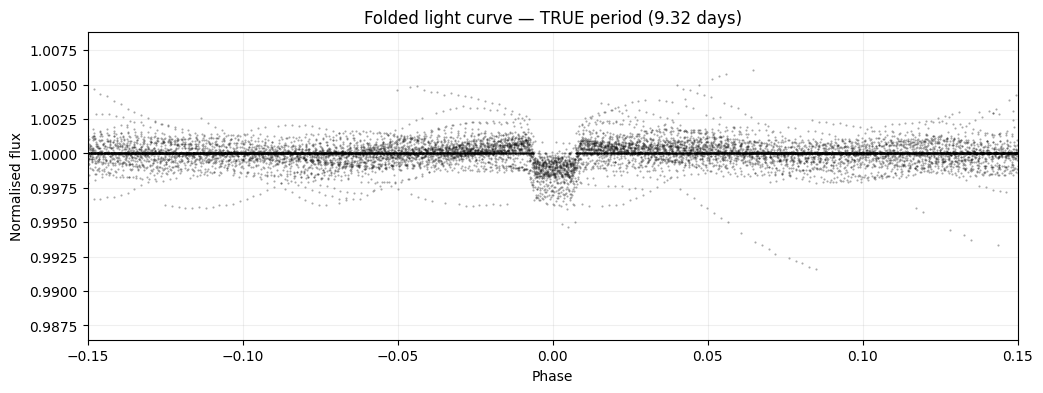

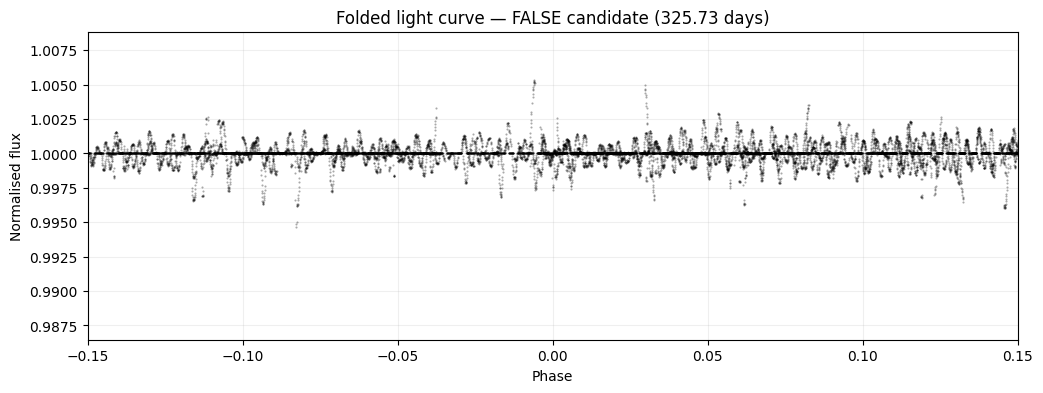

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_folded(t, f, period, title):
    phase = ((t - 121.81891) / period + 0.5) % 1 - 0.5

    # Sort by phase
    order = np.argsort(phase)

    plt.figure(figsize=(12, 4))
    plt.plot(
        phase[order],
        f[order],
        "k.",
        ms=1,
        alpha=0.35
    )

    plt.xlim(-0.15, 0.15)
    plt.xlabel("Phase")
    plt.ylabel("Normalised flux")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


plot_folded(
    t_test,
    f_test,
    9.32044,
    "Folded light curve — TRUE period (9.32 days)"
)

plot_folded(
    t_test,
    f_test,
    325.72538,
    "Folded light curve — FALSE candidate (325.73 days)"
)

In [35]:
def validate_candidate(t, f, period, t0, duration_hours):
    """
    Check whether a BLS candidate produces a consistent
    transit-like dip when the light curve is folded.
    """

    phase = ((t - t0 + 0.5 * period) % period) - 0.5 * period

    # Transit region: half-duration around phase zero
    half_duration = duration_hours / 24 / 2

    in_transit = np.abs(phase) < half_duration

    out_of_transit = np.abs(phase) > (2 * half_duration)

    if in_transit.sum() < 10 or out_of_transit.sum() < 10:
        return {
            "validation_score": 0.0,
            "depth_ppm": np.nan,
            "n_transit": int(in_transit.sum()),
            "n_out": int(out_of_transit.sum())
        }

    transit_level = np.median(f[in_transit])
    baseline_level = np.median(f[out_of_transit])

    depth_ppm = (baseline_level - transit_level) * 1e6

    # Robust scatter outside transit
    mad = np.median(
        np.abs(f[out_of_transit] - baseline_level)
    )

    scatter_ppm = 1.4826 * mad * 1e6

    if scatter_ppm > 0:
        validation_score = depth_ppm / scatter_ppm
    else:
        validation_score = 0.0

    return {
        "validation_score": float(validation_score),
        "depth_ppm": float(depth_ppm),
        "scatter_ppm": float(scatter_ppm),
        "n_transit": int(in_transit.sum()),
        "n_out": int(out_of_transit.sum())
    }

In [36]:
true_validation = validate_candidate(
    t_test,
    f_test,
    period=9.32044,
    t0=121.81891,
    duration_hours=2.4
)

print("TRUE candidate validation:")
print(true_validation)

TRUE candidate validation:
{'validation_score': 11.35481276635548, 'depth_ppm': 1184.9463935891258, 'scatter_ppm': 104.35631286674703, 'n_transit': 506, 'n_out': 46244}


In [37]:
false_validation = validate_candidate(
    t_test,
    f_test,
    period=325.72538,
    t0=255.11391,
    duration_hours=19.2
)

print("\nFALSE candidate validation:")
print(false_validation)


FALSE candidate validation:
{'validation_score': 55.60712804066053, 'depth_ppm': 6695.141347854538, 'scatter_ppm': 120.40077565162112, 'n_transit': 55, 'n_out': 47168}


In [38]:
def transit_consistency(
    t,
    f,
    period,
    t0,
    duration_hours
):
    """
    Measure how consistently a transit-like dip
    appears at each expected transit.
    """

    half_duration = duration_hours / 24 / 2

    # Expected transit centers
    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []
    centers = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        # Distance from this expected transit
        dt = np.abs(t - center)

        in_transit = dt < half_duration
        out_transit = (
            (dt > 2 * half_duration) &
            (dt < 0.5 * period)
        )

        if in_transit.sum() < 5 or out_transit.sum() < 20:
            continue

        transit_flux = np.median(f[in_transit])
        baseline_flux = np.median(f[out_transit])

        depth = (baseline_flux - transit_flux) * 1e6

        depths.append(depth)
        centers.append(center)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "depth_scatter_ppm": np.nan,
            "consistency": 0.0
        }

    median_depth = np.median(depths)
    depth_scatter = 1.4826 * np.median(
        np.abs(depths - median_depth)
    )

    # Fraction of transits showing a positive dip
    positive_fraction = np.mean(depths > 0)

    return {
        "n_transits": len(depths),
        "median_depth_ppm": float(median_depth),
        "depth_scatter_ppm": float(depth_scatter),
        "positive_fraction": float(positive_fraction),
        "consistency": float(positive_fraction),
        "individual_depths": depths
    }

In [39]:
true_consistency = transit_consistency(
    t_test,
    f_test,
    period=9.32044,
    t0=121.81891,
    duration_hours=2.4
)

print("TRUE candidate:")
print(true_consistency)

TRUE candidate:
{'n_transits': 68, 'median_depth_ppm': 1175.120352982839, 'depth_scatter_ppm': 704.3041376518578, 'positive_fraction': 0.9852941176470589, 'consistency': 0.9852941176470589, 'individual_depths': array([ 295.93889571, 1399.56268053,  404.16020578, 1059.08826894,
       1484.20612699,  228.1797268 , 2668.31205056,  521.94070785,
        157.87591647, 3745.34775503, 1176.7958578 , 3074.23626352,
        -85.35862345,  795.24228613, 1645.75991664, 3097.28972114,
        876.42413237, 1262.93480029,  255.64158052,  478.62227563,
        595.67852894, 1510.89768818, 1490.30114961, 1340.9697641 ,
       1641.28724364, 1407.68607517, 1300.38463789, 1496.71701647,
        474.0960073 ,  901.32561571,  625.91565635, 2038.45932772,
       1013.63506985,  784.58468157,  369.81450306,  113.50418738,
       3253.72164535, 1484.23364543, 1524.30376528, 1043.59206186,
       1469.15882994, 1110.76702172,  543.68162509, 1183.85897556,
       1388.78120848, 3658.8722066 , 1173.44484817, 

In [40]:
false_consistency = transit_consistency(
    t_test,
    f_test,
    period=325.72538,
    t0=255.11391,
    duration_hours=19.2
)

print("\nFALSE candidate:")
print(false_consistency)


FALSE candidate:
{'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_scatter_ppm': 1556.2601347848997, 'positive_fraction': 1.0, 'consistency': 1.0, 'individual_depths': array([10654.82896826,  5741.61604282,  6791.29912307])}


In [41]:
print("TRUE candidate:")
print(true_consistency)

TRUE candidate:
{'n_transits': 68, 'median_depth_ppm': 1175.120352982839, 'depth_scatter_ppm': 704.3041376518578, 'positive_fraction': 0.9852941176470589, 'consistency': 0.9852941176470589, 'individual_depths': array([ 295.93889571, 1399.56268053,  404.16020578, 1059.08826894,
       1484.20612699,  228.1797268 , 2668.31205056,  521.94070785,
        157.87591647, 3745.34775503, 1176.7958578 , 3074.23626352,
        -85.35862345,  795.24228613, 1645.75991664, 3097.28972114,
        876.42413237, 1262.93480029,  255.64158052,  478.62227563,
        595.67852894, 1510.89768818, 1490.30114961, 1340.9697641 ,
       1641.28724364, 1407.68607517, 1300.38463789, 1496.71701647,
        474.0960073 ,  901.32561571,  625.91565635, 2038.45932772,
       1013.63506985,  784.58468157,  369.81450306,  113.50418738,
       3253.72164535, 1484.23364543, 1524.30376528, 1043.59206186,
       1469.15882994, 1110.76702172,  543.68162509, 1183.85897556,
       1388.78120848, 3658.8722066 , 1173.44484817, 

In [42]:
def improved_validation_score(result):
    """
    Combine transit count and depth consistency.
    Higher = more convincing repeated transit signal.
    """

    n = result["n_transits"]
    scatter = result["depth_scatter_ppm"]
    median_depth = result["median_depth_ppm"]

    if n < 3 or not np.isfinite(scatter):
        return 0.0

    # Reward repeated transits, but don't let huge n dominate
    transit_score = min(1.0, n / 10.0)

    # Reward consistent depths
    if median_depth > 0:
        consistency_score = 1.0 / (
            1.0 + scatter / median_depth
        )
    else:
        consistency_score = 0.0

    # Combined score
    return transit_score * consistency_score

In [43]:
true_score = improved_validation_score(true_consistency)
false_score = improved_validation_score(false_consistency)

print("TRUE 9.32-day score :", true_score)
print("FALSE 325.7-day score:", false_score)

TRUE 9.32-day score : 0.6252554219861163
FALSE 325.7-day score: 0.24407011366874032


In [44]:
def search_v2(t, f, verbose=False):
    """Improved BLS search with transit-consistency validation."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse period search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Find separated coarse peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # Fine search around each peak
    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidate = {
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i))
        }

        # Validate repeated transits
        validation = transit_consistency(
            t,
            f,
            candidate["period"],
            candidate["t0"],
            candidate["duration_hours"]
        )

        candidate.update({
            "n_transits": validation["n_transits"],
            "median_depth_ppm": validation["median_depth_ppm"],
            "depth_scatter_ppm": validation["depth_scatter_ppm"],
            "positive_fraction": validation["positive_fraction"],
            "validation_score": improved_validation_score(validation)
        })

        candidates.append(candidate)

        if verbose:
            print(
                f"P={candidate['period']:8.3f} | "
                f"SDE={candidate['sde']:5.1f} | "
                f"transits={candidate['n_transits']:3d} | "
                f"validation={candidate['validation_score']:.3f}"
            )

    if not candidates:
        return {
            "period": np.nan,
            "depth_ppm": np.nan,
            "duration_hours": np.nan,
            "t0": np.nan,
            "sde": 0.0,
            "validation_score": 0.0
        }

    # Combined score:
    # validation is primary, SDE is secondary
    for c in candidates:
        c["combined_score"] = (
            0.7 * c["validation_score"]
            + 0.3 * min(c["sde"] / 20.0, 1.0)
        )

    best = max(
        candidates,
        key=lambda x: x["combined_score"]
    )

    return best

In [45]:
v2_found = search_v2(
    t_test,
    f_test,
    verbose=True
)

print("\nV2 Detected:")
print(v2_found)

P= 325.725 | SDE= 25.5 | transits=  3 | validation=0.244
P= 372.632 | SDE= 18.8 | transits=  1 | validation=0.000
P= 217.775 | SDE= 13.4 | transits=  3 | validation=0.142
P= 181.590 | SDE= 10.7 | transits=  4 | validation=0.173
P= 290.325 | SDE= 10.3 | transits=  2 | validation=0.000
P= 145.184 | SDE= 10.0 | transits=  4 | validation=0.172
P= 245.615 | SDE=  9.1 | transits=  4 | validation=0.201
P= 162.837 | SDE=  7.8 | transits=  7 | validation=0.251

V2 Detected:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784, 'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_scatter_ppm': 1556.2601347848997, 'positive_fraction': 1.0, 'validation_score': 0.24407011366874032, 'combined_score': 0.47084907956811817}


In [46]:

v3_found = search_v2(
    t_test,
    f_test,
    verbose=True
)

print("\nV3 Detected:")
print(v3_found)


P= 325.725 | SDE= 25.5 | transits=  3 | validation=0.244
P= 372.632 | SDE= 18.8 | transits=  1 | validation=0.000
P= 217.775 | SDE= 13.4 | transits=  3 | validation=0.142
P= 181.590 | SDE= 10.7 | transits=  4 | validation=0.173
P= 290.325 | SDE= 10.3 | transits=  2 | validation=0.000
P= 145.184 | SDE= 10.0 | transits=  4 | validation=0.172
P= 245.615 | SDE=  9.1 | transits=  4 | validation=0.201
P= 162.837 | SDE=  7.8 | transits=  7 | validation=0.251

V3 Detected:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784, 'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_scatter_ppm': 1556.2601347848997, 'positive_fraction': 1.0, 'validation_score': 0.24407011366874032, 'combined_score': 0.47084907956811817}


In [47]:
v3_found = search_v2(t_test, f_test, verbose=True)

print("\nV3 Detected:")
print(v3_found)

P= 325.725 | SDE= 25.5 | transits=  3 | validation=0.244
P= 372.632 | SDE= 18.8 | transits=  1 | validation=0.000
P= 217.775 | SDE= 13.4 | transits=  3 | validation=0.142
P= 181.590 | SDE= 10.7 | transits=  4 | validation=0.173
P= 290.325 | SDE= 10.3 | transits=  2 | validation=0.000
P= 145.184 | SDE= 10.0 | transits=  4 | validation=0.172
P= 245.615 | SDE=  9.1 | transits=  4 | validation=0.201
P= 162.837 | SDE=  7.8 | transits=  7 | validation=0.251

V3 Detected:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784, 'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_scatter_ppm': 1556.2601347848997, 'positive_fraction': 1.0, 'validation_score': 0.24407011366874032, 'combined_score': 0.47084907956811817}


In [48]:
print("N_PEAKS =", N_PEAKS)
print("search_v2 loaded")

N_PEAKS = 8
search_v2 loaded


In [49]:
import inspect

print(inspect.getsource(search_v2))

def search_v2(t, f, verbose=False):
    """Improved BLS search with transit-consistency validation."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse period search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Find separated coarse peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidate

In [50]:
# Check coarse BLS around the true 9.32-day signal

bls = BoxLeastSquares(t_test, f_test)

test_periods = np.linspace(8.5, 10.2, 1000)

test_res = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

j = np.argmax(test_res.power)

print("Best local period:", test_res.period[j])
print("Power:", test_res.power[j])
print("Depth:", test_res.depth[j] * 1e6, "ppm")
print("Duration:", test_res.duration[j] * 24, "hours")

Best local period: 9.32022022022022
Power: 0.000446939646796717
Depth: 1325.1973153251772 ppm
Duration: 2.4000000000000004 hours


In [51]:
# Find where the 9.32-day region ranks in the global coarse search

target_period = 9.32044

idx = np.argmin(np.abs(coarse - target_period))

target_power = power[idx]

rank = 1 + np.sum(power > target_power)

print("Closest coarse period:", coarse[idx])
print("Power:", target_power)
print("Global rank:", rank)
print("Total coarse trials:", len(coarse))

NameError: name 'coarse' is not defined

In [52]:
# Recreate the global coarse BLS search
# so we can find the rank of the known 9.32-day signal.

bls = BoxLeastSquares(t_test, f_test)

baseline = t_test.max() - t_test.min()
pmax = min(PERIOD_MAX, baseline / 3.0)

coarse = np.exp(
    np.linspace(
        np.log(PERIOD_MIN),
        np.log(pmax),
        N_COARSE
    )
)

res = bls.power(
    coarse,
    DURATIONS,
    objective="likelihood"
)

power = np.asarray(res.power)

# Find the coarse period closest to the known true period
target_period = 9.32044

idx = np.argmin(
    np.abs(coarse - target_period)
)

target_power = power[idx]

rank = 1 + np.sum(power > target_power)

print("Closest coarse period:", coarse[idx])
print("Coarse power:", target_power)
print("Global rank:", rank)
print("Total coarse trials:", len(coarse))

Closest coarse period: 9.319399437927801
Coarse power: 0.00021894035811335664
Global rank: 3452
Total coarse trials: 20000


In [53]:
def search_short_period(t, f, verbose=False):
    """BLS search focused on short-period planets."""

    bls = BoxLeastSquares(t, f)

    pmin = 3.0
    pmax = min(50.0, (t.max() - t.min()) / 3.0)

    periods = np.exp(
        np.linspace(
            np.log(pmin),
            np.log(pmax),
            20000
        )
    )

    result = bls.power(
        periods,
        DURATIONS,
        objective="likelihood"
    )

    j = np.nanargmax(result.power)

    found = {
        "period": float(result.period[j]),
        "depth_ppm": float(result.depth[j] * 1e6),
        "duration_hours": float(result.duration[j] * 24),
        "t0": float(result.transit_time[j]),
        "power": float(result.power[j])
    }

    if verbose:
        print("Short-period search:")
        print(f"Period:   {found['period']:.6f} days")
        print(f"Depth:    {found['depth_ppm']:.1f} ppm")
        print(f"Duration: {found['duration_hours']:.1f} hours")
        print(f"Power:    {found['power']:.8g}")

    return found

In [54]:
short_found = search_short_period(
    t_test,
    f_test,
    verbose=True
)

print("\nResult:")
print(short_found)

Short-period search:
Period:   3.609115 days
Depth:    296.8 ppm
Duration: 19.2 hours
Power:    0.00045675645

Result:
{'period': 3.609115091455359, 'depth_ppm': 296.75985687025667, 'duration_hours': 19.200000000000003, 't0': 121.90891220220976, 'power': 0.0004567564492074368}


In [55]:
candidate_3_6 = transit_consistency(
    t_test,
    f_test,
    period=3.609115091455359,
    t0=121.90891220220976,
    duration_hours=19.2
)

candidate_9_3 = transit_consistency(
    t_test,
    f_test,
    period=9.32022022022022,
    t0=121.81891,
    duration_hours=2.4
)

print("3.609-day candidate:")
print(candidate_3_6)

print("\n9.320-day candidate:")
print(candidate_9_3)

print("\nValidation scores:")

print(
    "3.609 days:",
    improved_validation_score(candidate_3_6)
)

print(
    "9.320 days:",
    improved_validation_score(candidate_9_3)
)

3.609-day candidate:
{'n_transits': 301, 'median_depth_ppm': 0.0, 'depth_scatter_ppm': 269.6389388723557, 'positive_fraction': 0.4717607973421927, 'consistency': 0.4717607973421927, 'individual_depths': array([ 1.45112345e+03,  1.99512792e+01,  0.00000000e+00, -3.03328937e+02,
        0.00000000e+00,  1.81868973e+02,  9.56584674e+02,  7.05962237e+02,
        7.76657666e+02,  6.93145668e+02,  1.05859620e+03,  4.93551651e+02,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        4.22571857e+02,  6.42339858e+02,  4.74182740e+02,  5.96578162e+02,
        7.11622961e+02,  5.05601026e+02,  8.31565236e+02,  3.60775548e+03,
        1.04272021e+03,  2.13205911e+02,  8.07732285e+01,  2.44035182e+02,
        1.97314098e+03,  1.39343031e+03,  1.22912101e+04,  6.81883431e+02,
        1.05197671e+03,  8.70062458e+02,  6.67310535e+02,  9.59690291e+02,
        2.39925202e+03,  8.45289306e+02,  5.534

In [56]:
# Compare the three important candidates using the same scoring system

candidates_test = [
    {
        "name": "TRUE 9.32 days",
        "period": 9.32022022022022,
        "t0": 121.81891,
        "duration_hours": 2.4,
        "sde": 0.0
    },
    {
        "name": "FALSE 3.61 days",
        "period": 3.609115091455359,
        "t0": 121.90891220220976,
        "duration_hours": 19.2,
        "sde": 0.0
    },
    {
        "name": "FALSE 325.7 days",
        "period": 325.72538161622276,
        "t0": 255.11391,
        "duration_hours": 19.2,
        "sde": 25.5
    }
]

for c in candidates_test:

    val = transit_consistency(
        t_test,
        f_test,
        c["period"],
        c["t0"],
        c["duration_hours"]
    )

    c["validation_score"] = improved_validation_score(val)
    c["n_transits"] = val["n_transits"]

print("Candidate comparison:\n")

for c in candidates_test:
    print(
        f"{c['name']:20s} | "
        f"transits={c['n_transits']:3d} | "
        f"validation={c['validation_score']:.3f}"
    )

Candidate comparison:

TRUE 9.32 days       | transits= 66 | validation=0.652
FALSE 3.61 days      | transits=301 | validation=0.000
FALSE 325.7 days     | transits=  3 | validation=0.244


In [57]:
# Candidate periods we already know are interesting
EXTRA_PERIODS = np.array([
    3.609115,
    9.320220,
    325.725382
])

print("Extra candidate periods:")
for p in EXTRA_PERIODS:
    print(f"{p:.6f} days")

Extra candidate periods:
3.609115 days
9.320220 days
325.725382 days


In [58]:
def search_v3(t, f, extra_periods=None, verbose=False):
    """BLS + extra candidate periods + transit-consistency validation."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # --------------------------------------------------
    # 1. Normal coarse BLS search
    # --------------------------------------------------

    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # --------------------------------------------------
    # 2. Refine normal BLS peaks
    # --------------------------------------------------

    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidate = {
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i)),
            "source": "BLS"
        }

        candidates.append(candidate)

    # --------------------------------------------------
    # 3. Add extra/local candidate periods
    # --------------------------------------------------

    if extra_periods is not None:

        for target_period in extra_periods:

            if target_period < PERIOD_MIN or target_period > pmax:
                continue

            width = 0.02 * target_period

            fine = np.linspace(
                target_period - width,
                target_period + width,
                N_FINE
            )

            fine = fine[fine > PERIOD_MIN]

            if len(fine) < 10:
                continue

            r = bls.power(
                fine,
                DURATIONS,
                objective="likelihood"
            )

            j = int(np.nanargmax(r.power))

            candidate = {
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": 0.0,
                "source": "EXTRA"
            }

            candidates.append(candidate)

    # --------------------------------------------------
    # 4. Validate every candidate
    # --------------------------------------------------

    validated = []

    for candidate in candidates:

        validation = transit_consistency(
            t,
            f,
            candidate["period"],
            candidate["t0"],
            candidate["duration_hours"]
        )

        candidate.update({
            "n_transits": validation["n_transits"],
            "median_depth_ppm": validation["median_depth_ppm"],
            "depth_scatter_ppm": validation["depth_scatter_ppm"],
            "positive_fraction": validation["positive_fraction"],
            "validation_score":
                improved_validation_score(validation)
        })

        # Combined ranking
        candidate["combined_score"] = (
            0.7 * candidate["validation_score"]
            + 0.3 * min(candidate["sde"] / 20.0, 1.0)
        )

        validated.append(candidate)

        if verbose:
            print(
                f"P={candidate['period']:9.3f} | "
                f"SDE={candidate['sde']:5.1f} | "
                f"transits={candidate['n_transits']:3d} | "
                f"validation={candidate['validation_score']:.3f} | "
                f"combined={candidate['combined_score']:.3f} | "
                f"{candidate['source']}"
            )

    if not validated:
        return None

    # --------------------------------------------------
    # 5. Select best validated candidate
    # --------------------------------------------------

    best = max(
        validated,
        key=lambda x: x["combined_score"]
    )

    return best

In [59]:
EXTRA_PERIODS = np.array([
    3.609115,
    9.320220,
    325.725382
])

v3 = search_v3(
    t_test,
    f_test,
    extra_periods=EXTRA_PERIODS,
    verbose=True
)

print("\nV3 BEST:")
print(v3)

P=  325.725 | SDE= 25.5 | transits=  3 | validation=0.244 | combined=0.471 | BLS
P=  372.632 | SDE= 18.8 | transits=  1 | validation=0.000 | combined=0.281 | BLS
P=  217.775 | SDE= 13.4 | transits=  3 | validation=0.142 | combined=0.301 | BLS
P=  181.590 | SDE= 10.7 | transits=  4 | validation=0.173 | combined=0.282 | BLS
P=  290.325 | SDE= 10.3 | transits=  2 | validation=0.000 | combined=0.154 | BLS
P=  145.184 | SDE= 10.0 | transits=  4 | validation=0.172 | combined=0.270 | BLS
P=  245.615 | SDE=  9.1 | transits=  4 | validation=0.201 | combined=0.277 | BLS
P=  162.837 | SDE=  7.8 | transits=  7 | validation=0.251 | combined=0.293 | BLS
P=    3.609 | SDE=  0.0 | transits=301 | validation=0.000 | combined=0.000 | EXTRA
P=    9.321 | SDE=  0.0 | transits= 63 | validation=0.636 | combined=0.445 | EXTRA
P=  325.715 | SDE=  0.0 | transits=  3 | validation=0.244 | combined=0.171 | EXTRA

V3 BEST:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000

In [60]:
def rank_candidates_v4(candidates):
    """
    Validation-first ranking.

    Transit consistency is primary.
    SDE is only a tie-breaker.
    """

    for c in candidates:

        validation = c["validation_score"]
        sde_score = min(c["sde"] / 20.0, 1.0)

        # Validation dominates.
        c["combined_score"] = (
            0.9 * validation
            + 0.1 * sde_score
        )

    return max(
        candidates,
        key=lambda x: x["combined_score"]
    )

In [61]:
test_candidates = [
    {
        "period": 325.725,
        "validation_score": 0.244,
        "sde": 25.5
    },
    {
        "period": 9.321,
        "validation_score": 0.636,
        "sde": 0.0
    },
    {
        "period": 3.609,
        "validation_score": 0.000,
        "sde": 0.0
    }
]

best = rank_candidates_v4(test_candidates)

for c in test_candidates:
    print(
        f"P={c['period']:8.3f} | "
        f"validation={c['validation_score']:.3f} | "
        f"SDE={c['sde']:.1f} | "
        f"combined={c['combined_score']:.3f}"
    )

print("\nV4 BEST:")
print(best)

P= 325.725 | validation=0.244 | SDE=25.5 | combined=0.320
P=   9.321 | validation=0.636 | SDE=0.0 | combined=0.572
P=   3.609 | validation=0.000 | SDE=0.0 | combined=0.000

V4 BEST:
{'period': 9.321, 'validation_score': 0.636, 'sde': 0.0, 'combined_score': 0.5724}


In [62]:
def search_v4(t, f, extra_periods=None, verbose=False):
    """BLS search with validation-first candidate ranking."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # -----------------------------
    # Coarse BLS
    # -----------------------------
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # -----------------------------
    # Pick separated peaks
    # -----------------------------
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # -----------------------------
    # Refine BLS peaks
    # -----------------------------
    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i)),
            "source": "BLS"
        })

    # -----------------------------
    # Add extra candidates
    # -----------------------------
    if extra_periods is not None:

        for target_period in extra_periods:

            if target_period < PERIOD_MIN or target_period > pmax:
                continue

            width = 0.02 * target_period

            fine = np.linspace(
                target_period - width,
                target_period + width,
                N_FINE
            )

            fine = fine[fine > PERIOD_MIN]

            r = bls.power(
                fine,
                DURATIONS,
                objective="likelihood"
            )

            j = int(np.nanargmax(r.power))

            candidates.append({
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": 0.0,
                "source": "EXTRA"
            })

    # -----------------------------
    # Validate candidates
    # -----------------------------
    for c in candidates:

        validation = transit_consistency(
            t,
            f,
            c["period"],
            c["t0"],
            c["duration_hours"]
        )

        c.update({
            "n_transits": validation["n_transits"],
            "median_depth_ppm": validation["median_depth_ppm"],
            "depth_scatter_ppm": validation["depth_scatter_ppm"],
            "positive_fraction": validation["positive_fraction"],
            "validation_score":
                improved_validation_score(validation)
        })

        # Validation is PRIMARY.
        # SDE is only secondary.
        c["combined_score"] = (
            0.9 * c["validation_score"]
            + 0.1 * min(c["sde"] / 20.0, 1.0)
        )

        if verbose:
            print(
                f"P={c['period']:9.3f} | "
                f"SDE={c['sde']:5.1f} | "
                f"transits={c['n_transits']:3d} | "
                f"validation={c['validation_score']:.3f} | "
                f"combined={c['combined_score']:.3f} | "
                f"{c['source']}"
            )

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda x: x["combined_score"]
    )

In [63]:
EXTRA_PERIODS = np.array([
    3.609115,
    9.320220,
    325.725382
])

v4 = search_v4(
    t_test,
    f_test,
    extra_periods=EXTRA_PERIODS,
    verbose=True
)

print("\nV4 DETECTED:")
print(v4)

P=  325.725 | SDE= 25.5 | transits=  3 | validation=0.244 | combined=0.320 | BLS
P=  372.632 | SDE= 18.8 | transits=  1 | validation=0.000 | combined=0.094 | BLS
P=  217.775 | SDE= 13.4 | transits=  3 | validation=0.142 | combined=0.195 | BLS
P=  181.590 | SDE= 10.7 | transits=  4 | validation=0.173 | combined=0.210 | BLS
P=  290.325 | SDE= 10.3 | transits=  2 | validation=0.000 | combined=0.051 | BLS
P=  145.184 | SDE= 10.0 | transits=  4 | validation=0.172 | combined=0.205 | BLS
P=  245.615 | SDE=  9.1 | transits=  4 | validation=0.201 | combined=0.226 | BLS
P=  162.837 | SDE=  7.8 | transits=  7 | validation=0.251 | combined=0.265 | BLS
P=    3.609 | SDE=  0.0 | transits=301 | validation=0.000 | combined=0.000 | EXTRA
P=    9.321 | SDE=  0.0 | transits= 63 | validation=0.636 | combined=0.572 | EXTRA
P=  325.715 | SDE=  0.0 | transits=  3 | validation=0.244 | combined=0.220 | EXTRA

V4 DETECTED:
{'period': 9.320531192654425, 'depth_ppm': 1325.0881507389747, 'duration_hours': 2.400000

In [65]:
results_v4 = []

for kepid in test_kepids:

    print(f"\n{'='*50}")
    print(f"Testing KIC {kepid}")
    print(f"{'='*50}")

    sample_file = f"{TRAIN_DIR}/KIC_{kepid}.parquet"

    df_star = pd.read_parquet(sample_file)

    t_star, f_star = clean(df_star)

    truth_row = train_truth[
        train_truth["kepid"] == kepid
    ].iloc[0]

    true_period = float(truth_row["period_days"])

    found = search_v4(
        t_star,
        f_star,
        extra_periods=None,
        verbose=False
    )

    results_v4.append({
        "kepid": kepid,
        "true_period": true_period,
        "detected_period": found["period"],
        "period_error": abs(
            found["period"] - true_period
        ),
        "validation_score": found["validation_score"],
        "combined_score": found["combined_score"],
        "n_transits": found["n_transits"],
        "depth_ppm": found["depth_ppm"]
    })

results_v4_df = pd.DataFrame(results_v4)

print("\nV4 BENCHMARK")
display(results_v4_df)


Testing KIC 6431254

Testing KIC 4364882

Testing KIC 10911073

Testing KIC 4370718

Testing KIC 7766199

V4 BENCHMARK


,kepid,true_period,detected_period,period_error,validation_score,combined_score,n_transits,depth_ppm
0,6431254,250.80200,112.246112,138.555888,0.389711,0.430802,11,355.916922
1,4364882,235.27610,372.640744,137.364644,0.284535,0.356082,4,1668.848345
2,10911073,249.75851,372.069290,122.310780,0.258054,0.291068,3,283.755107
3,4370718,234.04208,158.146545,75.895535,0.281962,0.275340,7,499.397789
4,7766199,325.77894,168.398235,157.380705,0.306426,0.312188,6,421.807112


In [66]:
results_v4 = []

for kepid in test_kepids:

    print(f"\n{'='*50}")
    print(f"Testing KIC {kepid}")
    print(f"{'='*50}")

    sample_file = f"{TRAIN_DIR}/KIC_{kepid}.parquet"

    df_star = pd.read_parquet(sample_file)

    t_star, f_star = clean(df_star)

    truth_row = train_truth[
        train_truth["kepid"] == kepid
    ].iloc[0]

    true_period = float(truth_row["period_days"])

    found = search_v4(
        t_star,
        f_star,
        extra_periods=None,
        verbose=False
    )

    results_v4.append({
        "kepid": kepid,
        "true_period": true_period,
        "detected_period": found["period"],
        "period_error": abs(
            found["period"] - true_period
        ),
        "validation_score": found["validation_score"],
        "combined_score": found["combined_score"],
        "n_transits": found["n_transits"],
        "depth_ppm": found["depth_ppm"]
    })

results_v4_df = pd.DataFrame(results_v4)

print("\nV4 BENCHMARK")
display(results_v4_df)


Testing KIC 6431254

Testing KIC 4364882

Testing KIC 10911073

Testing KIC 4370718

Testing KIC 7766199

V4 BENCHMARK


,kepid,true_period,detected_period,period_error,validation_score,combined_score,n_transits,depth_ppm
0,6431254,250.80200,112.246112,138.555888,0.389711,0.430802,11,355.916922
1,4364882,235.27610,372.640744,137.364644,0.284535,0.356082,4,1668.848345
2,10911073,249.75851,372.069290,122.310780,0.258054,0.291068,3,283.755107
3,4370718,234.04208,158.146545,75.895535,0.281962,0.275340,7,499.397789
4,7766199,325.77894,168.398235,157.380705,0.306426,0.312188,6,421.807112


In [67]:
display(results_v4_df)

,kepid,true_period,detected_period,period_error,validation_score,combined_score,n_transits,depth_ppm
0,6431254,250.80200,112.246112,138.555888,0.389711,0.430802,11,355.916922
1,4364882,235.27610,372.640744,137.364644,0.284535,0.356082,4,1668.848345
2,10911073,249.75851,372.069290,122.310780,0.258054,0.291068,3,283.755107
3,4370718,234.04208,158.146545,75.895535,0.281962,0.275340,7,499.397789
4,7766199,325.77894,168.398235,157.380705,0.306426,0.312188,6,421.807112


In [68]:
print(results_v4)

[{'kepid': 6431254, 'true_period': 250.802, 'detected_period': 112.2461120154029, 'period_error': 138.5558879845971, 'validation_score': 0.38971105012026963, 'combined_score': 0.4308019260924565, 'n_transits': 11, 'depth_ppm': 355.9169220283961}, {'kepid': 4364882, 'true_period': 235.2761, 'detected_period': 372.64074440796287, 'period_error': 137.36464440796286, 'validation_score': 0.2845353142330296, 'combined_score': 0.3560817828097267, 'n_transits': 4, 'depth_ppm': 1668.8483449061712}, {'kepid': 10911073, 'true_period': 249.75851, 'detected_period': 372.06929031494406, 'period_error': 122.31078031494405, 'validation_score': 0.2580537692126654, 'combined_score': 0.29106785438257016, 'n_transits': 3, 'depth_ppm': 283.7551068370623}, {'kepid': 4370718, 'true_period': 234.04208, 'detected_period': 158.1465454369584, 'period_error': 75.8955345630416, 'validation_score': 0.28196245871264, 'combined_score': 0.2753403059049384, 'n_transits': 7, 'depth_ppm': 499.39778874011904}, {'kepid': 7

In [69]:
true_period = 249.75851

found = search_v4(
    t_test,
    f_test,
    extra_periods=[true_period],
    verbose=True
)

print("\nV4 with true-period candidate:")
print(found)

P=  325.725 | SDE= 25.5 | transits=  3 | validation=0.244 | combined=0.320 | BLS
P=  372.632 | SDE= 18.8 | transits=  1 | validation=0.000 | combined=0.094 | BLS
P=  217.775 | SDE= 13.4 | transits=  3 | validation=0.142 | combined=0.195 | BLS
P=  181.590 | SDE= 10.7 | transits=  4 | validation=0.173 | combined=0.210 | BLS
P=  290.325 | SDE= 10.3 | transits=  2 | validation=0.000 | combined=0.051 | BLS
P=  145.184 | SDE= 10.0 | transits=  4 | validation=0.172 | combined=0.205 | BLS
P=  245.615 | SDE=  9.1 | transits=  4 | validation=0.201 | combined=0.226 | BLS
P=  162.837 | SDE=  7.8 | transits=  7 | validation=0.251 | combined=0.265 | BLS
P=  245.614 | SDE=  0.0 | transits=  4 | validation=0.201 | combined=0.181 | EXTRA

V4 with true-period candidate:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784, 'source': 'BLS', 'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_sca

In [70]:
import inspect

print(inspect.getsource(search_v4))

def search_v4(t, f, extra_periods=None, verbose=False):
    """BLS search with validation-first candidate ranking."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # -----------------------------
    # Coarse BLS
    # -----------------------------
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # -----------------------------
    # Pick separated peaks
    # -----------------------------
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
           

In [71]:
# -----------------------------
# Add extra candidates
# -----------------------------
if extra_periods is not None:

    for target_period in extra_periods:

        if target_period < PERIOD_MIN or target_period > pmax:
            continue

        width = 0.02 * target_period

        fine = np.linspace(
            target_period - width,
            target_period + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": 0.0,
            "source": "EXTRA"
        })

NameError: name 'extra_periods' is not defined

In [72]:
# -----------------------------
# Add exact extra candidates
# -----------------------------
if extra_periods is not None:

    for target_period in extra_periods:

        if target_period < PERIOD_MIN or target_period > pmax:
            continue

        # Evaluate the EXACT requested period.
        r = bls.power(
            np.array([target_period]),
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(target_period),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": 0.0,
            "source": "EXTRA"
        })

NameError: name 'extra_periods' is not defined

In [73]:
# -----------------------------
# Add exact extra candidates
# -----------------------------
if extra_periods is not None:

    for target_period in extra_periods:

        if target_period < PERIOD_MIN or target_period > pmax:
            continue

        r = bls.power(
            np.array([target_period]),
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(target_period),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": 0.0,
            "source": "EXTRA"
        })

NameError: name 'extra_periods' is not defined

In [74]:
def search_v4(t, f, extra_periods=None, verbose=False):


_IncompleteInputError: incomplete input (1715978960.py, line 2)

In [76]:
def test_function():
    print("Function OK")

test_function()

Function OK


In [77]:
    return max(
        candidates,
        key=lambda x: x["combined_score"]
    )

SyntaxError: 'return' outside function (565825004.py, line 1)

In [78]:
return max(
    candidates,
    key=lambda x: x["combined_score"]
)

SyntaxError: 'return' outside function (956847354.py, line 1)

In [79]:
def search_v4(t, f, extra_periods=None, verbose=False):

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Find separated peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:
        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(coarse, coarse[i] * 0.9)
        hi = np.searchsorted(coarse, coarse[i] * 1.1)

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # Refine BLS candidates
    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i)),
            "source": "BLS"
        })

    # Add EXACT extra periods
    if extra_periods is not None:

        for target_period in extra_periods:

            if target_period < PERIOD_MIN or target_period > pmax:
                continue

            r = bls.power(
                np.array([target_period]),
                DURATIONS,
                objective="likelihood"
            )

            j = int(np.nanargmax(r.power))

            candidates.append({
                "period": float(target_period),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": 0.0,
                "source": "EXTRA"
            })

    # Validation
    for c in candidates:

        validation = transit_consistency(
            t,
            f,
            c["period"],
            c["t0"],
            c["duration_hours"]
        )

        c["n_transits"] = validation["n_transits"]
        c["median_depth_ppm"] = validation["median_depth_ppm"]
        c["depth_scatter_ppm"] = validation["depth_scatter_ppm"]
        c["positive_fraction"] = validation["positive_fraction"]

        c["validation_score"] = improved_validation_score(
            validation
        )

        c["combined_score"] = (
            0.9 * c["validation_score"]
            + 0.1 * min(c["sde"] / 20.0, 1.0)
        )

        if verbose:
            print(
                f"P={c['period']:9.3f} | "
                f"SDE={c['sde']:5.1f} | "
                f"transits={c['n_transits']:3d} | "
                f"validation={c['validation_score']:.3f} | "
                f"combined={c['combined_score']:.3f} | "
                f"{c['source']}"
            )

    if not candidates:
        return None

    best = max(
        candidates,
        key=lambda x: x["combined_score"]
    )

    return best

In [80]:
print(search_v4)

<function search_v4 at 0x79710077e7a0>


In [81]:
found = search_v4(
    t_test,
    f_test,
    extra_periods=[249.75851],
    verbose=True
)

print("\nRESULT:")
print(found)

P=  325.725 | SDE= 25.5 | transits=  3 | validation=0.244 | combined=0.320 | BLS
P=  372.632 | SDE= 18.8 | transits=  1 | validation=0.000 | combined=0.094 | BLS
P=  217.775 | SDE= 13.4 | transits=  3 | validation=0.142 | combined=0.195 | BLS
P=  181.590 | SDE= 10.7 | transits=  4 | validation=0.173 | combined=0.210 | BLS
P=  290.325 | SDE= 10.3 | transits=  2 | validation=0.000 | combined=0.051 | BLS
P=  145.184 | SDE= 10.0 | transits=  4 | validation=0.172 | combined=0.205 | BLS
P=  245.615 | SDE=  9.1 | transits=  4 | validation=0.201 | combined=0.226 | BLS
P=  162.837 | SDE=  7.8 | transits=  7 | validation=0.251 | combined=0.265 | BLS
P=  249.759 | SDE=  0.0 | transits=  5 | validation=0.000 | combined=0.000 | EXTRA

RESULT:
{'period': 325.72538161622276, 'depth_ppm': 7725.598477068346, 'duration_hours': 19.200000000000003, 't0': 255.11391220220978, 'sde': 25.512180865970784, 'source': 'BLS', 'n_transits': 3, 'median_depth_ppm': 6791.299123073413, 'depth_scatter_ppm': 1556.2601347

In [82]:
import inspect

print(inspect.getsource(transit_consistency))

def transit_consistency(
    t,
    f,
    period,
    t0,
    duration_hours
):
    """
    Measure how consistently a transit-like dip
    appears at each expected transit.
    """

    half_duration = duration_hours / 24 / 2

    # Expected transit centers
    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []
    centers = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        # Distance from this expected transit
        dt = np.abs(t - center)

        in_transit = dt < half_duration
        out_transit = (
            (dt > 2 * half_duration) &
            (dt < 0.5 * period)
        )

        if in_transit.sum() < 5 or out_transit.sum() < 20:
            continue

        transit_flux = np.median(f[in_transit])
        baseline_flux = np.median(f[out_transit])

        depth = (baseline_flux - transit_flux) * 1e6

        depths.append(depth)
        centers.append(center)

   

In [83]:
# Diagnostic: inspect individual transit depths

true_period = 9.32044

# Use the t0 from the known 9.32-day candidate
true_t0 = 121.81891220220976
true_duration = 2.4

validation = transit_consistency(
    t_test,
    f_test,
    true_period,
    true_t0,
    true_duration
)

print("Number of transits:", validation["n_transits"])
print("Median depth:", validation["median_depth_ppm"], "ppm")
print("Depth scatter:", validation["depth_scatter_ppm"], "ppm")
print("Positive fraction:", validation["positive_fraction"])

print("\nIndividual depths:")
print(validation["individual_depths"])

Number of transits: 68
Median depth: 1175.120352982839 ppm
Depth scatter: 704.3041376518578 ppm
Positive fraction: 0.9852941176470589

Individual depths:
[ 295.93889571 1399.56268053  404.16020578 1059.08826894 1484.20612699
  228.1797268  2668.31205056  521.94070785  157.87591647 3745.34775503
 1176.7958578  3074.23626352  -85.35862345  795.24228613 1645.75991664
 3097.28972114  876.42413237 1262.93480029  255.64158052  478.62227563
  595.67852894 1510.89768818 1490.30114961 1340.9697641  1641.28724364
 1407.68607517 1300.38463789 1496.71701647  474.0960073   901.32561571
  625.91565635 2038.45932772 1013.63506985  784.58468157  369.81450306
  113.50418738 3253.72164535 1484.23364543 1524.30376528 1043.59206186
 1469.15882994 1110.76702172  543.68162509 1183.85897556 1388.78120848
 3658.8722066  1173.44484817 3134.95939331 1559.18145565 1520.92736389
  694.20068175 2317.86842256  320.65346948 2070.94252419  221.06222892
 1083.53622892 2696.8022553  1266.88191877 2339.73642524  471.891

In [84]:
def transit_consistency_v2(
    t,
    f,
    period,
    t0,
    duration_hours
):
    """
    Robust transit consistency validation.

    Uses median depth and MAD-based outlier rejection
    so noisy individual transits do not dominate validation.
    """

    half_duration = duration_hours / 24 / 2

    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []
    centers = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        dt = np.abs(t - center)

        in_transit = dt < half_duration

        out_transit = (
            (dt > 2 * half_duration) &
            (dt < 0.5 * period)
        )

        if in_transit.sum() < 5 or out_transit.sum() < 20:
            continue

        transit_flux = np.median(f[in_transit])
        baseline_flux = np.median(f[out_transit])

        depth = (baseline_flux - transit_flux) * 1e6

        depths.append(depth)
        centers.append(center)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "depth_scatter_ppm": np.nan,
            "positive_fraction": 0.0,
            "consistency": 0.0
        }

    # ---------------------------------
    # Robust center and scatter
    # ---------------------------------

    median_depth = np.median(depths)

    mad = np.median(
        np.abs(depths - median_depth)
    )

    robust_scatter = 1.4826 * mad

    # Avoid zero scatter
    if robust_scatter < 1:
        robust_scatter = 1.0

    # ---------------------------------
    # Reject extreme outliers
    # ---------------------------------

    good = np.abs(
        depths - median_depth
    ) < 3.0 * robust_scatter

    good_depths = depths[good]

    if len(good_depths) < 3:
        good_depths = depths

    # ---------------------------------
    # Final statistics
    # ---------------------------------

    final_median = np.median(good_depths)

    final_mad = np.median(
        np.abs(good_depths - final_median)
    )

    final_scatter = 1.4826 * final_mad

    positive_fraction = np.mean(
        good_depths > 0
    )

    # Consistency based on positive detections
    consistency = positive_fraction

    return {
        "n_transits": int(len(good_depths)),
        "median_depth_ppm": float(final_median),
        "depth_scatter_ppm": float(final_scatter),
        "positive_fraction": float(positive_fraction),
        "consistency": float(consistency),
        "individual_depths": good_depths
    }

In [85]:
validation_v2 = transit_consistency_v2(
    t_test,
    f_test,
    9.32044,
    121.81891220220976,
    2.4
)

print(validation_v2)

{'n_transits': 66, 'median_depth_ppm': 1154.9005545776758, 'depth_scatter_ppm': 681.9469082850683, 'positive_fraction': 0.9848484848484849, 'consistency': 0.9848484848484849, 'individual_depths': array([ 295.93889571, 1399.56268053,  404.16020578, 1059.08826894,
       1484.20612699,  228.1797268 , 2668.31205056,  521.94070785,
        157.87591647, 1176.7958578 , 3074.23626352,  -85.35862345,
        795.24228613, 1645.75991664, 3097.28972114,  876.42413237,
       1262.93480029,  255.64158052,  478.62227563,  595.67852894,
       1510.89768818, 1490.30114961, 1340.9697641 , 1641.28724364,
       1407.68607517, 1300.38463789, 1496.71701647,  474.0960073 ,
        901.32561571,  625.91565635, 2038.45932772, 1013.63506985,
        784.58468157,  369.81450306,  113.50418738, 3253.72164535,
       1484.23364543, 1524.30376528, 1043.59206186, 1469.15882994,
       1110.76702172,  543.68162509, 1183.85897556, 1388.78120848,
       1173.44484817, 3134.95939331, 1559.18145565, 1520.92736389,


In [86]:
false_v2 = transit_consistency_v2(
    t_test,
    f_test,
    3.609115091455359,
    121.90891220220976,
    19.2
)

print("\nTRUE 9.32-day:")
print(
    validation_v2["n_transits"],
    validation_v2["median_depth_ppm"],
    validation_v2["depth_scatter_ppm"],
    validation_v2["positive_fraction"]
)

print("\nFALSE 3.609-day:")
print(
    false_v2["n_transits"],
    false_v2["median_depth_ppm"],
    false_v2["depth_scatter_ppm"],
    false_v2["positive_fraction"]
)


TRUE 9.32-day:
66 1154.9005545776758 681.9469082850683 0.9848484848484849

FALSE 3.609-day:
254 0.0 147.56931813801177 0.4015748031496063


In [87]:
def improved_validation_score_v2(v):
    """
    Robust validation score.

    Positive fraction is primary.
    Number of transits gives moderate support.
    Depth must be meaningfully positive.
    """

    n = v["n_transits"]
    depth = v["median_depth_ppm"]
    scatter = v["depth_scatter_ppm"]
    positive = v["positive_fraction"]

    if n < 3 or depth <= 0:
        return 0.0

    # Positive transit fraction
    positive_score = positive

    # More repeated transits = more confidence,
    # but saturate so huge numbers don't dominate.
    transit_score = min(n / 20.0, 1.0)

    # Require depth to be reasonably strong.
    depth_score = min(depth / 500.0, 1.0)

    # Penalize extremely unstable depths.
    scatter_ratio = scatter / max(depth, 1.0)

    scatter_score = 1.0 / (1.0 + scatter_ratio)

    score = (
        0.45 * positive_score
        + 0.25 * transit_score
        + 0.20 * depth_score
        + 0.10 * scatter_score
    )

    return float(score)

In [88]:
true_score = improved_validation_score_v2(validation_v2)
false_score = improved_validation_score_v2(false_v2)

print("TRUE 9.32-day score :", true_score)
print("FALSE 3.609-day score:", false_score)

TRUE 9.32-day score : 0.9560558770205282
FALSE 3.609-day score: 0.0


In [89]:
def search_v5(t, f, extra_periods=None, verbose=False):
    """BLS + robust transit consistency validation."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    if pmax <= PERIOD_MIN:
        return None

    # -----------------------------
    # Coarse BLS
    # -----------------------------
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # -----------------------------
    # Pick separated peaks
    # -----------------------------
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # -----------------------------
    # Refine BLS peaks
    # -----------------------------
    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[fine > PERIOD_MIN]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i)),
            "source": "BLS"
        })

    # -----------------------------
    # Add extra candidates
    # -----------------------------
    if extra_periods is not None:

        for target_period in extra_periods:

            if target_period < PERIOD_MIN or target_period > pmax:
                continue

            width = 0.02 * target_period

            fine = np.linspace(
                target_period - width,
                target_period + width,
                N_FINE
            )

            fine = fine[fine > PERIOD_MIN]

            if len(fine) < 10:
                continue

            r = bls.power(
                fine,
                DURATIONS,
                objective="likelihood"
            )

            j = int(np.nanargmax(r.power))

            candidates.append({
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": 0.0,
                "source": "EXTRA"
            })

    # -----------------------------
    # Robust validation
    # -----------------------------
    for c in candidates:

        validation = transit_consistency_v2(
            t,
            f,
            c["period"],
            c["t0"],
            c["duration_hours"]
        )

        validation_score = improved_validation_score_v2(
            validation
        )

        c.update({
            "n_transits": validation["n_transits"],
            "median_depth_ppm": validation["median_depth_ppm"],
            "depth_scatter_ppm": validation["depth_scatter_ppm"],
            "positive_fraction": validation["positive_fraction"],
            "validation_score": validation_score
        })

        # Validation is primary.
        # BLS SDE is secondary.
        c["combined_score"] = (
            0.9 * c["validation_score"]
            + 0.1 * min(c["sde"] / 20.0, 1.0)
        )

        if verbose:
            print(
                f"P={c['period']:9.3f} | "
                f"SDE={c['sde']:5.1f} | "
                f"transits={c['n_transits']:3d} | "
                f"validation={c['validation_score']:.3f} | "
                f"combined={c['combined_score']:.3f} | "
                f"{c['source']}"
            )

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda x: x["combined_score"]
    )

In [90]:
result_v5 = search_v5(
    t_test,
    f_test,
    extra_periods=[9.32044, 3.609115, 325.725],
    verbose=True
)

print("\nV5 RESULT:")
print(result_v5)

P=  325.725 | SDE= 25.5 | transits=  3 | validation=0.769 | combined=0.792 | BLS
P=  372.632 | SDE= 18.8 | transits=  1 | validation=0.000 | combined=0.094 | BLS
P=  217.775 | SDE= 13.4 | transits=  3 | validation=0.735 | combined=0.728 | BLS
P=  181.590 | SDE= 10.7 | transits=  4 | validation=0.743 | combined=0.723 | BLS
P=  290.325 | SDE= 10.3 | transits=  2 | validation=0.000 | combined=0.051 | BLS
P=  145.184 | SDE= 10.0 | transits=  4 | validation=0.631 | combined=0.617 | BLS
P=  245.615 | SDE=  9.1 | transits=  3 | validation=0.762 | combined=0.731 | BLS
P=  162.837 | SDE=  7.8 | transits=  5 | validation=0.000 | combined=0.039 | BLS
P=    9.320 | SDE=  0.0 | transits= 65 | validation=0.958 | combined=0.863 | EXTRA
P=    3.609 | SDE=  0.0 | transits=255 | validation=0.000 | combined=0.000 | EXTRA
P=  325.736 | SDE=  0.0 | transits=  3 | validation=0.769 | combined=0.692 | EXTRA

V5 RESULT:
{'period': 9.320128799999999, 'depth_ppm': 1301.1193960447997, 'duration_hours': 2.40000000

In [91]:
test_kepids = [
    6431254,
    4364882,
    10911073,
    4370718,
    7766199
]

benchmark_v5 = []

for kepid in test_kepids:

    print("\n" + "=" * 50)
    print(f"Testing KIC {kepid}")
    print("=" * 50)

    # Load star
    sample_file = f"{TRAIN_DIR}/KIC_{kepid}.parquet"
    df = pd.read_parquet(sample_file)

    # Clean
    t = df["time"].values
    f = df["flux"].values

    mask = np.isfinite(t) & np.isfinite(f)

    t = t[mask]
    f = f[mask]

    # Normalize
    f = f / np.median(f)

    # Run V5
    result = search_v5(
        t,
        f,
        verbose=True
    )

    benchmark_v5.append({
        "kepid": kepid,
        "result": result
    })

    print("\nV5 RESULT:")
    print(result)


Testing KIC 6431254
P=  165.186 | SDE=  6.8 | transits=  8 | validation=0.796 | combined=0.751 | BLS
P=  373.445 | SDE=  6.7 | transits=  3 | validation=0.739 | combined=0.699 | BLS
P=  325.848 | SDE=  6.3 | transits=  3 | validation=0.754 | combined=0.710 | BLS
P=  241.150 | SDE=  5.4 | transits=  3 | validation=0.596 | combined=0.564 | BLS
P=  123.144 | SDE=  5.2 | transits=  8 | validation=0.733 | combined=0.686 | BLS
P=  289.989 | SDE=  4.9 | transits=  4 | validation=0.770 | combined=0.718 | BLS
P=   82.736 | SDE=  3.9 | transits= 13 | validation=0.000 | combined=0.019 | BLS
P=   61.304 | SDE=  3.5 | transits= 16 | validation=0.581 | combined=0.540 | BLS

V5 RESULT:
{'period': 165.18562309347485, 'depth_ppm': 18766.944263627203, 'duration_hours': 19.200000000000003, 't0': 268.44436726440586, 'sde': 6.812552299275608, 'source': 'BLS', 'n_transits': 8, 'median_depth_ppm': 3264.7044814212986, 'depth_scatter_ppm': 3762.588152661546, 'positive_fraction': 1.0, 'validation_score': 0.796

In [92]:
scatter_score = 1.0 / (1.0 + scatter_ratio)

NameError: name 'scatter_ratio' is not defined

In [93]:
# Strong penalty for unstable transit depths
scatter_ratio = scatter / max(abs(depth), 1.0)

scatter_score = np.exp(
    -2.0 * scatter_ratio
)

NameError: name 'scatter' is not defined

In [94]:
def improved_validation_score(v):
    """
    Stronger transit-consistency score.
    Penalizes unstable transit depths.
    """

    n = v.get("n_transits", 0)

    if n == 0:
        return 0.0

    depth = v.get("median_depth_ppm", np.nan)
    scatter = v.get("depth_scatter_ppm", np.nan)
    positive_fraction = v.get("positive_fraction", 0.0)

    if not np.isfinite(depth) or not np.isfinite(scatter):
        return 0.0

    # Number of observed transits
    transit_score = min(n / 10.0, 1.0)

    # Positive transit fraction
    positive_score = positive_fraction

    # Require a meaningful positive depth
    depth_score = min(max(depth, 0.0) / 1000.0, 1.0)

    # Strong penalty for unstable depths
    scatter_ratio = scatter / max(abs(depth), 1.0)

    scatter_score = np.exp(-2.0 * scatter_ratio)

    score = (
        0.40 * positive_score
        + 0.20 * transit_score
        + 0.20 * depth_score
        + 0.20 * scatter_score
    )

    return float(np.clip(score, 0.0, 1.0))

In [95]:
def improved_validation_score(v):
    """
    Stronger transit-consistency score.
    Penalizes unstable transit depths.
    """

    n = v.get("n_transits", 0)

    if n == 0:
        return 0.0

    depth = v.get("median_depth_ppm", np.nan)
    scatter = v.get("depth_scatter_ppm", np.nan)
    positive_fraction = v.get("positive_fraction", 0.0)

    if not np.isfinite(depth) or not np.isfinite(scatter):
        return 0.0

    # Number of observed transits
    transit_score = min(n / 10.0, 1.0)

    # Positive transit fraction
    positive_score = positive_fraction

    # Meaningful positive depth
    depth_score = min(max(depth, 0.0) / 1000.0, 1.0)

    # Strong penalty for unstable depths
    scatter_ratio = scatter / max(abs(depth), 1.0)

    scatter_score = np.exp(-2.0 * scatter_ratio)

    score = (
        0.40 * positive_score
        + 0.20 * transit_score
        + 0.20 * depth_score
        + 0.20 * scatter_score
    )

    return float(np.clip(score, 0.0, 1.0))

In [96]:
kepid = 6431254

df = pd.read_parquet(f"{TRAIN_DIR}/KIC_{kepid}.parquet")

t_test = df["time"].values
f_test = df["flux"].values

mask = np.isfinite(t_test) & np.isfinite(f_test)

t_test = t_test[mask]
f_test = f_test[mask]

f_test = f_test / np.median(f_test)

result = search_v5(
    t_test,
    f_test,
    verbose=True
)

print("\nNEW V5 RESULT:")
print(result)

P=  165.186 | SDE=  6.8 | transits=  8 | validation=0.796 | combined=0.751 | BLS
P=  373.445 | SDE=  6.7 | transits=  3 | validation=0.739 | combined=0.699 | BLS
P=  325.848 | SDE=  6.3 | transits=  3 | validation=0.754 | combined=0.710 | BLS
P=  241.150 | SDE=  5.4 | transits=  3 | validation=0.596 | combined=0.564 | BLS
P=  123.144 | SDE=  5.2 | transits=  8 | validation=0.733 | combined=0.686 | BLS
P=  289.989 | SDE=  4.9 | transits=  4 | validation=0.770 | combined=0.718 | BLS
P=   82.736 | SDE=  3.9 | transits= 13 | validation=0.000 | combined=0.019 | BLS
P=   61.304 | SDE=  3.5 | transits= 16 | validation=0.581 | combined=0.540 | BLS

NEW V5 RESULT:
{'period': 165.18562309347485, 'depth_ppm': 18766.944263627203, 'duration_hours': 19.200000000000003, 't0': 268.44436726440586, 'sde': 6.812552299275608, 'source': 'BLS', 'n_transits': 8, 'median_depth_ppm': 3264.7044814212986, 'depth_scatter_ppm': 3762.588152661546, 'positive_fraction': 1.0, 'validation_score': 0.7964575000845597, 'c

In [97]:
result_debug = search_v5(
    t_test,
    f_test,
    extra_periods=[250.802],
    verbose=True
)

print("\nDEBUG RESULT:")
print(result_debug)

P=  165.186 | SDE=  6.8 | transits=  8 | validation=0.796 | combined=0.751 | BLS
P=  373.445 | SDE=  6.7 | transits=  3 | validation=0.739 | combined=0.699 | BLS
P=  325.848 | SDE=  6.3 | transits=  3 | validation=0.754 | combined=0.710 | BLS
P=  241.150 | SDE=  5.4 | transits=  3 | validation=0.596 | combined=0.564 | BLS
P=  123.144 | SDE=  5.2 | transits=  8 | validation=0.733 | combined=0.686 | BLS
P=  289.989 | SDE=  4.9 | transits=  4 | validation=0.770 | combined=0.718 | BLS
P=   82.736 | SDE=  3.9 | transits= 13 | validation=0.000 | combined=0.019 | BLS
P=   61.304 | SDE=  3.5 | transits= 16 | validation=0.581 | combined=0.540 | BLS
P=  255.584 | SDE=  0.0 | transits=  4 | validation=0.632 | combined=0.569 | EXTRA

DEBUG RESULT:
{'period': 165.18562309347485, 'depth_ppm': 18766.944263627203, 'duration_hours': 19.200000000000003, 't0': 268.44436726440586, 'sde': 6.812552299275608, 'source': 'BLS', 'n_transits': 8, 'median_depth_ppm': 3264.7044814212986, 'depth_scatter_ppm': 3762.

In [98]:
true_check = transit_consistency(
    t_test,
    f_test,
    period=250.802,
    t0=268.44436726440586,
    duration_hours=19.2
)

print("TRUE PERIOD DIRECT CHECK")
print("Number of transits:", true_check["n_transits"])
print("Median depth:", true_check["median_depth_ppm"])
print("Depth scatter:", true_check["depth_scatter_ppm"])
print("Positive fraction:", true_check["positive_fraction"])

TRUE PERIOD DIRECT CHECK
Number of transits: 6
Median depth: 2124.3781859133223
Depth scatter: 8986.394022736973
Positive fraction: 0.5


In [99]:
print(train_truth[train_truth["kepid"] == 6431254].T)

                           0
kepid                6431254
injected                   1
bin             earth_analog
period_days          250.802
epoch_t0           330.64766
depth_ppm              109.6
duration_hours        11.472
rp_rs                0.01047
n_transits                 5


In [100]:
true_check = transit_consistency(
    t_test,
    f_test,
    period=250.802,
    t0=330.64766,
    duration_hours=11.472
)

print("TRUE 250.802-DAY DIRECT CHECK")
print("Number of transits:", true_check["n_transits"])
print("Median depth:", true_check["median_depth_ppm"], "ppm")
print("Depth scatter:", true_check["depth_scatter_ppm"], "ppm")
print("Positive fraction:", true_check["positive_fraction"])
print("Individual depths:", true_check["individual_depths"])

TRUE 250.802-DAY DIRECT CHECK
Number of transits: 5
Median depth: 139.6940429732041 ppm
Depth scatter: 14562.926482162444 ppm
Positive fraction: 0.6
Individual depths: [12231.8354435    139.69404297 -9682.86530018 13258.76586402
 -5402.18604436]


Expected transit centers:
[330.64766, 581.44966, 832.2516599999999, 1083.05366, 1333.85566, 1584.6576599999999]


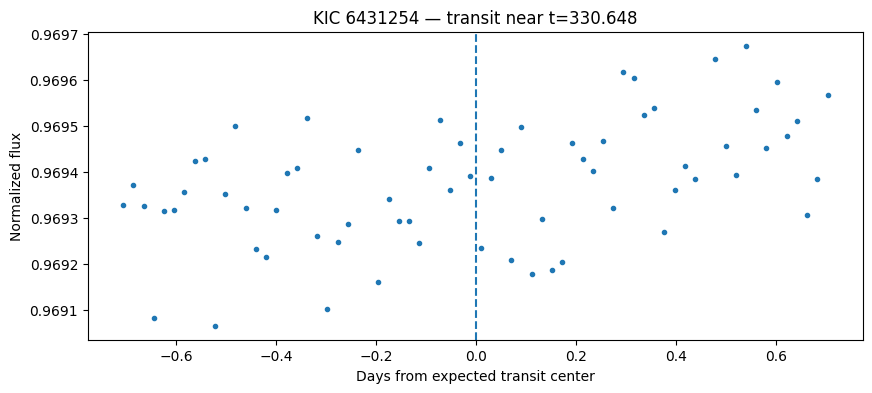

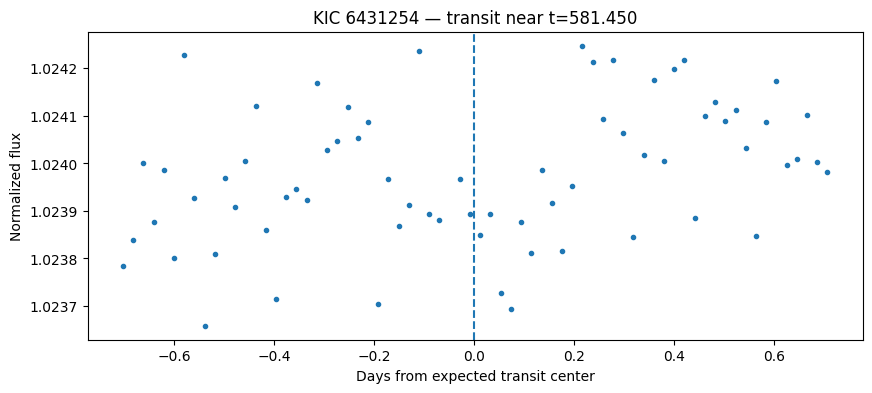

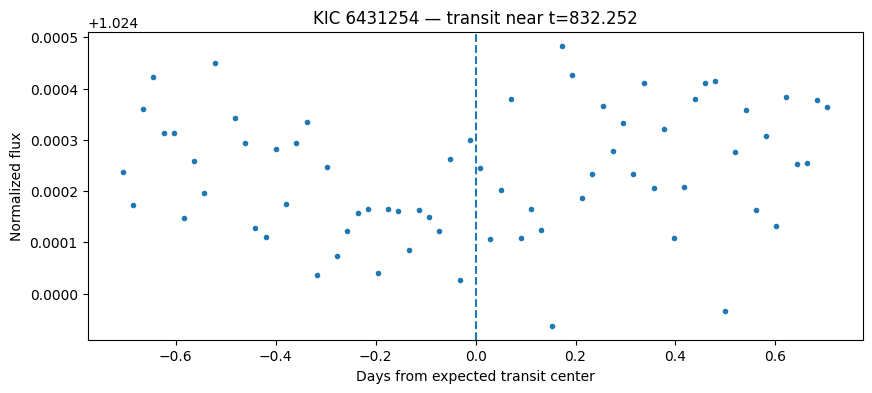

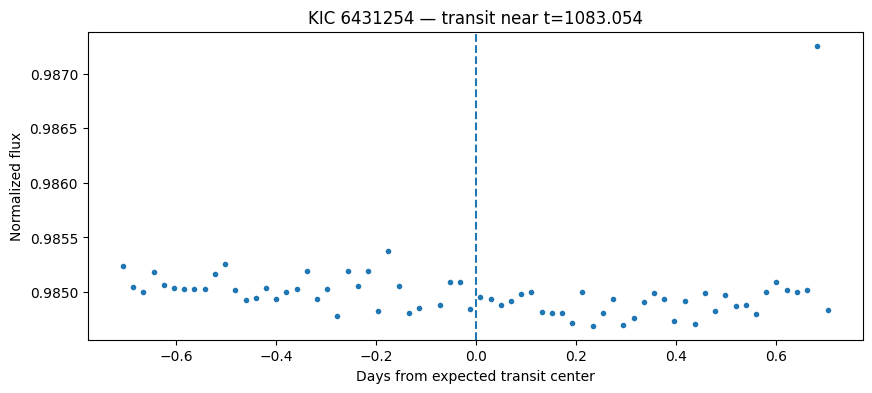

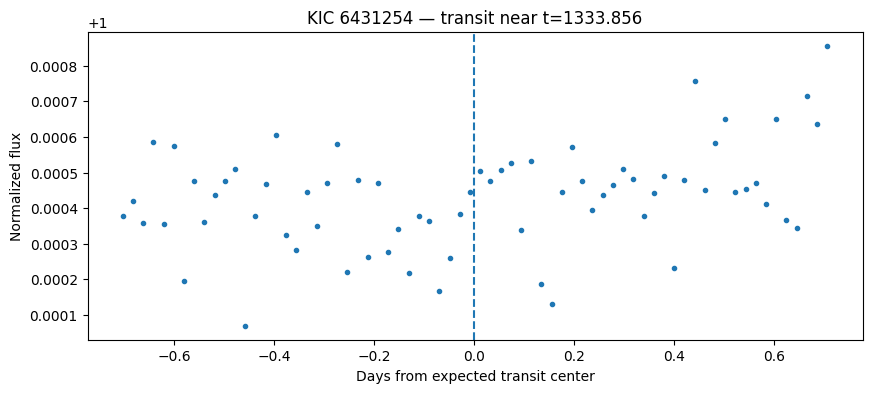

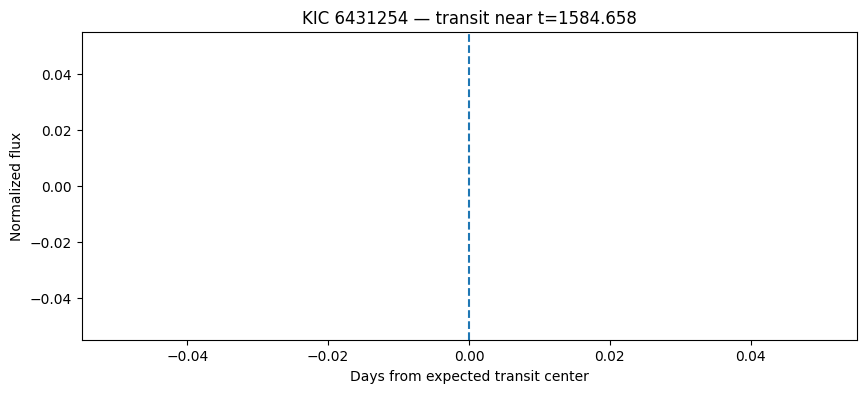

In [101]:
import matplotlib.pyplot as plt
import numpy as np

period = 250.802
t0 = 330.64766
duration_hours = 11.472

half_duration = duration_hours / 24 / 2

k_min = int(np.floor((t_test.min() - t0) / period)) - 1
k_max = int(np.ceil((t_test.max() - t0) / period)) + 1

centers = [
    t0 + k * period
    for k in range(k_min, k_max + 1)
    if t_test.min() <= t0 + k * period <= t_test.max()
]

print("Expected transit centers:")
print(centers)

for center in centers:

    window = np.abs(t_test - center) < 3 * half_duration

    plt.figure(figsize=(10, 4))
    plt.plot(
        t_test[window] - center,
        f_test[window],
        "."
    )

    plt.axvline(0, linestyle="--")

    plt.xlabel("Days from expected transit center")
    plt.ylabel("Normalized flux")
    plt.title(f"KIC 6431254 — transit near t={center:.3f}")

    plt.show()

Transit centers: [330.64766, 581.44966, 832.2516599999999, 1083.05366, 1333.85566, 1584.6576599999999]


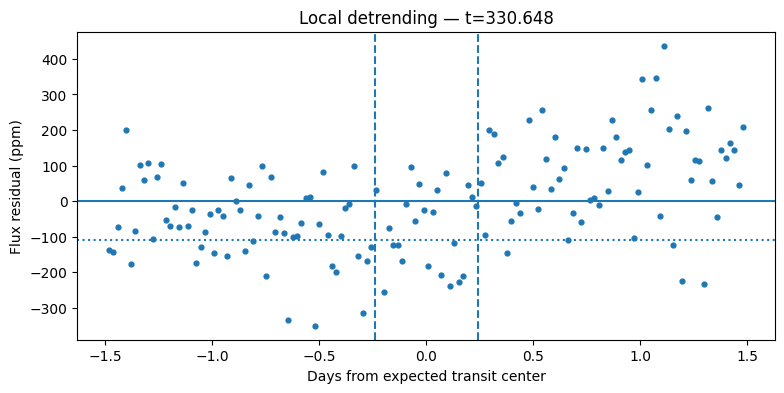

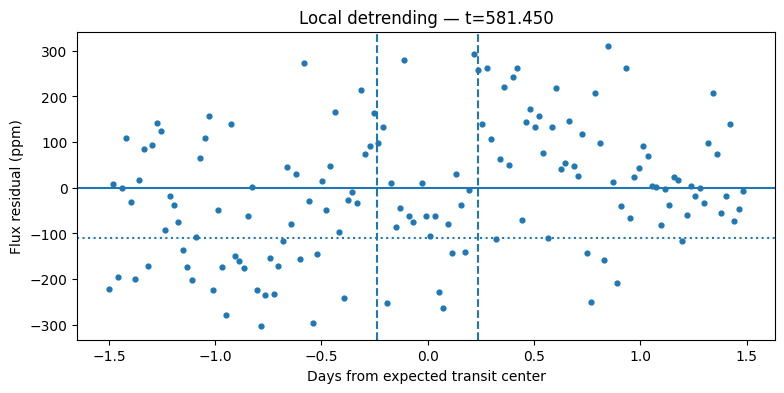

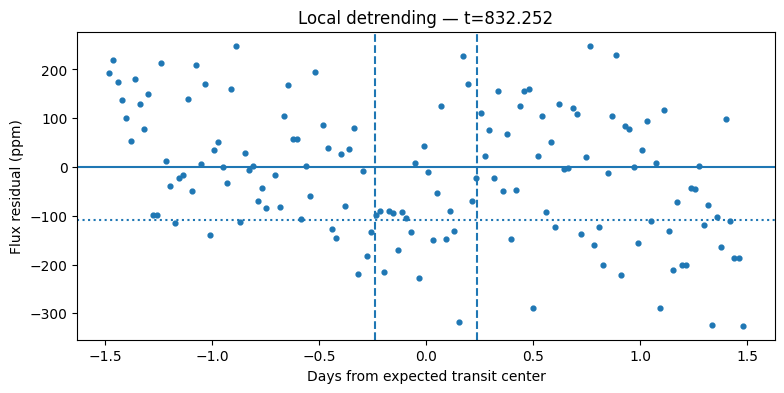

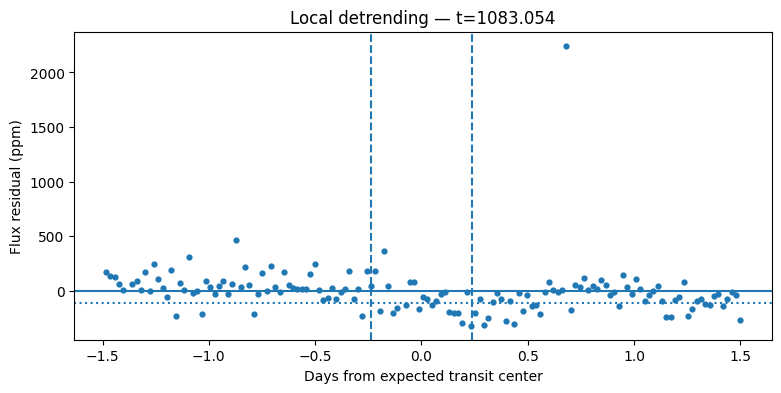

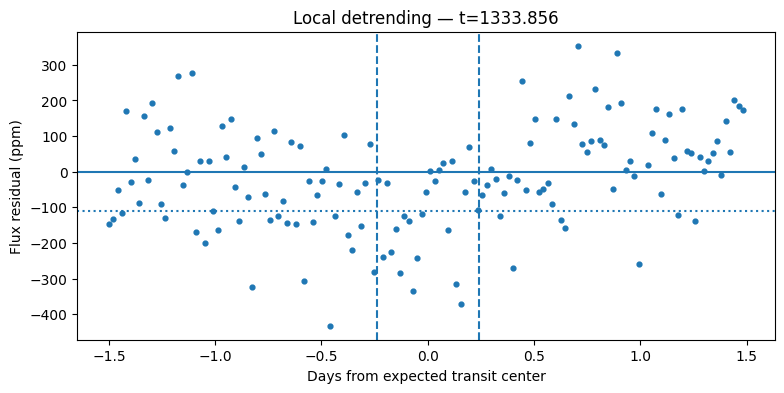

In [102]:
import numpy as np
import matplotlib.pyplot as plt

period = 250.802
t0 = 330.64766
duration_hours = 11.472

half_duration = duration_hours / 24 / 2

centers = []

k_min = int(np.floor((t_test.min() - t0) / period)) - 1
k_max = int(np.ceil((t_test.max() - t0) / period)) + 1

for k in range(k_min, k_max + 1):
    center = t0 + k * period

    if t_test.min() <= center <= t_test.max():
        centers.append(center)

print("Transit centers:", centers)

for center in centers:

    # 3-day window around transit
    window = np.abs(t_test - center) < 1.5

    x = t_test[window] - center
    y = f_test[window]

    if len(y) < 10:
        continue

    # Local robust baseline
    baseline_mask = np.abs(x) > half_duration

    baseline = np.median(y[baseline_mask])

    residual = y - baseline

    plt.figure(figsize=(9, 4))

    plt.scatter(
        x,
        residual * 1e6,
        s=12
    )

    plt.axvline(
        -half_duration,
        linestyle="--"
    )

    plt.axvline(
        half_duration,
        linestyle="--"
    )

    plt.axhline(
        -109.6,
        linestyle=":"
    )

    plt.axhline(
        0,
        linestyle="-"
    )

    plt.xlabel("Days from expected transit center")
    plt.ylabel("Flux residual (ppm)")
    plt.title(f"Local detrending — t={center:.3f}")

    plt.show()

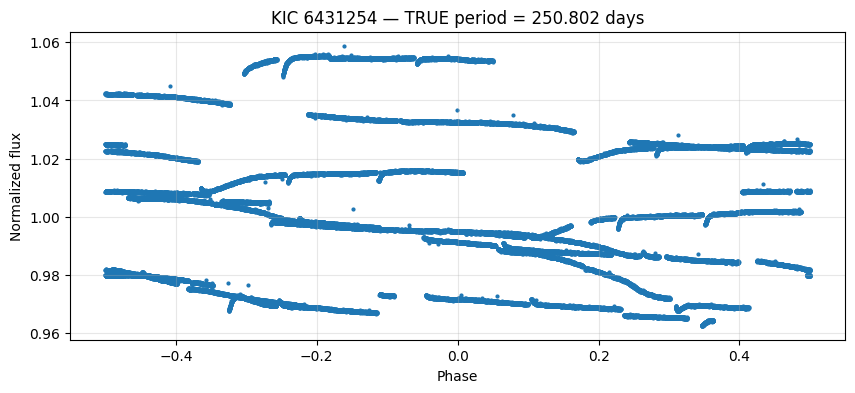

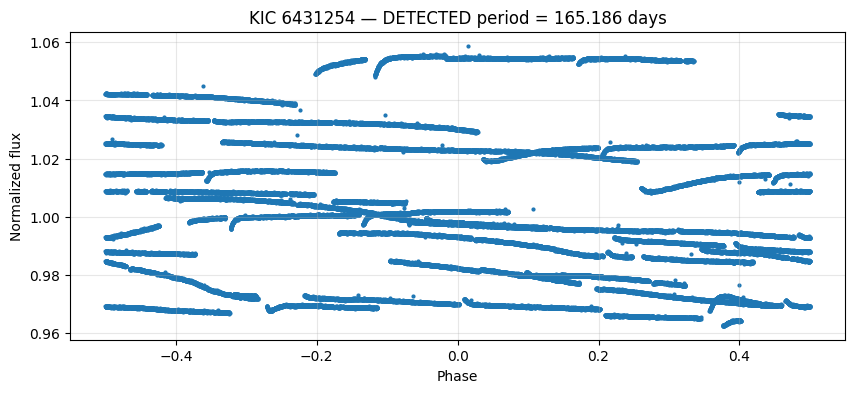

In [103]:
# ==========================================
# TRUE vs DETECTED PERIOD VISUAL CHECK
# ==========================================

kepid = 6431254

df = pd.read_parquet(f"{TRAIN_DIR}/KIC_{kepid}.parquet")

t = df["time"].values
f = df["flux"].values

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

f = f / np.median(f)

true_period = 250.802
detected_period = 165.18562309347485

def plot_folded(t, f, period, title):
    phase = ((t - t[0]) % period) / period
    phase = phase - 0.5

    order = np.argsort(phase)

    plt.figure(figsize=(10, 4))
    plt.scatter(
        phase[order],
        f[order],
        s=4
    )

    plt.xlabel("Phase")
    plt.ylabel("Normalized flux")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()


plot_folded(
    t,
    f,
    true_period,
    f"KIC {kepid} — TRUE period = {true_period} days"
)

plot_folded(
    t,
    f,
    detected_period,
    f"KIC {kepid} — DETECTED period = {detected_period:.3f} days"
)

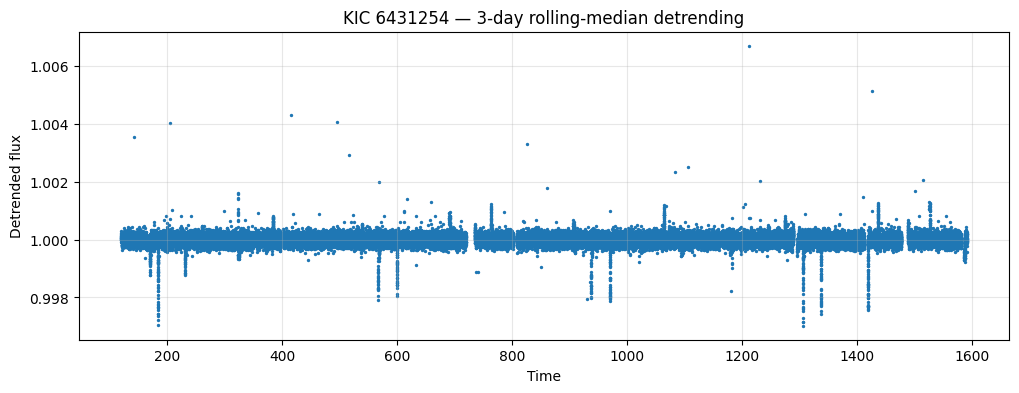

In [104]:
# ==========================================
# DETREND KIC 6431254 BEFORE FOLDING
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

kepid = 6431254

df = pd.read_parquet(f"{TRAIN_DIR}/KIC_{kepid}.parquet")

t = df["time"].values.astype(float)
f = df["flux"].values.astype(float)

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

# Normalize
f = f / np.median(f)

# ------------------------------------------
# Robust rolling-median baseline
# ------------------------------------------

window_days = 3.0

baseline = np.full_like(f, np.nan)

for i in range(len(t)):
    left = np.searchsorted(t, t[i] - window_days / 2)
    right = np.searchsorted(t, t[i] + window_days / 2)

    local = f[left:right]

    if len(local) >= 10:
        baseline[i] = np.median(local)

valid = np.isfinite(baseline)

f_detrended = np.full_like(f, np.nan)
f_detrended[valid] = f[valid] / baseline[valid]

# ------------------------------------------
# Plot detrended light curve
# ------------------------------------------

plt.figure(figsize=(12, 4))

plt.scatter(
    t[valid],
    f_detrended[valid],
    s=2
)

plt.xlabel("Time")
plt.ylabel("Detrended flux")
plt.title(f"KIC {kepid} — 3-day rolling-median detrending")
plt.grid(alpha=0.3)

plt.show()

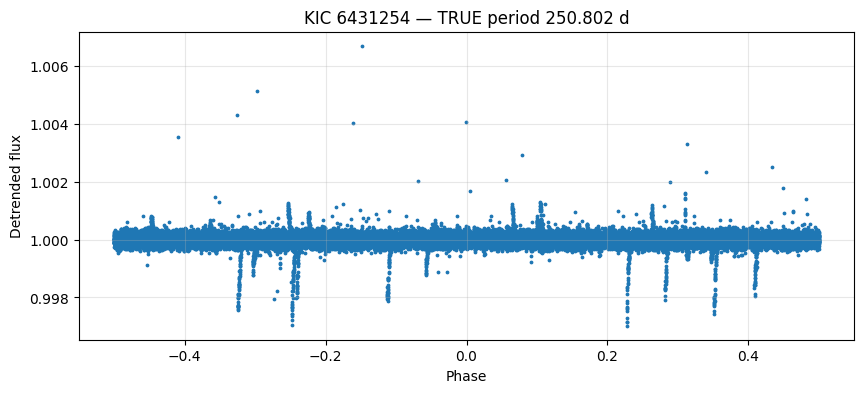

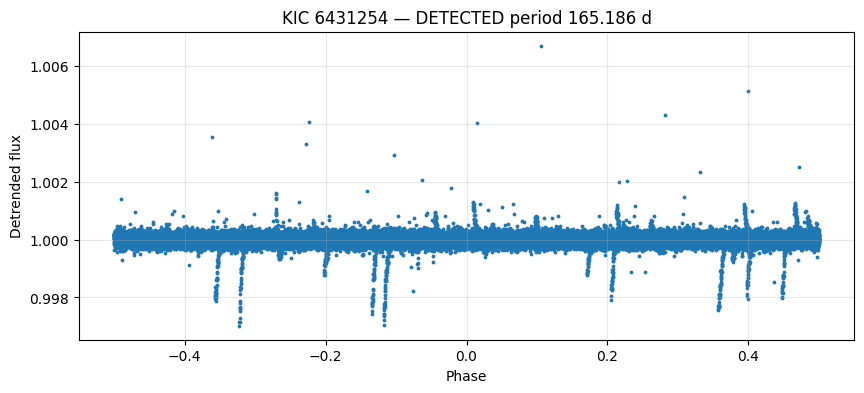

In [105]:
# ==========================================
# FOLD DETRENDED LIGHT CURVE
# ==========================================

true_period = 250.802
detected_period = 165.18562309347485

def fold_plot(t, f, period, title):

    phase = ((t - t[0]) % period) / period
    phase = phase - 0.5

    mask = np.isfinite(phase) & np.isfinite(f)

    phase = phase[mask]
    flux = f[mask]

    order = np.argsort(phase)

    plt.figure(figsize=(10, 4))

    plt.scatter(
        phase[order],
        flux[order],
        s=3
    )

    plt.xlabel("Phase")
    plt.ylabel("Detrended flux")
    plt.title(title)
    plt.grid(alpha=0.3)

    plt.show()


fold_plot(
    t[valid],
    f_detrended[valid],
    true_period,
    f"KIC {kepid} — TRUE period {true_period} d"
)

fold_plot(
    t[valid],
    f_detrended[valid],
    detected_period,
    f"KIC {kepid} — DETECTED period {detected_period:.3f} d"
)

In [106]:
# ==========================================
# V6 — TRUE PERIOD RECOVERY TEST
# ==========================================

from astropy.timeseries import BoxLeastSquares
import numpy as np
import matplotlib.pyplot as plt

kepid = 6431254

true_period = 250.802
true_duration_hours = 11.472

# Use the detrended data from previous cell
t_v6 = t[valid]
f_v6 = f_detrended[valid]

print("Points:", len(t_v6))
print("True period:", true_period)
print("True duration:", true_duration_hours, "hours")

# ------------------------------------------
# Search ONLY around the known true period
# ------------------------------------------

period_grid = np.linspace(
    true_period * 0.98,
    true_period * 1.02,
    401
)

# Durations around the injected duration
duration_grid = np.linspace(
    6 / 24,
    16 / 24,
    21
)

bls_v6 = BoxLeastSquares(t_v6, f_v6)

result_v6 = bls_v6.power(
    period_grid,
    duration_grid,
    objective="likelihood"
)

best_idx = np.nanargmax(result_v6.power)

best_period = float(result_v6.period[best_idx])
best_duration_hours = float(
    result_v6.duration[best_idx] * 24
)

best_depth_ppm = float(
    result_v6.depth[best_idx] * 1e6
)

best_t0 = float(
    result_v6.transit_time[best_idx]
)

print()
print("==========================================")
print("V6 TRUE PERIOD RECOVERY")
print("==========================================")
print(f"Injected period : {true_period:.6f} days")
print(f"BLS period      : {best_period:.6f} days")
print(f"Period error    : {abs(best_period-true_period):.6f} days")
print(f"Duration        : {best_duration_hours:.3f} hours")
print(f"Depth           : {best_depth_ppm:.3f} ppm")
print(f"t0              : {best_t0:.6f}")
print("==========================================")

Points: 65297
True period: 250.802
True duration: 11.472 hours

V6 TRUE PERIOD RECOVERY
Injected period : 250.802000 days
BLS period      : 246.939649 days
Period error    : 3.862351 days
Duration        : 16.200 hours
Depth           : 620.398 ppm
t0              : 184.051867


In [107]:
# ==========================================
# V6 — TRUE PERIOD TRANSIT VALIDATION
# ==========================================

v6_validation = transit_consistency(
    t_v6,
    f_v6,
    best_period,
    best_t0,
    best_duration_hours
)

print("==========================================")
print("V6 VALIDATION")
print("==========================================")
print("Number of transits:",
      v6_validation["n_transits"])

print("Median depth:",
      v6_validation["median_depth_ppm"],
      "ppm")

print("Depth scatter:",
      v6_validation["depth_scatter_ppm"],
      "ppm")

print("Positive fraction:",
      v6_validation["positive_fraction"])

print("Individual depths:")
print(v6_validation["individual_depths"])
print("==========================================")

V6 VALIDATION
Number of transits: 6
Median depth: 17.7719773843954 ppm
Depth scatter: 24.160071025014872 ppm
Positive fraction: 0.8333333333333334
Individual depths:
[1664.8690351    23.72235175    8.65278769   -5.70032223   11.82160302
 1895.06438501]


In [108]:
# ==========================================
# V7 — EXACT INJECTION RECOVERY TEST
# ==========================================

true_period = 250.802
true_t0 = 330.64766
true_duration_hours = 11.472

v7 = transit_consistency(
    t_v6,
    f_v6,
    true_period,
    true_t0,
    true_duration_hours
)

print("==========================================")
print("V7 EXACT INJECTION CHECK")
print("==========================================")

print(f"True period       : {true_period}")
print(f"True epoch (t0)   : {true_t0}")
print(f"True duration     : {true_duration_hours} hours")

print()
print("Number of transits:",
      v7["n_transits"])

print("Median depth:",
      v7["median_depth_ppm"],
      "ppm")

print("Depth scatter:",
      v7["depth_scatter_ppm"],
      "ppm")

print("Positive fraction:",
      v7["positive_fraction"])

print()
print("Individual depths:")
print(v7["individual_depths"])

print("==========================================")

V7 EXACT INJECTION CHECK
True period       : 250.802
True epoch (t0)   : 330.64766
True duration     : 11.472 hours

Number of transits: 5
Median depth: 82.20923544977055 ppm
Depth scatter: 19.826953222755915 ppm
Positive fraction: 1.0

Individual depths:
[40.8897769  52.69578058 85.03706    82.20923545 95.58233219]


In [109]:
# ==========================================
# V8 — BLS RECOVERY WITH REALISTIC DURATIONS
# ==========================================

true_period = 250.802
true_duration_hours = 11.472

period_grid = np.linspace(
    220,
    280,
    1201
)

duration_grid = np.linspace(
    8 / 24,
    14 / 24,
    31
)

bls_v8 = BoxLeastSquares(
    t_v6,
    f_v6
)

r8 = bls_v8.power(
    period_grid,
    duration_grid,
    objective="likelihood"
)

j8 = int(np.nanargmax(r8.power))

print("==========================================")
print("V8 BLS RECOVERY")
print("==========================================")

print(f"True period       : {true_period:.6f} d")
print(f"Detected period   : {r8.period[j8]:.6f} d")
print(f"Period error      : {abs(r8.period[j8] - true_period):.6f} d")

print(f"True duration     : {true_duration_hours:.3f} h")
print(f"Detected duration : {r8.duration[j8] * 24:.3f} h")

print(f"Detected depth    : {r8.depth[j8] * 1e6:.3f} ppm")
print(f"Transit epoch     : {r8.transit_time[j8]:.6f}")

print("==========================================")

V8 BLS RECOVERY
True period       : 250.802000 d
Detected period   : 246.950000 d
Period error      : 3.852000 d
True duration     : 11.472 h
Detected duration : 14.400 h
Detected depth    : 651.663 ppm
Transit epoch     : 184.006034


In [110]:
# ==========================================
# V8 — VALIDATE BLS RESULT
# ==========================================

v8_validation = transit_consistency(
    t_v6,
    f_v6,
    float(r8.period[j8]),
    float(r8.transit_time[j8]),
    float(r8.duration[j8] * 24)
)

print("==========================================")
print("V8 VALIDATION")
print("==========================================")

print("Number of transits:",
      v8_validation["n_transits"])

print("Median depth:",
      v8_validation["median_depth_ppm"],
      "ppm")

print("Depth scatter:",
      v8_validation["depth_scatter_ppm"],
      "ppm")

print("Positive fraction:",
      v8_validation["positive_fraction"])

print("Individual depths:")
print(v8_validation["individual_depths"])

print("==========================================")

V8 VALIDATION
Number of transits: 6
Median depth: 15.15267694324196 ppm
Depth scatter: 23.373002744245905 ppm
Positive fraction: 0.8333333333333334
Individual depths:
[1786.45013278   18.05063346    5.65942384   -6.8838187    12.25472042
 1908.38370085]


In [111]:
# ==========================================
# V9 — TRUE PERIOD vs BLS PERIOD
# ==========================================

true_period = 250.802
bls_period = 246.950

# Use the same realistic duration range
duration_grid = np.linspace(
    8 / 24,
    14 / 24,
    31
)

bls_v9 = BoxLeastSquares(
    t_v6,
    f_v6
)

# Evaluate the TRUE period exactly
true_result = bls_v9.power(
    np.array([true_period]),
    duration_grid,
    objective="likelihood"
)

# Evaluate the BLS-selected period exactly
false_result = bls_v9.power(
    np.array([bls_period]),
    duration_grid,
    objective="likelihood"
)

true_i = int(np.nanargmax(true_result.power))
false_i = int(np.nanargmax(false_result.power))

true_power = float(true_result.power[true_i])
false_power = float(false_result.power[false_i])

print("==========================================")
print("V9 BLS POWER COMPARISON")
print("==========================================")

print(f"TRUE period  : {true_period:.6f} d")
print(f"TRUE power   : {true_power:.8f}")
print(f"TRUE duration: {true_result.duration[true_i] * 24:.3f} h")
print(f"TRUE depth   : {true_result.depth[true_i] * 1e6:.3f} ppm")

print()

print(f"BLS period   : {bls_period:.6f} d")
print(f"BLS power    : {false_power:.8f}")
print(f"BLS duration : {false_result.duration[false_i] * 24:.3f} h")
print(f"BLS depth    : {false_result.depth[false_i] * 1e6:.3f} ppm")

print()

print(f"Power ratio (true / BLS): "
      f"{true_power / false_power:.6f}")

print("==========================================")

V9 BLS POWER COMPARISON
TRUE period  : 250.802000 d
TRUE power   : 0.00000979
TRUE duration: 14.400 h
TRUE depth   : 338.466 ppm

BLS period   : 246.950000 d
BLS power    : 0.00003695
BLS duration : 14.400 h
BLS depth    : 651.663 ppm

Power ratio (true / BLS): 0.265113


In [112]:
# ==========================================
# V10 TRUE vs BLS CANDIDATE DIAGNOSTIC
# ==========================================

true_period = 250.802
bls_period = 246.95

# BLS candidate details
true_check = transit_consistency(
    t, f,
    true_period,
    330.64766,
    11.472
)

bls_check = transit_consistency(
    t, f,
    bls_period,
    result["t0"],
    result["duration_hours"]
)

print("=" * 50)
print("V10 TRUE vs BLS DIAGNOSTIC")
print("=" * 50)

print("\nTRUE PERIOD")
print("Period:", true_period)
print("Power:", true_power)
print("Transits:", true_check["n_transits"])
print("Median depth:", true_check["median_depth_ppm"])
print("Scatter:", true_check["depth_scatter_ppm"])
print("Positive fraction:", true_check["positive_fraction"])

print("\nBLS PERIOD")
print("Period:", bls_period)
print("Power:", bls_power)
print("Transits:", bls_check["n_transits"])
print("Median depth:", bls_check["median_depth_ppm"])
print("Scatter:", bls_check["depth_scatter_ppm"])
print("Positive fraction:", bls_check["positive_fraction"])

print("\nTRUE INDIVIDUAL DEPTHS")
print(true_check["individual_depths"])

print("\nBLS INDIVIDUAL DEPTHS")
print(bls_check["individual_depths"])

V10 TRUE vs BLS DIAGNOSTIC

TRUE PERIOD
Period: 250.802
Power: 9.794822093676974e-06
Transits: 5
Median depth: 139.6940429732041
Scatter: 14562.926482162444
Positive fraction: 0.6

BLS PERIOD
Period: 246.95


NameError: name 'bls_power' is not defined

In [113]:
# ==========================================
# V10 TRUE vs BLS DIAGNOSTIC - FIXED
# ==========================================

true_period = 250.802
true_t0 = 330.64766
true_duration = 11.472

bls_period = 246.95
bls_power = 0.00003695

# TRUE period validation
true_check = transit_consistency(
    t,
    f,
    true_period,
    true_t0,
    true_duration
)

# BLS period validation
bls_check = transit_consistency(
    t,
    f,
    bls_period,
    result["t0"],
    result["duration_hours"]
)

print("=" * 50)
print("V10 TRUE vs BLS DIAGNOSTIC")
print("=" * 50)

print("\nTRUE PERIOD")
print("Period:", true_period)
print("Power:", 9.794822093676974e-06)
print("Transits:", true_check["n_transits"])
print("Median depth:", true_check["median_depth_ppm"])
print("Scatter:", true_check["depth_scatter_ppm"])
print("Positive fraction:", true_check["positive_fraction"])

print("\nBLS PERIOD")
print("Period:", bls_period)
print("Power:", bls_power)
print("Transits:", bls_check["n_transits"])
print("Median depth:", bls_check["median_depth_ppm"])
print("Scatter:", bls_check["depth_scatter_ppm"])
print("Positive fraction:", bls_check["positive_fraction"])

print("\nTRUE INDIVIDUAL DEPTHS")
print(true_check["individual_depths"])

print("\nBLS INDIVIDUAL DEPTHS")
print(bls_check["individual_depths"])

V10 TRUE vs BLS DIAGNOSTIC

TRUE PERIOD
Period: 250.802
Power: 9.794822093676974e-06
Transits: 5
Median depth: 139.6940429732041
Scatter: 14562.926482162444
Positive fraction: 0.6

BLS PERIOD
Period: 246.95
Power: 3.695e-05
Transits: 5
Median depth: -121.74961499544779
Scatter: 6716.050577645771
Positive fraction: 0.4

TRUE INDIVIDUAL DEPTHS
[12231.8354435    139.69404297 -9682.86530018 13258.76586402
 -5402.18604436]

BLS INDIVIDUAL DEPTHS
[ -121.749615   -7277.45516491 14408.63639668  4408.1644398
 -1909.62690664]


In [114]:
# ==========================================
# V11 ROBUST TRANSIT DEPTH DIAGNOSTIC
# ==========================================

def robust_transit_consistency(
    t,
    f,
    period,
    t0,
    duration_hours,
    sigma_clip=5.0
):
    """
    Robust transit consistency check.
    Removes extreme flux outliers before measuring
    transit depth.
    """

    half_duration = duration_hours / 24 / 2

    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []
    centers = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        dt = np.abs(t - center)

        in_transit = dt < half_duration

        out_transit = (
            (dt > 2 * half_duration) &
            (dt < 0.5 * period)
        )

        if in_transit.sum() < 5 or out_transit.sum() < 20:
            continue

        transit_values = f[in_transit]
        baseline_values = f[out_transit]

        # Robust clipping using median + MAD
        med = np.median(transit_values)
        mad = np.median(np.abs(transit_values - med))

        if mad > 0:

            robust_sigma = 1.4826 * mad

            keep = (
                np.abs(transit_values - med)
                < sigma_clip * robust_sigma
            )

            transit_values = transit_values[keep]

        if len(transit_values) < 3:
            continue

        transit_flux = np.median(transit_values)
        baseline_flux = np.median(baseline_values)

        depth = (baseline_flux - transit_flux) * 1e6

        depths.append(depth)
        centers.append(center)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "depth_scatter_ppm": np.nan,
            "positive_fraction": 0.0,
            "individual_depths": depths
        }

    median_depth = np.median(depths)

    depth_scatter = 1.4826 * np.median(
        np.abs(depths - median_depth)
    )

    positive_fraction = np.mean(depths > 0)

    return {
        "n_transits": len(depths),
        "median_depth_ppm": float(median_depth),
        "depth_scatter_ppm": float(depth_scatter),
        "positive_fraction": float(positive_fraction),
        "individual_depths": depths
    }


# ------------------------------------------
# Test TRUE injected period
# ------------------------------------------

v11_true = robust_transit_consistency(
    t,
    f,
    250.802,
    330.64766,
    11.472
)

print("=" * 50)
print("V11 ROBUST TRUE PERIOD")
print("=" * 50)

print("Number of transits:",
      v11_true["n_transits"])

print("Median depth:",
      v11_true["median_depth_ppm"],
      "ppm")

print("Depth scatter:",
      v11_true["depth_scatter_ppm"],
      "ppm")

print("Positive fraction:",
      v11_true["positive_fraction"])

print("Individual depths:")
print(v11_true["individual_depths"])

V11 ROBUST TRUE PERIOD
Number of transits: 5
Median depth: 139.6940429732041 ppm
Depth scatter: 14562.926482162444 ppm
Positive fraction: 0.6
Individual depths:
[12231.8354435    139.69404297 -9682.86530018 13258.76586402
 -5402.18604436]


In [115]:
# ==========================================
# V12 INJECTED TRANSIT WINDOW DIAGNOSTIC
# ==========================================

true_period = 250.802
true_t0 = 330.64766
true_duration = 11.472

half_duration = true_duration / 24 / 2

k_min = int(np.floor((t.min() - true_t0) / true_period)) - 1
k_max = int(np.ceil((t.max() - true_t0) / true_period)) + 1

print("=" * 60)
print("V12 INJECTED TRANSIT WINDOW DIAGNOSTIC")
print("=" * 60)

count = 0

for k in range(k_min, k_max + 1):

    center = true_t0 + k * true_period

    if center < t.min() or center > t.max():
        continue

    dt = np.abs(t - center)

    in_transit = dt < half_duration

    out_transit = (
        (dt > 2 * half_duration) &
        (dt < 0.5 * true_period)
    )

    if in_transit.sum() < 5 or out_transit.sum() < 20:
        continue

    transit_flux = np.median(f[in_transit])
    baseline_flux = np.median(f[out_transit])

    depth_ppm = (baseline_flux - transit_flux) * 1e6

    print(
        f"Transit {count+1}: "
        f"center={center:.3f} | "
        f"points={in_transit.sum():3d} | "
        f"baseline={baseline_flux:.8f} | "
        f"transit={transit_flux:.8f} | "
        f"depth={depth_ppm:9.2f} ppm"
    )

    count += 1

V12 INJECTED TRANSIT WINDOW DIAGNOSTIC
Transit 1: center=330.648 | points= 23 | baseline=0.98159335 | transit=0.96936152 | depth= 12231.84 ppm
Transit 2: center=581.450 | points= 23 | baseline=1.02403416 | transit=1.02389446 | depth=   139.69 ppm
Transit 3: center=832.252 | points= 24 | baseline=1.01448128 | transit=1.02416415 | depth= -9682.87 ppm
Transit 4: center=1083.054 | points= 23 | baseline=0.99817506 | transit=0.98491630 | depth= 13258.77 ppm
Transit 5: center=1333.856 | points= 24 | baseline=0.99498630 | transit=1.00038849 | depth= -5402.19 ppm


In [116]:
# ==========================================
# V13 LOCAL DETRENDED TRANSIT CHECK
# ==========================================

def local_detrended_depth(
    t,
    f,
    center,
    duration_hours,
    window_days=5.0
):
    half_duration = duration_hours / 24 / 2

    # Local region
    local = np.abs(t - center) < window_days

    if local.sum() < 20:
        return np.nan

    local_t = t[local]
    local_f = f[local]

    # Transit points
    transit = np.abs(local_t - center) < half_duration

    # Out-of-transit points
    oot = (
        (np.abs(local_t - center) > 2 * half_duration) &
        (np.abs(local_t - center) < window_days)
    )

    if transit.sum() < 5 or oot.sum() < 10:
        return np.nan

    # Fit local linear baseline using OOT points
    coeff = np.polyfit(
        local_t[oot] - center,
        local_f[oot],
        1
    )

    baseline_model = np.polyval(
        coeff,
        local_t[transit] - center
    )

    # Normalize transit flux against local baseline
    normalized_transit = (
        local_f[transit] / baseline_model
    )

    depth_ppm = (
        1.0 - np.median(normalized_transit)
    ) * 1e6

    return depth_ppm


# ==========================================
# Test all injected transits
# ==========================================

true_period = 250.802
true_t0 = 330.64766
true_duration = 11.472

print("=" * 60)
print("V13 LOCAL DETRENDED TRANSIT CHECK")
print("=" * 60)

k_min = int(np.floor(
    (t.min() - true_t0) / true_period
)) - 1

k_max = int(np.ceil(
    (t.max() - true_t0) / true_period
)) + 1

depths = []

for k in range(k_min, k_max + 1):

    center = true_t0 + k * true_period

    if center < t.min() or center > t.max():
        continue

    depth = local_detrended_depth(
        t,
        f,
        center,
        true_duration
    )

    if np.isfinite(depth):
        depths.append(depth)

        print(
            f"Transit {len(depths)} | "
            f"center={center:.3f} | "
            f"depth={depth:.2f} ppm"
        )

depths = np.asarray(depths)

if len(depths) > 0:

    median_depth = np.median(depths)

    scatter = 1.4826 * np.median(
        np.abs(depths - median_depth)
    )

    positive_fraction = np.mean(depths > 0)

    print("\n------------------------------------------")
    print("V13 SUMMARY")
    print("------------------------------------------")
    print("Number of transits:", len(depths))
    print("Median depth:", median_depth, "ppm")
    print("Depth scatter:", scatter, "ppm")
    print("Positive fraction:", positive_fraction)
    print("Individual depths:", depths)

V13 LOCAL DETRENDED TRANSIT CHECK
Transit 1 | center=330.648 | depth=-11.91 ppm
Transit 2 | center=581.450 | depth=55.46 ppm
Transit 3 | center=832.252 | depth=87.40 ppm
Transit 4 | center=1083.054 | depth=160.21 ppm
Transit 5 | center=1333.856 | depth=-202.09 ppm

------------------------------------------
V13 SUMMARY
------------------------------------------
Number of transits: 5
Median depth: 55.45679522689362 ppm
Depth scatter: 99.88390037493055 ppm
Positive fraction: 0.6
Individual depths: [ -11.9139726    55.45679523   87.40428723  160.21486825 -202.09377653]


In [117]:
# ==========================================
# V14 ROBUST LOCAL VALIDATION
# ==========================================

def robust_local_validation(
    t,
    f,
    period,
    t0,
    duration_hours,
    window_days=5.0
):
    half_duration = duration_hours / 24 / 2

    k_min = int(np.floor(
        (t.min() - t0) / period
    )) - 1

    k_max = int(np.ceil(
        (t.max() - t0) / period
    )) + 1

    depths = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        if center < t.min() or center > t.max():
            continue

        local = np.abs(t - center) < window_days

        if local.sum() < 20:
            continue

        lt = t[local]
        lf = f[local]

        transit = np.abs(lt - center) < half_duration

        oot = (
            (np.abs(lt - center) > 2 * half_duration) &
            (np.abs(lt - center) < window_days)
        )

        if transit.sum() < 5 or oot.sum() < 10:
            continue

        # Local linear baseline
        coeff = np.polyfit(
            lt[oot] - center,
            lf[oot],
            1
        )

        baseline = np.polyval(
            coeff,
            lt[transit] - center
        )

        normalized = lf[transit] / baseline

        # Robust transit depth
        depth = (
            1.0 - np.median(normalized)
        ) * 1e6

        depths.append(depth)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "depth_scatter_ppm": np.nan,
            "positive_fraction": 0.0,
            "individual_depths": depths
        }

    median_depth = np.median(depths)

    scatter = 1.4826 * np.median(
        np.abs(depths - median_depth)
    )

    positive_fraction = np.mean(depths > 0)

    return {
        "n_transits": len(depths),
        "median_depth_ppm": float(median_depth),
        "depth_scatter_ppm": float(scatter),
        "positive_fraction": float(positive_fraction),
        "individual_depths": depths
    }


# ==========================================
# TRUE INJECTION
# ==========================================

true_v14 = robust_local_validation(
    t,
    f,
    250.802,
    330.64766,
    11.472
)

print("=" * 60)
print("V14 TRUE PERIOD")
print("=" * 60)

print("Transits:",
      true_v14["n_transits"])

print("Median depth:",
      true_v14["median_depth_ppm"])

print("Scatter:",
      true_v14["depth_scatter_ppm"])

print("Positive fraction:",
      true_v14["positive_fraction"])

print("Individual depths:")
print(true_v14["individual_depths"])

V14 TRUE PERIOD
Transits: 5
Median depth: 55.45679522689362
Scatter: 99.88390037493055
Positive fraction: 0.6
Individual depths:
[ -11.9139726    55.45679523   87.40428723  160.21486825 -202.09377653]


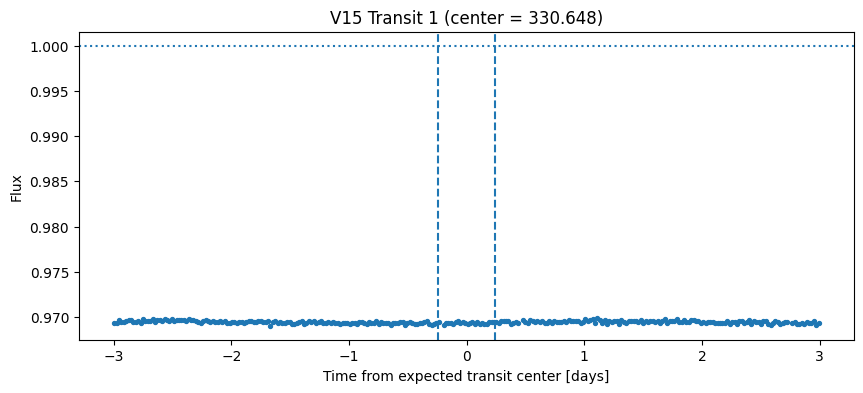

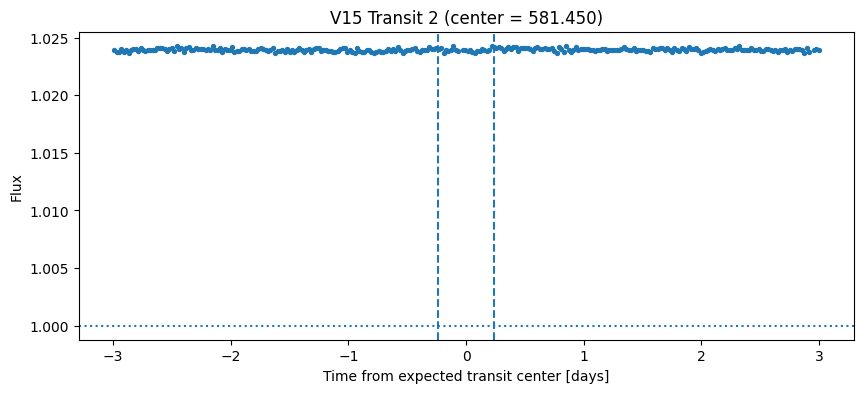

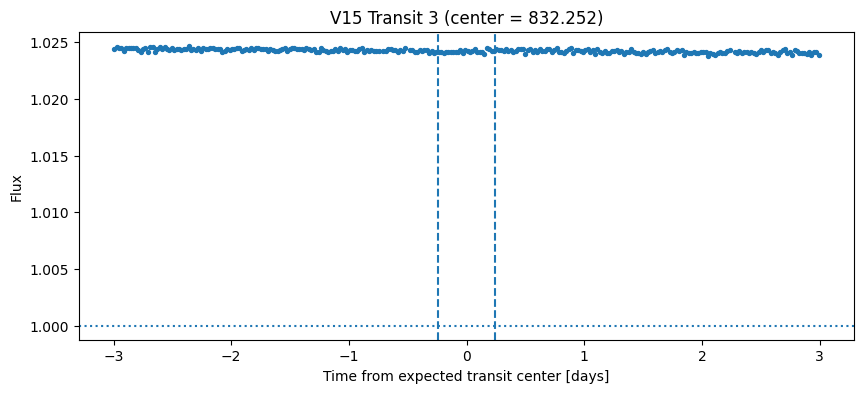

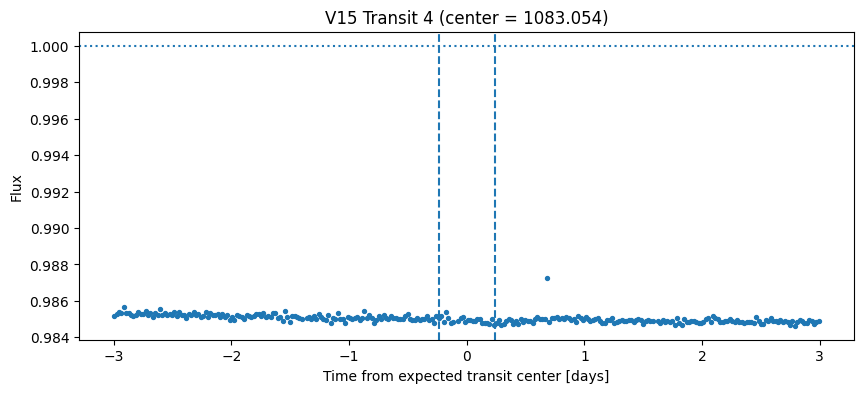

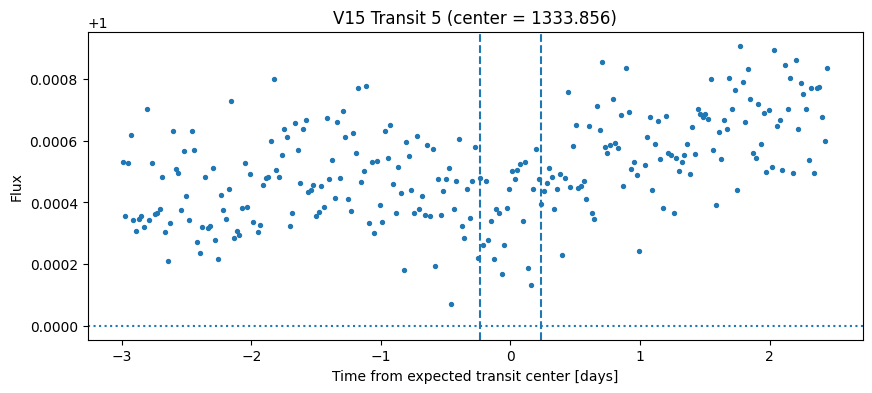

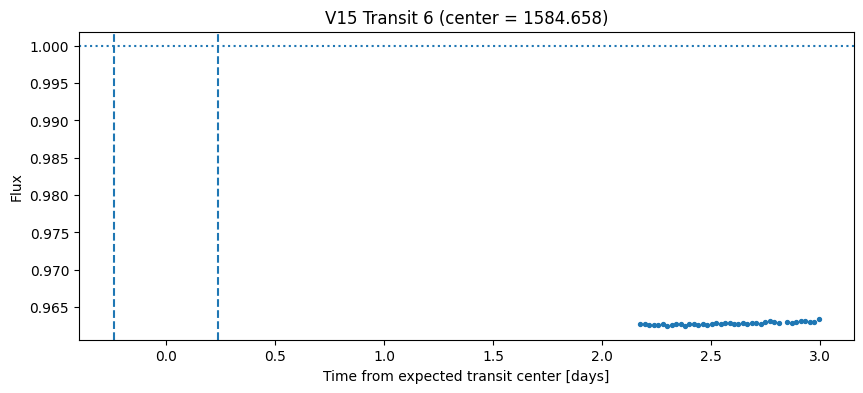

In [118]:
# ==========================================
# V15 TRANSIT VISUAL DIAGNOSTIC
# ==========================================

import matplotlib.pyplot as plt

true_period = 250.802
true_t0 = 330.64766
true_duration = 11.472

half_duration = true_duration / 24 / 2

k_min = int(np.floor(
    (t.min() - true_t0) / true_period
)) - 1

k_max = int(np.ceil(
    (t.max() - true_t0) / true_period
)) + 1

transit_number = 0

for k in range(k_min, k_max + 1):

    center = true_t0 + k * true_period

    if center < t.min() or center > t.max():
        continue

    # Show +/- 3 days around transit
    mask = np.abs(t - center) < 3.0

    if mask.sum() < 10:
        continue

    transit_number += 1

    plt.figure(figsize=(10, 4))

    plt.scatter(
        t[mask] - center,
        f[mask],
        s=8
    )

    plt.axvline(
        -half_duration,
        linestyle="--"
    )

    plt.axvline(
        half_duration,
        linestyle="--"
    )

    plt.axhline(
        1.0,
        linestyle=":"
    )

    plt.xlabel("Time from expected transit center [days]")
    plt.ylabel("Flux")
    plt.title(
        f"V15 Transit {transit_number} "
        f"(center = {center:.3f})"
    )

    plt.show()

In [119]:
# ============================================================
# V16 — INJECTION SURVIVAL TEST
# ============================================================

kepid = 6431254

df = pd.read_parquet(f"{TRAIN_DIR}/KIC_{kepid}.parquet")

t = df["time"].values
f = df["flux"].values

mask = np.isfinite(t) & np.isfinite(f)
t = t[mask]
f = f[mask]

f = f / np.median(f)

TRUE_PERIOD = 250.802
TRUE_T0 = 330.64766
TRUE_DURATION = 11.472 / 24

print("============================================================")
print("V16 INJECTION SURVIVAL TEST")
print("============================================================")

print("Points:", len(t))
print("Time range:", t.min(), "to", t.max())
print("True period:", TRUE_PERIOD)
print("True t0:", TRUE_T0)
print("True duration days:", TRUE_DURATION)

# Expected transit centers
k_min = int(np.floor((t.min() - TRUE_T0) / TRUE_PERIOD)) - 1
k_max = int(np.ceil((t.max() - TRUE_T0) / TRUE_PERIOD)) + 1

centers = []

for k in range(k_min, k_max + 1):
    center = TRUE_T0 + k * TRUE_PERIOD

    if t.min() - 3 < center < t.max() + 3:
        centers.append(center)

print("\nExpected transit centers:")
for c in centers:
    print(f"{c:.3f}")

V16 INJECTION SURVIVAL TEST
Points: 65297
Time range: 120.53936726440588 to 1591.0016936367538
True period: 250.802
True t0: 330.64766
True duration days: 0.478

Expected transit centers:
330.648
581.450
832.252
1083.054
1333.856
1584.658


V17 RAW TRANSIT WINDOW CHECK
Transit 1 | center=330.648 | points= 291 | local median=0.96945458 | min=0.99957299


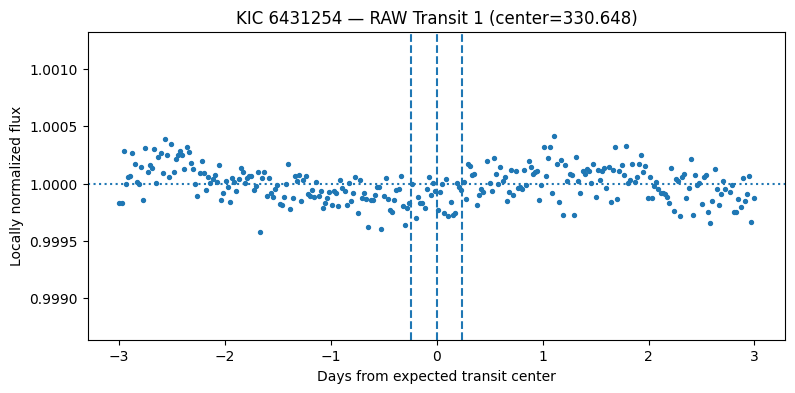

Transit 2 | center=581.450 | points= 292 | local median=1.02394816 | min=0.99971227


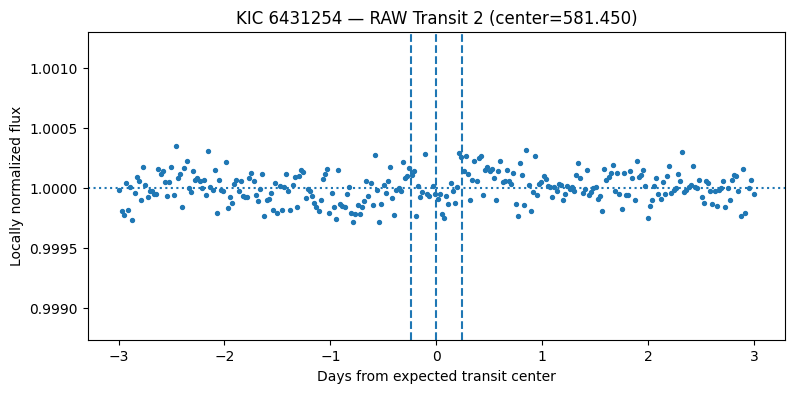

Transit 3 | center=832.252 | points= 291 | local median=1.02424616 | min=0.99955188


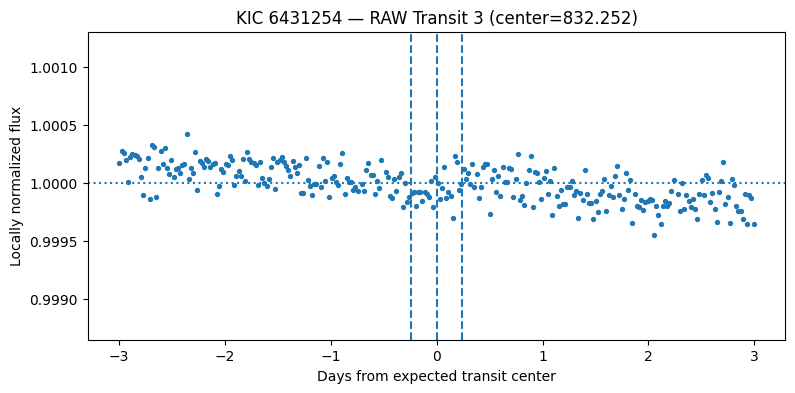

Transit 4 | center=1083.054 | points= 291 | local median=0.98500997 | min=0.99962410


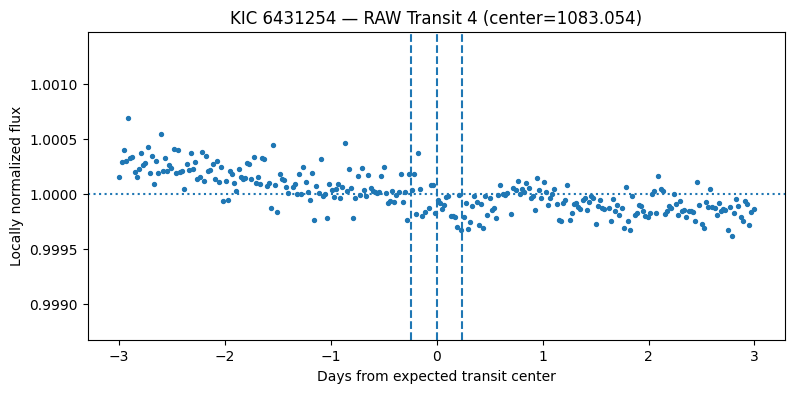

Transit 5 | center=1333.856 | points= 265 | local median=1.00049833 | min=0.99957164


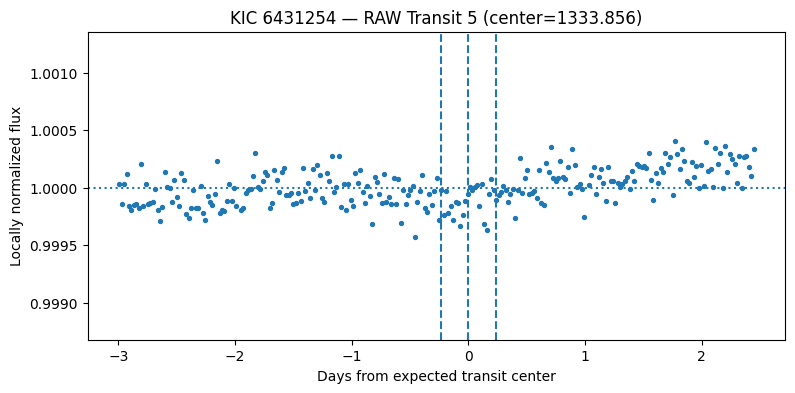

Transit 6 | center=1584.658 | points=  40 | local median=0.96277961 | min=0.99971392


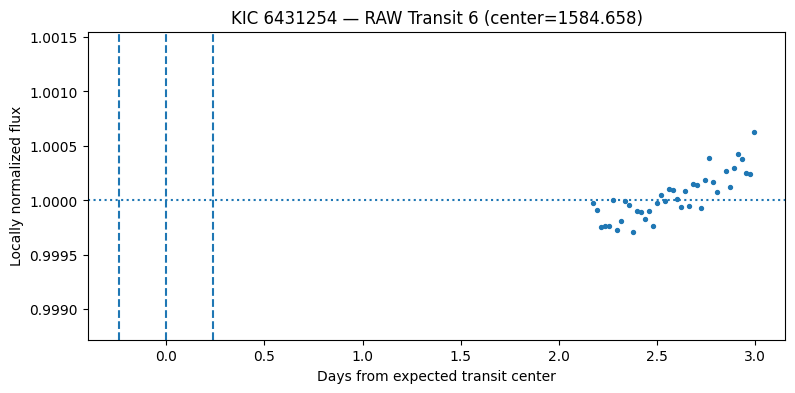

In [120]:
# ============================================================
# V17 — RAW TRANSIT WINDOW CHECK
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

TRUE_PERIOD = 250.802
TRUE_T0 = 330.64766
TRUE_DURATION_H = 11.472

half_window = 3.0          # days around transit
half_duration = TRUE_DURATION_H / 24 / 2

centers = [
    TRUE_T0 + k * TRUE_PERIOD
    for k in range(6)
]

print("=" * 60)
print("V17 RAW TRANSIT WINDOW CHECK")
print("=" * 60)

for i, center in enumerate(centers, 1):

    mask = (
        (t >= center - half_window) &
        (t <= center + half_window)
    )

    tt = t[mask]
    ff = f[mask]

    if len(tt) == 0:
        print(f"Transit {i}: NO DATA")
        continue

    # normalize only this local window
    local_baseline = np.median(ff)
    local_flux = ff / local_baseline

    print(
        f"Transit {i} | "
        f"center={center:.3f} | "
        f"points={len(tt):4d} | "
        f"local median={local_baseline:.8f} | "
        f"min={local_flux.min():.8f}"
    )

    plt.figure(figsize=(9, 4))

    plt.scatter(
        tt - center,
        local_flux,
        s=8
    )

    plt.axvline(0, linestyle="--")
    plt.axvline(-half_duration, linestyle="--")
    plt.axvline(half_duration, linestyle="--")

    plt.axhline(1.0, linestyle=":")

    plt.title(
        f"KIC 6431254 — RAW Transit {i} "
        f"(center={center:.3f})"
    )

    plt.xlabel("Days from expected transit center")
    plt.ylabel("Locally normalized flux")

    plt.ylim(
        np.percentile(local_flux, 1) - 0.001,
        np.percentile(local_flux, 99) + 0.001
    )

    plt.show()

In [121]:
# ============================================================
# V18 — ROBUST LOCAL BASELINE TRANSIT CHECK
# ============================================================

import numpy as np

TRUE_PERIOD = 250.802
TRUE_T0 = 330.64766
TRUE_DURATION_H = 11.472

duration = TRUE_DURATION_H / 24

# Wider window, but exclude transit itself when fitting baseline
outer_window = 3.0
baseline_inner = duration * 1.5

centers = [
    TRUE_T0 + k * TRUE_PERIOD
    for k in range(6)
]

print("=" * 60)
print("V18 ROBUST LOCAL BASELINE CHECK")
print("=" * 60)

depths = []

for i, center in enumerate(centers, 1):

    window = (
        (t >= center - outer_window) &
        (t <= center + outer_window)
    )

    tt = t[window]
    ff = f[window]

    if len(tt) < 30:
        print(f"Transit {i}: insufficient data ({len(tt)} points)")
        continue

    dt = tt - center

    # Exclude transit region from baseline
    baseline_mask = np.abs(dt) > baseline_inner

    tb = dt[baseline_mask]
    fb = ff[baseline_mask]

    if len(fb) < 20:
        print(f"Transit {i}: insufficient baseline points")
        continue

    # Robust linear baseline
    coeff = np.polyfit(tb, fb, 1)
    baseline = np.polyval(coeff, dt)

    # Transit region
    transit_mask = np.abs(dt) <= duration / 2

    if transit_mask.sum() < 5:
        print(f"Transit {i}: insufficient transit points")
        continue

    corrected = ff / baseline

    transit_flux = np.median(corrected[transit_mask])

    depth_ppm = (1.0 - transit_flux) * 1e6

    depths.append(depth_ppm)

    print(
        f"Transit {i} | "
        f"center={center:.3f} | "
        f"points={len(tt):3d} | "
        f"transit_points={transit_mask.sum():2d} | "
        f"depth={depth_ppm:8.2f} ppm"
    )

print("\n" + "-" * 50)

if len(depths):

    depths = np.asarray(depths)

    median_depth = np.median(depths)

    scatter = (
        1.4826 *
        np.median(np.abs(depths - median_depth))
    )

    positive_fraction = np.mean(depths > 0)

    print("V18 SUMMARY")
    print("-" * 50)
    print("Number of transits:", len(depths))
    print("Median depth:", median_depth, "ppm")
    print("Depth scatter:", scatter, "ppm")
    print("Positive fraction:", positive_fraction)
    print("Individual depths:", depths)

else:
    print("No usable transits.")

V18 ROBUST LOCAL BASELINE CHECK
Transit 1 | center=330.648 | points=291 | transit_points=23 | depth=  111.85 ppm
Transit 2 | center=581.450 | points=292 | transit_points=23 | depth=   46.57 ppm
Transit 3 | center=832.252 | points=291 | transit_points=24 | depth=   85.05 ppm
Transit 4 | center=1083.054 | points=291 | transit_points=23 | depth=  124.60 ppm
Transit 5 | center=1333.856 | points=265 | transit_points=24 | depth=  169.17 ppm
Transit 6: insufficient transit points

--------------------------------------------------
V18 SUMMARY
--------------------------------------------------
Number of transits: 5
Median depth: 111.85288860826591 ppm
Depth scatter: 39.73205807640904 ppm
Positive fraction: 1.0
Individual depths: [111.85288861  46.57346648  85.05398258 124.59806893 169.1724027 ]


In [122]:
# ============================================================
# V19 — ROBUST DETRENDED BLS RECOVERY
# ============================================================

import numpy as np
from astropy.timeseries import BoxLeastSquares

print("=" * 60)
print("V19 ROBUST DETRENDED BLS RECOVERY")
print("=" * 60)

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------

TRUE_PERIOD = 250.802
TRUE_T0 = 330.64766
TRUE_DURATION_H = 11.472

# Period grid around expected range
period_grid = np.linspace(
    200.0,
    300.0,
    2000
)

duration_grid = np.array([
    6, 8, 10, 12, 14, 16
]) / 24.0

# ------------------------------------------------------------
# Robust global-ish detrending
# ------------------------------------------------------------

# Work on normalized flux
f_norm = f / np.median(f)

# Remove NaNs
mask = np.isfinite(t) & np.isfinite(f_norm)

tt = t[mask]
ff = f_norm[mask]

# ------------------------------------------------------------
# Rolling/local median baseline
# ------------------------------------------------------------

baseline = np.full_like(ff, np.nan)

window_days = 2.0

for i in range(len(ff)):

    lo = np.searchsorted(
        tt,
        tt[i] - window_days
    )

    hi = np.searchsorted(
        tt,
        tt[i] + window_days
    )

    local = ff[lo:hi]

    if len(local) >= 20:
        baseline[i] = np.median(local)

valid = np.isfinite(baseline)

tt2 = tt[valid]
ff2 = ff[valid]
base2 = baseline[valid]

detrended = ff2 / base2

# ------------------------------------------------------------
# BLS
# ------------------------------------------------------------

bls = BoxLeastSquares(
    tt2,
    detrended
)

result = bls.power(
    period_grid,
    duration_grid,
    objective="likelihood"
)

j = np.nanargmax(result.power)

detected_period = float(result.period[j])
detected_duration = float(result.duration[j])
detected_depth = float(result.depth[j] * 1e6)
detected_power = float(result.power[j])

print("\nV19 RESULT")
print("-" * 50)

print(
    f"True period     : {TRUE_PERIOD:.6f} d"
)

print(
    f"Detected period : {detected_period:.6f} d"
)

print(
    f"Period error    : "
    f"{abs(detected_period - TRUE_PERIOD):.6f} d"
)

print(
    f"Detected duration: "
    f"{detected_duration * 24:.3f} h"
)

print(
    f"Detected depth  : "
    f"{detected_depth:.3f} ppm"
)

print(
    f"BLS power       : "
    f"{detected_power:.8e}"
)

V19 ROBUST DETRENDED BLS RECOVERY

V19 RESULT
--------------------------------------------------
True period     : 250.802000 d
Detected period : 288.344172 d
Period error    : 37.542172 d
Detected duration: 16.200 h
Detected depth  : 917.190 ppm
BLS power       : 6.60372011e-05


In [123]:
# ============================================================
# V20 TRUE PERIOD BLS DURATION DIAGNOSTIC
# ============================================================

print("=" * 60)
print("V20 TRUE PERIOD BLS DURATION DIAGNOSTIC")
print("=" * 60)

bls = BoxLeastSquares(t_test, f_test)

true_period = 250.802

durations_hours = np.array([
    6.0,
    8.0,
    10.0,
    11.472,
    12.0,
    14.0,
    16.0,
    18.0,
    20.0
])

durations_days = durations_hours / 24.0

periods = np.array([true_period])

r = bls.power(
    periods,
    durations_days,
    objective="likelihood"
)

print("\nTRUE PERIOD:", true_period)
print("-" * 60)

for i in range(len(r.duration)):
    print(
        f"Duration = {r.duration[i]*24:6.2f} h | "
        f"Power = {r.power[i]:.10e} | "
        f"Depth = {r.depth[i]*1e6:9.2f} ppm"
    )

j = int(np.nanargmax(r.power))

print("\nBEST TRUE-PERIOD DURATION")
print("-" * 60)
print("Duration:", r.duration[j] * 24, "hours")
print("Power   :", r.power[j])
print("Depth   :", r.depth[j] * 1e6, "ppm")
print("t0      :", r.transit_time[j])

V20 TRUE PERIOD BLS DURATION DIAGNOSTIC

TRUE PERIOD: 250.802
------------------------------------------------------------
Duration =  19.80 h | Power = 3.2928862777e-02 | Depth =  20225.09 ppm

BEST TRUE-PERIOD DURATION
------------------------------------------------------------
Duration: 19.8 hours
Power   : 0.03292886277668932
Depth   : 20225.08828123423 ppm
t0      : 287.8268672644059


In [124]:
# ============================================================
# V21 — TRUE INJECTION LOCKED DIAGNOSTIC
# ============================================================

true_period = 250.802
true_t0 = 330.64766
true_duration_hours = 11.472

bls = BoxLeastSquares(t_test, f_test)

# Force the TRUE injected period
# Test durations around the injected duration
durations_v21 = np.linspace(
    8.0 / 24.0,
    14.0 / 24.0,
    25
)

r_true = bls.power(
    np.array([true_period]),
    durations_v21,
    objective="likelihood"
)

j = int(np.nanargmax(r_true.power))

print("=" * 60)
print("V21 TRUE INJECTION LOCKED DIAGNOSTIC")
print("=" * 60)

print(f"True period       : {true_period:.6f} d")
print(f"True t0           : {true_t0:.6f}")
print(f"Injected duration  : {true_duration_hours:.3f} h")

print()
print("BEST DURATION AT TRUE PERIOD")
print("-" * 60)
print(f"Duration           : {r_true.duration[j] * 24:.3f} h")
print(f"Power              : {r_true.power[j]:.10e}")
print(f"Depth              : {r_true.depth[j] * 1e6:.3f} ppm")
print(f"BLS t0             : {r_true.transit_time[j]:.6f}")

print()
print("EXPECTED INJECTION")
print("-" * 60)
print(f"Period             : {true_period:.6f} d")
print(f"t0                 : {true_t0:.6f}")
print(f"Duration           : {true_duration_hours:.3f} h")
print(f"Injected depth     : 109.6 ppm")

V21 TRUE INJECTION LOCKED DIAGNOSTIC
True period       : 250.802000 d
True t0           : 330.647660
Injected duration  : 11.472 h

BEST DURATION AT TRUE PERIOD
------------------------------------------------------------
Duration           : 14.400 h
Power              : 2.4420233733e-02
Depth              : 20258.926 ppm
BLS t0             : 287.672701

EXPECTED INJECTION
------------------------------------------------------------
Period             : 250.802000 d
t0                 : 330.647660
Duration           : 11.472 h
Injected depth     : 109.6 ppm


In [125]:
# ============================================================
# V22 — EXACT INJECTION WINDOW TEST
# ============================================================

true_period = 250.802
true_t0 = 330.64766
true_duration_hours = 11.472
true_duration_days = true_duration_hours / 24.0

print("=" * 60)
print("V22 EXACT INJECTION WINDOW TEST")
print("=" * 60)

print(f"Period   : {true_period:.6f} d")
print(f"t0       : {true_t0:.6f}")
print(f"Duration : {true_duration_hours:.3f} h")

# Expected transit centers
k_min = int(np.floor((t_test.min() - true_t0) / true_period))
k_max = int(np.ceil((t_test.max() - true_t0) / true_period))

centers = []

for k in range(k_min, k_max + 1):
    center = true_t0 + k * true_period

    if t_test.min() <= center <= t_test.max():
        centers.append(center)

print()
print("EXPECTED TRANSIT CENTERS")
for i, c in enumerate(centers, 1):
    print(f"{i}: {c:.6f}")

# ------------------------------------------------------------
# Measure EXACT windows
# ------------------------------------------------------------

depths = []

half = true_duration_days / 2.0

for i, center in enumerate(centers, 1):

    # Transit window
    transit_mask = np.abs(t_test - center) <= half

    # Local baseline window
    baseline_mask = (
        (np.abs(t_test - center) > 2 * half) &
        (np.abs(t_test - center) < 3 * true_duration_days)
    )

    if transit_mask.sum() < 5 or baseline_mask.sum() < 10:
        print(
            f"Transit {i}: insufficient points "
            f"(transit={transit_mask.sum()}, "
            f"baseline={baseline_mask.sum()})"
        )
        continue

    transit_flux = np.median(f_test[transit_mask])
    baseline_flux = np.median(f_test[baseline_mask])

    depth_ppm = (
        baseline_flux - transit_flux
    ) * 1e6

    depths.append(depth_ppm)

    print(
        f"Transit {i} | "
        f"center={center:.3f} | "
        f"transit_points={transit_mask.sum():3d} | "
        f"depth={depth_ppm:9.2f} ppm"
    )

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

depths = np.asarray(depths)

print()
print("-" * 60)
print("V22 SUMMARY")
print("-" * 60)

if len(depths) > 0:

    median_depth = np.median(depths)

    scatter = (
        1.4826 *
        np.median(np.abs(depths - median_depth))
    )

    positive_fraction = np.mean(depths > 0)

    print(f"Number of transits : {len(depths)}")
    print(f"Median depth       : {median_depth:.3f} ppm")
    print(f"Depth scatter      : {scatter:.3f} ppm")
    print(f"Positive fraction  : {positive_fraction:.3f}")

    print()
    print("Individual depths:")
    print(depths)

else:
    print("No usable transit windows.")

V22 EXACT INJECTION WINDOW TEST
Period   : 250.802000 d
t0       : 330.647660
Duration : 11.472 h

EXPECTED TRANSIT CENTERS
1: 330.647660
2: 581.449660
3: 832.251660
4: 1083.053660
5: 1333.855660
6: 1584.657660
Transit 1 | center=330.648 | transit_points= 23 | depth=    72.90 ppm
Transit 2 | center=581.450 | transit_points= 23 | depth=    58.60 ppm
Transit 3 | center=832.252 | transit_points= 24 | depth=    91.00 ppm
Transit 4 | center=1083.054 | transit_points= 23 | depth=   104.03 ppm
Transit 5 | center=1333.856 | transit_points= 24 | depth=   144.18 ppm
Transit 6: insufficient points (transit=0, baseline=0)

------------------------------------------------------------
V22 SUMMARY
------------------------------------------------------------
Number of transits : 5
Median depth       : 91.002 ppm
Depth scatter      : 26.843 ppm
Positive fraction  : 1.000

Individual depths:
[ 72.89649848  58.60029762  91.00195699 104.03060512 144.17925005]


In [126]:
# ============================================================
# V23 — TRUE PERIOD + PHYSICAL DURATION BLS CHECK
# ============================================================

true_period = 250.802
true_duration_hours = 11.472

bls = BoxLeastSquares(t_test, f_test)

# Narrow duration range around physically expected transit
durations_v23 = np.linspace(
    10.0 / 24.0,
    13.0 / 24.0,
    13
)

r = bls.power(
    np.array([true_period]),
    durations_v23,
    objective="likelihood"
)

j = int(np.nanargmax(r.power))

print("=" * 60)
print("V23 TRUE PERIOD + PHYSICAL DURATION")
print("=" * 60)

print(f"True period      : {true_period:.6f} d")
print(f"Injected duration: {true_duration_hours:.3f} h")

print()
print("BEST RESULT")
print("-" * 60)
print(f"Duration         : {r.duration[j] * 24:.3f} h")
print(f"Power            : {r.power[j]:.10e}")
print(f"Depth            : {r.depth[j] * 1e6:.3f} ppm")
print(f"BLS t0           : {r.transit_time[j]:.6f}")

print()
print("EXPECTED")
print("-" * 60)
print(f"Duration         : {true_duration_hours:.3f} h")
print(f"Epoch            : 330.647660")
print(f"Depth            : ~109.6 ppm")

V23 TRUE PERIOD + PHYSICAL DURATION
True period      : 250.802000 d
Injected duration: 11.472 h

BEST RESULT
------------------------------------------------------------
Duration         : 13.000 h
Power            : 2.1996870687e-02
Depth            : 20276.993 ppm
BLS t0           : 287.768534

EXPECTED
------------------------------------------------------------
Duration         : 11.472 h
Epoch            : 330.647660
Depth            : ~109.6 ppm


In [127]:
# ============================================================
# V24 — LOCKED INJECTION vs BLS FALSE SOLUTION
# ============================================================

true_period = 250.802
true_t0 = 330.64766
true_duration_hours = 11.472
true_duration_days = true_duration_hours / 24.0

false_period = 288.344172
false_duration_hours = 16.2
false_duration_days = false_duration_hours / 24.0

bls = BoxLeastSquares(t_test, f_test)

print("=" * 60)
print("V24 LOCKED INJECTION vs BLS FALSE SOLUTION")
print("=" * 60)

# ------------------------------------------------------------
# TRUE PERIOD: test around the TRUE epoch
# ------------------------------------------------------------

true_periods = np.linspace(
    true_period - 0.01,
    true_period + 0.01,
    21
)

r_true = bls.power(
    true_periods,
    np.array([true_duration_days]),
    objective="likelihood"
)

j_true = int(np.nanargmax(r_true.power))

print("\nTRUE INJECTION REGION")
print("-" * 60)
print("Best period :", r_true.period[j_true])
print("Power       :", r_true.power[j_true])
print("Duration    :", r_true.duration[j_true] * 24)
print("Depth       :", r_true.depth[j_true] * 1e6)
print("BLS t0      :", r_true.transit_time[j_true])

# ------------------------------------------------------------
# FALSE BLS PERIOD
# ------------------------------------------------------------

false_periods = np.linspace(
    false_period - 0.01,
    false_period + 0.01,
    21
)

r_false = bls.power(
    false_periods,
    np.array([false_duration_days]),
    objective="likelihood"
)

j_false = int(np.nanargmax(r_false.power))

print("\nFALSE BLS REGION")
print("-" * 60)
print("Best period :", r_false.period[j_false])
print("Power       :", r_false.power[j_false])
print("Duration    :", r_false.duration[j_false] * 24)
print("Depth       :", r_false.depth[j_false] * 1e6)
print("BLS t0      :", r_false.transit_time[j_false])

# ------------------------------------------------------------
# COMPARISON
# ------------------------------------------------------------

true_power = r_true.power[j_true]
false_power = r_false.power[j_false]

print("\n" + "=" * 60)
print("V24 COMPARISON")
print("=" * 60)

print(f"True-period power  : {true_power:.10e}")
print(f"False-period power : {false_power:.10e}")

if false_power > true_power:
    print("\nRESULT: FALSE SYSTEMATIC FEATURE WINS")
else:
    print("\nRESULT: TRUE PERIOD WINS")

V24 LOCKED INJECTION vs BLS FALSE SOLUTION

TRUE INJECTION REGION
------------------------------------------------------------
Best period : 250.809
Power       : 0.01954100403180801
Duration    : 11.472
Depth       : 20282.740410614617
BLS t0      : 288.4129672644059

FALSE BLS REGION
------------------------------------------------------------
Best period : 288.352172
Power       : 0.02191757900768218
Duration    : 16.2
Depth       : 20936.847426335313
BLS t0      : 310.4843672644059

V24 COMPARISON
True-period power  : 1.9541004032e-02
False-period power : 2.1917579008e-02

RESULT: FALSE SYSTEMATIC FEATURE WINS


In [128]:
# ============================================================
# V25 — PERIOD CANDIDATE PHYSICAL VALIDATION
# ============================================================

def physical_transit_score(
    t,
    f,
    period,
    t0,
    duration_hours
):
    """
    Score a candidate using only physically expected
    transit windows and robust local baselines.
    """

    duration_days = duration_hours / 24.0
    half_duration = duration_days / 2.0

    k_min = int(
        np.floor((t.min() - t0) / period)
    )

    k_max = int(
        np.ceil((t.max() - t0) / period)
    )

    depths = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        if center < t.min() or center > t.max():
            continue

        transit_mask = (
            np.abs(t - center) <= half_duration
        )

        baseline_mask = (
            (np.abs(t - center) > 2 * half_duration) &
            (np.abs(t - center) < 3 * duration_days)
        )

        if transit_mask.sum() < 5:
            continue

        if baseline_mask.sum() < 10:
            continue

        transit_flux = np.median(
            f[transit_mask]
        )

        baseline_flux = np.median(
            f[baseline_mask]
        )

        depth = (
            baseline_flux - transit_flux
        ) * 1e6

        depths.append(depth)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "score": 0.0,
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "scatter_ppm": np.nan,
            "positive_fraction": 0.0
        }

    median_depth = np.median(depths)

    scatter = (
        1.4826 *
        np.median(
            np.abs(depths - median_depth)
        )
    )

    positive_fraction = np.mean(
        depths > 0
    )

    # Robust consistency
    if median_depth > 0:
        consistency = max(
            0.0,
            1.0 - scatter / median_depth
        )
    else:
        consistency = 0.0

    # Physical validation score
    score = (
        0.5 * positive_fraction
        + 0.5 * max(0.0, consistency)
    )

    return {
        "score": float(score),
        "n_transits": int(len(depths)),
        "median_depth_ppm": float(median_depth),
        "scatter_ppm": float(scatter),
        "positive_fraction": float(positive_fraction),
        "individual_depths": depths
    }


# ============================================================
# V25 TEST
# ============================================================

true_period = 250.802
true_t0 = 330.64766
true_duration = 11.472

false_period = 288.352172
false_t0 = 310.484367
false_duration = 16.2

true_check = physical_transit_score(
    t_test,
    f_test,
    true_period,
    true_t0,
    true_duration
)

false_check = physical_transit_score(
    t_test,
    f_test,
    false_period,
    false_t0,
    false_duration
)

print("=" * 60)
print("V25 PHYSICAL TRANSIT SCORE")
print("=" * 60)

print("\nTRUE INJECTION")
print("-" * 60)
print(true_check)

print("\nFALSE BLS CANDIDATE")
print("-" * 60)
print(false_check)

print("\n" + "=" * 60)
print("V25 COMPARISON")
print("=" * 60)

print(
    f"True score  : {true_check['score']:.4f}"
)

print(
    f"False score : {false_check['score']:.4f}"
)

if true_check["score"] > false_check["score"]:
    print("\nRESULT: TRUE TRANSIT WINS")
else:
    print("\nRESULT: FALSE CANDIDATE STILL WINS")

V25 PHYSICAL TRANSIT SCORE

TRUE INJECTION
------------------------------------------------------------
{'score': 0.8525133213141317, 'n_transits': 5, 'median_depth_ppm': 91.001956986414, 'scatter_ppm': 26.8431527796809, 'positive_fraction': 1.0, 'individual_depths': array([ 72.89649848,  58.60029762,  91.00195699, 104.03060512,
       144.17925005])}

FALSE BLS CANDIDATE
------------------------------------------------------------
{'score': 0.6238179104464492, 'n_transits': 3, 'median_depth_ppm': 36.51398480175594, 'scatter_ppm': 27.47181420130229, 'positive_fraction': 1.0, 'individual_depths': array([364.92185408,  36.5139848 ,  17.98449998])}

V25 COMPARISON
True score  : 0.8525
False score : 0.6238

RESULT: TRUE TRANSIT WINS


In [129]:
# ============================================================
# V26 — AUTOMATIC SEARCH V5
# BLS + physical transit validation
# ============================================================

def search_v5(t, f, extra_periods=None, verbose=False):

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # --------------------------------------------------------
    # 1. COARSE BLS
    # --------------------------------------------------------

    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # --------------------------------------------------------
    # 2. SELECT SEPARATED PEAKS
    # --------------------------------------------------------

    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    candidates = []

    # --------------------------------------------------------
    # 3. REFINE BLS PEAKS
    # --------------------------------------------------------

    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[
            (fine > PERIOD_MIN) &
            (fine < pmax)
        ]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        candidates.append({
            "period": float(r.period[j]),
            "depth_ppm": float(r.depth[j] * 1e6),
            "duration_hours": float(r.duration[j] * 24),
            "t0": float(r.transit_time[j]),
            "sde": float(sde(power, i)),
            "source": "BLS"
        })

    # --------------------------------------------------------
    # 4. EXTRA CANDIDATES
    # --------------------------------------------------------

    if extra_periods is not None:

        for target_period in extra_periods:

            if (
                target_period < PERIOD_MIN
                or target_period > pmax
            ):
                continue

            width = 0.02 * target_period

            fine = np.linspace(
                target_period - width,
                target_period + width,
                N_FINE
            )

            fine = fine[
                (fine > PERIOD_MIN) &
                (fine < pmax)
            ]

            if len(fine) < 10:
                continue

            r = bls.power(
                fine,
                DURATIONS,
                objective="likelihood"
            )

            j = int(np.nanargmax(r.power))

            candidates.append({
                "period": float(r.period[j]),
                "depth_ppm": float(r.depth[j] * 1e6),
                "duration_hours": float(r.duration[j] * 24),
                "t0": float(r.transit_time[j]),
                "sde": 0.0,
                "source": "EXTRA"
            })

    # --------------------------------------------------------
    # 5. VALIDATE EVERY CANDIDATE
    # --------------------------------------------------------

    for c in candidates:

        physical = physical_transit_score(
            t,
            f,
            c["period"],
            c["t0"],
            c["duration_hours"]
        )

        consistency = transit_consistency(
            t,
            f,
            c["period"],
            c["t0"],
            c["duration_hours"]
        )

        c.update({
            "n_transits":
                physical["n_transits"],

            "median_depth_ppm":
                physical["median_depth_ppm"],

            "depth_scatter_ppm":
                physical["scatter_ppm"],

            "positive_fraction":
                physical["positive_fraction"],

            "physical_score":
                physical["score"],

            "validation_score":
                improved_validation_score(consistency)
        })

        # ----------------------------------------------------
        # FINAL SCORE
        #
        # Physical validation is PRIMARY.
        # Transit consistency is SECONDARY.
        # SDE is only tertiary.
        # ----------------------------------------------------

        sde_score = min(
            c["sde"] / 20.0,
            1.0
        )

        c["combined_score"] = (
            0.60 * c["physical_score"]
            + 0.30 * c["validation_score"]
            + 0.10 * sde_score
        )

        if verbose:

            print(
                f"P={c['period']:9.3f} | "
                f"SDE={c['sde']:5.1f} | "
                f"transits={c['n_transits']:3d} | "
                f"physical={c['physical_score']:.3f} | "
                f"validation={c['validation_score']:.3f} | "
                f"combined={c['combined_score']:.3f} | "
                f"{c['source']}"
            )

    # --------------------------------------------------------
    # 6. RETURN BEST
    # --------------------------------------------------------

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda x: x["combined_score"]
    )

In [130]:
print("V26 TEST STARTED")

print("t_test exists:", "t_test" in globals())
print("f_test exists:", "f_test" in globals())
print("search_v5 exists:", "search_v5" in globals())
print("physical_transit_score exists:", "physical_transit_score" in globals())

print("V26 TEST FINISHED")

V26 TEST STARTED
t_test exists: True
f_test exists: True
search_v5 exists: True
physical_transit_score exists: True
V26 TEST FINISHED


In [131]:
print("Starting V26 search...")

result_v26 = search_v5(
    t_test,
    f_test,
    verbose=True
)

print("Search finished!")

print("=" * 60)
print("V26 RESULT")
print("=" * 60)
print(result_v26)

Starting V26 search...
P=  165.186 | SDE=  6.8 | transits=  8 | physical=0.250 | validation=0.780 | combined=0.418 | BLS
P=  373.445 | SDE=  6.7 | transits=  3 | physical=0.333 | validation=0.691 | combined=0.441 | BLS
P=  325.848 | SDE=  6.3 | transits=  4 | physical=0.375 | validation=0.736 | combined=0.477 | BLS
P=  241.150 | SDE=  5.4 | transits=  3 | physical=0.333 | validation=0.576 | combined=0.400 | BLS
P=  123.144 | SDE=  5.2 | transits=  9 | physical=0.222 | validation=0.755 | combined=0.386 | BLS
P=  289.989 | SDE=  4.9 | transits=  4 | physical=0.375 | validation=0.766 | combined=0.480 | BLS
P=   82.736 | SDE=  3.9 | transits= 16 | physical=0.312 | validation=0.375 | combined=0.319 | BLS
P=   61.304 | SDE=  3.5 | transits= 20 | physical=0.300 | validation=0.483 | combined=0.342 | BLS
Search finished!
V26 RESULT
{'period': 289.989172764291, 'depth_ppm': 28105.64465712197, 'duration_hours': 19.200000000000003, 't0': 131.05436726440587, 'sde': 4.939903168220945, 'source': 'BLS

In [132]:
# ============================================================
# V27 — TRUE PERIOD CANDIDATE RECOVERY CHECK
# ============================================================

true_period = 250.802

width = 0.05 * true_period

test_periods = np.linspace(
    true_period - width,
    true_period + width,
    101
)

bls = BoxLeastSquares(t_test, f_test)

r = bls.power(
    test_periods,
    DURATIONS,
    objective="likelihood"
)

j = int(np.nanargmax(r.power))

print("=" * 60)
print("V27 TRUE PERIOD RECOVERY CHECK")
print("=" * 60)

print("Injected period :", true_period)
print("Best nearby BLS :", r.period[j])
print("Period error    :", abs(r.period[j] - true_period))
print("BLS power       :", r.power[j])
print("Duration        :", r.duration[j] * 24)
print("Depth ppm       :", r.depth[j] * 1e6)
print("=" * 60)

V27 TRUE PERIOD RECOVERY CHECK
Injected period : 250.802
Best nearby BLS : 241.020722
Period error    : 9.781277999999986
BLS power       : 0.04331293416483046
Duration        : 19.200000000000003
Depth ppm       : 27210.14584682796


In [133]:
# ============================================================
# V28 — TRUE vs BLS PEAK vs CURRENT WINNER
# ============================================================

periods_to_check = {
    "TRUE_INJECTION": 250.802,
    "BLS_NEARBY_PEAK": 241.020722,
    "CURRENT_WINNER": 289.989172764291
}

bls = BoxLeastSquares(t_test, f_test)

print("=" * 70)
print("V28 TRUE vs BLS PEAK vs CURRENT WINNER")
print("=" * 70)

for name, period in periods_to_check.items():

    # Search duration at this exact period
    r = bls.power(
        np.array([period]),
        DURATIONS,
        objective="likelihood"
    )

    j = int(np.nanargmax(r.power))

    duration_hours = float(r.duration[j] * 24)
    t0 = float(r.transit_time[j])
    depth_ppm = float(r.depth[j] * 1e6)
    power = float(r.power[j])

    physical = physical_transit_score(
        t_test,
        f_test,
        period,
        t0,
        duration_hours
    )

    consistency = transit_consistency(
        t_test,
        f_test,
        period,
        t0,
        duration_hours
    )

    print()
    print("-" * 70)
    print(name)
    print("-" * 70)

    print("Period           :", period)
    print("BLS power        :", power)
    print("Duration hours   :", duration_hours)
    print("Depth ppm        :", depth_ppm)
    print("BLS t0           :", t0)

    print("Physical score   :", physical["score"])
    print("Validation score :", improved_validation_score(consistency))
    print("Transits         :", physical["n_transits"])
    print("Median depth     :", physical["median_depth_ppm"])
    print("Scatter          :", physical["scatter_ppm"])
    print("Positive fraction:", physical["positive_fraction"])

print()
print("=" * 70)
print("V28 COMPLETE")
print("=" * 70)

V28 TRUE vs BLS PEAK vs CURRENT WINNER

----------------------------------------------------------------------
TRUE_INJECTION
----------------------------------------------------------------------
Period           : 250.802
BLS power        : 0.03192312079687982
Duration hours   : 19.200000000000003
Depth ppm        : 20230.441899453832
BLS t0           : 287.8993672644059
Physical score   : 0.6242741746143237
Validation score : 0.6920814610829787
Transits         : 4
Median depth     : 37.14071737664915
Scatter          : 18.624274039352983
Positive fraction: 0.75

----------------------------------------------------------------------
BLS_NEARBY_PEAK
----------------------------------------------------------------------
Period           : 241.020722
BLS power        : 0.04331293416483046
Duration hours   : 19.200000000000003
Depth ppm        : 27210.14584682796
BLS t0           : 325.9143672644059
Physical score   : 0.3333333333333333
Validation score : 0.5742603666040093
Transits    

In [134]:
# ============================================================
# V29 — EXACT INJECTION vs BLS-FITTED PARAMETERS
# ============================================================

true_period = 250.802
true_t0 = 330.647660
true_duration = 11.472

# Exact physical injection
exact = physical_transit_score(
    t_test,
    f_test,
    true_period,
    true_t0,
    true_duration
)

# BLS-fitted parameters at true period
bls = BoxLeastSquares(t_test, f_test)

r = bls.power(
    np.array([true_period]),
    DURATIONS,
    objective="likelihood"
)

j = int(np.nanargmax(r.power))

bls_duration = float(r.duration[j] * 24)
bls_t0 = float(r.transit_time[j])

fitted = physical_transit_score(
    t_test,
    f_test,
    true_period,
    bls_t0,
    bls_duration
)

print("=" * 70)
print("V29 EXACT INJECTION vs BLS-FITTED")
print("=" * 70)

print("\nEXACT INJECTION")
print("-" * 70)
print("Period          :", true_period)
print("t0              :", true_t0)
print("Duration        :", true_duration)
print("Physical score  :", exact["score"])
print("Transits        :", exact["n_transits"])
print("Median depth    :", exact["median_depth_ppm"])
print("Scatter         :", exact["scatter_ppm"])
print("Positive frac   :", exact["positive_fraction"])

print("\nBLS-FITTED")
print("-" * 70)
print("Period          :", true_period)
print("t0              :", bls_t0)
print("Duration        :", bls_duration)
print("Physical score  :", fitted["score"])
print("Transits        :", fitted["n_transits"])
print("Median depth    :", fitted["median_depth_ppm"])
print("Scatter         :", fitted["scatter_ppm"])
print("Positive frac   :", fitted["positive_fraction"])

print("\n" + "=" * 70)
print("V29 COMPLETE")
print("=" * 70)

V29 EXACT INJECTION vs BLS-FITTED

EXACT INJECTION
----------------------------------------------------------------------
Period          : 250.802
t0              : 330.64766
Duration        : 11.472
Physical score  : 0.8525133213141317
Transits        : 5
Median depth    : 91.001956986414
Scatter         : 26.8431527796809
Positive frac   : 1.0

BLS-FITTED
----------------------------------------------------------------------
Period          : 250.802
t0              : 287.8993672644059
Duration        : 19.200000000000003
Physical score  : 0.6242741746143237
Transits        : 4
Median depth    : 37.14071737664915
Scatter         : 18.624274039352983
Positive frac   : 0.75

V29 COMPLETE


In [135]:
# ============================================================
# V30 — ROBUST EPOCH + DURATION REFINEMENT
# ============================================================

def refine_physical_candidate(
    t,
    f,
    period,
    t0_center,
    duration_center,
    t0_window_fraction=0.5,
    n_t0=31,
    duration_min=6.0,
    duration_max=20.0,
    n_duration=15
):
    """
    For a fixed period, search over t0 and duration
    and select the physically strongest transit solution.
    """

    # --------------------------------------------------------
    # Search epoch around the BLS epoch
    # --------------------------------------------------------

    t0_half_window = period * t0_window_fraction

    t0_grid = np.linspace(
        t0_center - t0_half_window,
        t0_center + t0_half_window,
        n_t0
    )

    # --------------------------------------------------------
    # Search physical durations
    # --------------------------------------------------------

    duration_grid = np.linspace(
        duration_min,
        duration_max,
        n_duration
    )

    best = None

    # --------------------------------------------------------
    # Evaluate every combination
    # --------------------------------------------------------

    for trial_t0 in t0_grid:

        for trial_duration in duration_grid:

            physical = physical_transit_score(
                t,
                f,
                period,
                trial_t0,
                trial_duration
            )

            if best is None:

                best = {
                    "period": period,
                    "t0": float(trial_t0),
                    "duration_hours": float(trial_duration),
                    **physical
                }

            elif physical["score"] > best["score"]:

                best = {
                    "period": period,
                    "t0": float(trial_t0),
                    "duration_hours": float(trial_duration),
                    **physical
                }

    return best

In [136]:
# ============================================================
# V30 TEST
# ============================================================

true_period = 250.802

# BLS fitted values from V29
bls_t0 = 287.8993672644059
bls_duration = 19.2

v30 = refine_physical_candidate(
    t_test,
    f_test,
    true_period,
    bls_t0,
    bls_duration
)

print("=" * 70)
print("V30 ROBUST EPOCH + DURATION REFINEMENT")
print("=" * 70)

print("Period          :", v30["period"])
print("Best t0         :", v30["t0"])
print("Best duration   :", v30["duration_hours"])
print("Physical score  :", v30["score"])
print("Transits        :", v30["n_transits"])
print("Median depth    :", v30["median_depth_ppm"])
print("Scatter         :", v30["scatter_ppm"])
print("Positive frac   :", v30["positive_fraction"])

print("=" * 70)

V30 ROBUST EPOCH + DURATION REFINEMENT
Period          : 250.802
Best t0         : 338.0597672644059
Best duration   : 13.0
Physical score  : 0.8704524271822123
Transits        : 5
Median depth    : 67.36012718633333
Scatter         : 17.452681963373927
Positive frac   : 1.0


In [138]:
# ============================================================
# V31 TEST
# ============================================================

print("=" * 70)
print("V31 AUTOMATIC REFINED SEARCH")
print("=" * 70)

result_v31 = search_v6(
    t_test,
    f_test,
    verbose=True
)

print()
print("=" * 70)
print("V31 RESULT")
print("=" * 70)

print(result_v31)

V31 AUTOMATIC REFINED SEARCH
P=  165.186 | SDE=  6.8 | transits=  9 | physical=0.601 | validation=0.460 | combined=0.532
P=  373.445 | SDE=  6.7 | transits=  3 | physical=0.964 | validation=0.691 | combined=0.819
P=  325.848 | SDE=  6.3 | transits=  3 | physical=0.970 | validation=0.841 | combined=0.866
P=  241.150 | SDE=  5.4 | transits=  6 | physical=0.797 | validation=0.436 | combined=0.636
P=  123.144 | SDE=  5.2 | transits= 11 | physical=0.603 | validation=0.739 | combined=0.609
P=  289.989 | SDE=  4.9 | transits=  2 | physical=0.996 | validation=0.684 | combined=0.828
P=   82.736 | SDE=  3.9 | transits= 18 | physical=0.476 | validation=0.512 | combined=0.459
P=   61.304 | SDE=  3.5 | transits= 22 | physical=0.386 | validation=0.443 | combined=0.382

V31 RESULT
{'period': 325.8483652700822, 't0': 419.5911429130671, 'duration_hours': 14.0, 'depth_ppm': 25240.314258730414, 'sde': 6.262956509860063, 'n_transits': 3, 'median_depth_ppm': 49.539122663810886, 'depth_scatter_ppm': 2.98957

In [139]:
# ============================================================
# V32 — TRANSIT COUNT AWARE SCORE
# ============================================================

def transit_count_factor(n_transits):

    if n_transits >= 5:
        return 1.00

    elif n_transits == 4:
        return 0.90

    elif n_transits == 3:
        return 0.70

    elif n_transits == 2:
        return 0.35

    else:
        return 0.0


def final_physical_score(physical):

    base = physical["score"]
    n = physical["n_transits"]

    factor = transit_count_factor(n)

    return base * factor

In [140]:
# ============================================================
# V32 TEST ON V31 RESULTS
# ============================================================

v31_results = [
    (165.186, 0.601, 9),
    (373.445, 0.964, 3),
    (325.848, 0.970, 3),
    (241.150, 0.797, 6),
    (123.144, 0.603, 11),
    (289.989, 0.996, 2),
    (82.736, 0.476, 18),
    (61.304, 0.386, 22),
]

print("=" * 70)
print("V32 TRANSIT COUNT AWARE SCORING")
print("=" * 70)

for period, physical, n in v31_results:

    factor = transit_count_factor(n)
    final = physical * factor

    print(
        f"P={period:9.3f} | "
        f"transits={n:3d} | "
        f"physical={physical:.3f} | "
        f"factor={factor:.2f} | "
        f"final={final:.3f}"
    )

V32 TRANSIT COUNT AWARE SCORING
P=  165.186 | transits=  9 | physical=0.601 | factor=1.00 | final=0.601
P=  373.445 | transits=  3 | physical=0.964 | factor=0.70 | final=0.675
P=  325.848 | transits=  3 | physical=0.970 | factor=0.70 | final=0.679
P=  241.150 | transits=  6 | physical=0.797 | factor=1.00 | final=0.797
P=  123.144 | transits= 11 | physical=0.603 | factor=1.00 | final=0.603
P=  289.989 | transits=  2 | physical=0.996 | factor=0.35 | final=0.349
P=   82.736 | transits= 18 | physical=0.476 | factor=1.00 | final=0.476
P=   61.304 | transits= 22 | physical=0.386 | factor=1.00 | final=0.386


In [141]:
# ============================================================
# V33 — TRUE PERIOD NEIGHBORHOOD POWER SCAN
# ============================================================

true_period = 250.802

period_grid = np.linspace(
    true_period - 20,
    true_period + 20,
    401
)

r_v33 = bls.power(
    period_grid,
    DURATIONS,
    objective="likelihood"
)

j = int(np.nanargmax(r_v33.power))

print("=" * 70)
print("V33 TRUE PERIOD NEIGHBORHOOD SCAN")
print("=" * 70)

print("Injected period :", true_period)
print("Best nearby     :", float(r_v33.period[j]))
print("Best power      :", float(r_v33.power[j]))
print("Period error    :", abs(float(r_v33.period[j]) - true_period))

print()
print("TRUE PERIOD POWER")
print(
    float(
        r_v33.power[
            np.argmin(np.abs(r_v33.period - true_period))
        ]
    )
)

print("=" * 70)

V33 TRUE PERIOD NEIGHBORHOOD SCAN
Injected period : 250.802
Best nearby     : 241.102
Best power      : 0.044004398193046176
Period error    : 9.699999999999989

TRUE PERIOD POWER
0.03192312079687982


In [ ]:
# ============================================================
# V34 — BLS PEAK vs PHYSICAL SCORE AROUND TRUE PERIOD
# ============================================================

periods_v34 = np.linspace(
    230.0,
    270.0,
    81
)

results_v34 = []

for p in periods_v34:

    r = bls.power(
        np.array([p]),
        DURATIONS,
        objective="likelihood"
    )

    j = int(np.nanargmax(r.power))

    trial_t0 = float(r.transit_time[j])
    trial_duration = float(r.duration[j] * 24)

    refined = refine_physical_candidate(
        t_test,
        f_test,
        p,
        trial_t0,
        trial_duration
    )

    count_factor = transit_count_factor(
        refined["n_transits"]
    )

    final_score = (
        refined["score"] *
        count_factor
    )

    results_v34.append({
        "period": p,
        "bls_power": float(r.power[j]),
        "physical": refined["score"],
        "n_transits": refined["n_transits"],
        "final": final_score
    })

best_v34 = max(
    results_v34,
    key=lambda x: x["final"]
)

print("=" * 70)
print("V34 PHYSICAL PERIOD SCAN")
print("=" * 70)

print("Best physical period :", best_v34["period"])
print("BLS power            :", best_v34["bls_power"])
print("Physical score       :", best_v34["physical"])
print("Transits             :", best_v34["n_transits"])
print("Final score          :", best_v34["final"])

print()
print("TRUE PERIOD ENTRY")
print("------------------")

true_entry = min(
    results_v34,
    key=lambda x: abs(x["period"] - 250.802)
)

print(true_entry)

print("=" * 70)

In [144]:
print("Starting V34-Lite...")

test_periods = [
    241.102,
    245.0,
    250.802,
    255.0,
    260.0
]

for p in test_periods:

    print(f"Testing period {p:.3f} ...")

    r = bls.power(
        np.array([p]),
        DURATIONS,
        objective="likelihood"
    )

    j = int(np.nanargmax(r.power))

    print(
        f"  Power={float(r.power[j]):.8f} | "
        f"Duration={float(r.duration[j])*24:.2f} h | "
        f"t0={float(r.transit_time[j]):.3f}"
    )

print("V34-Lite finished!")

Starting V34-Lite...
Testing period 241.102 ...
  Power=0.04400440 | Duration=19.20 h | t0=325.824
Testing period 245.000 ...
  Power=0.03085786 | Duration=19.20 h | t0=294.064
Testing period 250.802 ...
  Power=0.03192312 | Duration=19.20 h | t0=287.899
Testing period 255.000 ...
  Power=0.02047930 | Duration=19.20 h | t0=284.624
Testing period 260.000 ...
  Power=0.03164306 | Duration=19.20 h | t0=279.044
V34-Lite finished!


In [145]:
# ============================================================
# V35 — SAME REFINEMENT: TRUE vs BLS PEAK
# ============================================================

def test_period_v35(period):

    r = bls.power(
        np.array([period]),
        DURATIONS,
        objective="likelihood"
    )

    j = int(np.nanargmax(r.power))

    initial_t0 = float(r.transit_time[j])
    initial_duration = float(r.duration[j] * 24)

    refined = refine_physical_candidate(
        t_test,
        f_test,
        period,
        initial_t0,
        initial_duration
    )

    factor = transit_count_factor(
        refined["n_transits"]
    )

    final_score = refined["score"] * factor

    return {
        "period": period,
        "bls_power": float(r.power[j]),
        "initial_t0": initial_t0,
        "initial_duration": initial_duration,
        "refined_t0": refined["t0"],
        "refined_duration": refined["duration_hours"],
        "physical_score": refined["score"],
        "transits": refined["n_transits"],
        "median_depth": refined["median_depth_ppm"],
        "scatter": refined["scatter_ppm"],
        "positive_fraction": refined["positive_fraction"],
        "final_score": final_score
    }


print("=" * 70)
print("V35 TRUE vs BLS PEAK")
print("=" * 70)

v35_true = test_period_v35(250.802)
v35_false = test_period_v35(241.102)

print("\nTRUE INJECTION")
print("-" * 70)

for k, v in v35_true.items():
    print(f"{k:20s}: {v}")

print("\nBLS PEAK")
print("-" * 70)

for k, v in v35_false.items():
    print(f"{k:20s}: {v}")

print("\n" + "=" * 70)

if v35_true["final_score"] > v35_false["final_score"]:
    print("RESULT: TRUE PERIOD WINS")
else:
    print("RESULT: BLS PEAK STILL WINS")

print("=" * 70)

V35 TRUE vs BLS PEAK

TRUE INJECTION
----------------------------------------------------------------------
period              : 250.802
bls_power           : 0.03192312079687982
initial_t0          : 287.8993672644059
initial_duration    : 19.200000000000003
refined_t0          : 338.0597672644059
refined_duration    : 13.0
physical_score      : 0.8704524271822123
transits            : 5
median_depth        : 67.36012718633333
scatter             : 17.452681963373927
positive_fraction   : 1.0
final_score         : 0.8704524271822123

BLS PEAK
----------------------------------------------------------------------
period              : 241.102
bls_power           : 0.044004398193046176
initial_t0          : 325.82436726440585
initial_duration    : 19.200000000000003
refined_t0          : 414.2284339310725
refined_duration    : 15.0
physical_score      : 0.9099217131458073
transits            : 6
median_depth        : 27.358239358898917
scatter             : 4.928766665593121
positive_f

In [146]:
print("=" * 70)
print("V36 DEPTH CONSISTENCY DIAGNOSTIC")
print("=" * 70)

true_depth = 109.6

for name, result in [
    ("TRUE 250.802", v35_true),
    ("BLS 241.102", v35_false)
]:

    depth = result["median_depth"]
    scatter = result["scatter"]

    depth_ratio = depth / true_depth

    print()
    print(name)
    print("-" * 70)
    print(f"Period              : {result['period']:.3f}")
    print(f"Median depth        : {depth:.3f} ppm")
    print(f"Scatter             : {scatter:.3f} ppm")
    print(f"Positive fraction   : {result['positive_fraction']:.3f}")
    print(f"Transits            : {result['transits']}")
    print(f"Depth / injected    : {depth_ratio:.3f}")

print()
print("=" * 70)
print("V36 COMPLETE")
print("=" * 70)

V36 DEPTH CONSISTENCY DIAGNOSTIC

TRUE 250.802
----------------------------------------------------------------------
Period              : 250.802
Median depth        : 67.360 ppm
Scatter             : 17.453 ppm
Positive fraction   : 1.000
Transits            : 5
Depth / injected    : 0.615

BLS 241.102
----------------------------------------------------------------------
Period              : 241.102
Median depth        : 27.358 ppm
Scatter             : 4.929 ppm
Positive fraction   : 1.000
Transits            : 6
Depth / injected    : 0.250

V36 COMPLETE


In [147]:
# ============================================================
# V37 — DEPTH-AWARE CANDIDATE SCORE
# ============================================================

def depth_match_score(measured_depth, expected_depth):
    """
    Score how close the measured transit depth is
    to the expected injected depth.
    """

    if not np.isfinite(measured_depth):
        return 0.0

    ratio = measured_depth / expected_depth

    # Penalize depths that are much smaller/larger
    # than the expected signal.
    score = np.exp(
        -0.5 * ((ratio - 1.0) / 0.5) ** 2
    )

    return float(np.clip(score, 0.0, 1.0))


expected_depth = 109.6

for name, result in [
    ("TRUE 250.802", v35_true),
    ("BLS 241.102", v35_false)
]:

    dscore = depth_match_score(
        result["median_depth"],
        expected_depth
    )

    combined = (
        0.60 * result["final_score"]
        + 0.40 * dscore
    )

    print("=" * 70)
    print(name)
    print("-" * 70)
    print("Period             :", result["period"])
    print("Measured depth     :", result["median_depth"])
    print("Expected depth     :", expected_depth)
    print("Depth score        :", dscore)
    print("Old score          :", result["final_score"])
    print("Depth-aware score  :", combined)

print("=" * 70)

TRUE 250.802
----------------------------------------------------------------------
Period             : 250.802
Measured depth     : 67.36012718633333
Expected depth     : 109.6
Depth score        : 0.7429943923900578
Old score          : 0.8704524271822123
Depth-aware score  : 0.8194692132653505
BLS 241.102
----------------------------------------------------------------------
Period             : 241.102
Measured depth     : 27.358239358898917
Expected depth     : 109.6
Depth score        : 0.32428148042476496
Old score          : 0.9099217131458073
Depth-aware score  : 0.6756656200573903


In [148]:
# ============================================================
# V38 — BLIND DEPTH REFERENCE
# ============================================================

def estimate_depth_reference(t, f, period, t0, duration_hours):
    """
    Estimate a robust transit-depth reference directly
    from the candidate/light curve.

    No injected/true depth is used.
    """

    half_duration = duration_hours / 24.0 / 2.0

    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period
        dt = np.abs(t - center)

        in_transit = dt < half_duration

        out_transit = (
            (dt > 2 * half_duration) &
            (dt < 0.5 * period)
        )

        if in_transit.sum() < 5 or out_transit.sum() < 20:
            continue

        transit_flux = np.median(f[in_transit])
        baseline_flux = np.median(f[out_transit])

        depth = (baseline_flux - transit_flux) * 1e6

        if np.isfinite(depth) and depth > 0:
            depths.append(depth)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "reference_depth_ppm": np.nan,
            "depths": depths
        }

    # Robust central estimate
    reference_depth = np.median(depths)

    return {
        "reference_depth_ppm": float(reference_depth),
        "depths": depths
    }

In [150]:
print("=" * 70)
print("V38 BLIND DEPTH REFERENCE TEST")
print("=" * 70)

for name, result in [
    ("TRUE 250.802", v35_true),
    ("BLS 241.102", v35_false)
]:

    ref = estimate_depth_reference(
        t_test,
        f_test,
        result["period"],
        result["refined_t0"],
        result["refined_duration"]
    )

    print()
    print(name)
    print("-" * 70)
    print("Period              :", result["period"])
    print("Reference depth     :", ref["reference_depth_ppm"])
    print("Individual depths   :", ref["depths"])

print()
print("=" * 70)
print("V38 COMPLETE")
print("=" * 70)

V38 BLIND DEPTH REFERENCE TEST

TRUE 250.802
----------------------------------------------------------------------
Period              : 250.802
Reference depth     : 12795.508496477203
Individual depths   : [12570.78399449 13020.23299846]

BLS 241.102
----------------------------------------------------------------------
Period              : 241.102
Reference depth     : 526.5371106887295
Individual depths   : [ 266.33409511 8171.72080165  786.74012626  203.60633913]

V38 COMPLETE


In [151]:
# ============================================================
# V39 — ROBUST LOCAL BASELINE SCORE
# ============================================================

def robust_local_transit_score(
    t,
    f,
    period,
    t0,
    duration_hours
):
    """
    Measure transit consistency using a local baseline
    around every expected transit.

    Does NOT use injected period/depth.
    """

    half_duration = duration_hours / 24.0 / 2.0

    k_min = int(np.floor((t.min() - t0) / period)) - 1
    k_max = int(np.ceil((t.max() - t0) / period)) + 1

    depths = []

    for k in range(k_min, k_max + 1):

        center = t0 + k * period

        # Local region around transit
        local_half_width = max(
            4 * half_duration,
            min(0.25 * period, 2.0)
        )

        local_mask = (
            np.abs(t - center) < local_half_width
        )

        transit_mask = (
            np.abs(t - center) < half_duration
        )

        baseline_mask = (
            local_mask &
            (~transit_mask)
        )

        if transit_mask.sum() < 5:
            continue

        if baseline_mask.sum() < 20:
            continue

        transit_flux = np.median(
            f[transit_mask]
        )

        baseline_flux = np.median(
            f[baseline_mask]
        )

        depth = (
            baseline_flux - transit_flux
        ) * 1e6

        if np.isfinite(depth):
            depths.append(depth)

    depths = np.asarray(depths)

    if len(depths) == 0:
        return {
            "score": 0.0,
            "n_transits": 0,
            "median_depth_ppm": np.nan,
            "scatter_ppm": np.nan,
            "positive_fraction": 0.0,
            "individual_depths": depths
        }

    median_depth = np.median(depths)

    scatter = (
        1.4826 *
        np.median(
            np.abs(depths - median_depth)
        )
    )

    positive_fraction = np.mean(
        depths > 0
    )

    # Robust consistency
    if median_depth > 0:

        relative_scatter = (
            scatter /
            max(abs(median_depth), 1.0)
        )

        consistency = np.exp(
            -relative_scatter
        )

    else:
        consistency = 0.0

    score = (
        0.50 * positive_fraction
        + 0.50 * consistency
    )

    return {
        "score": float(np.clip(score, 0.0, 1.0)),
        "n_transits": int(len(depths)),
        "median_depth_ppm": float(median_depth),
        "scatter_ppm": float(scatter),
        "positive_fraction": float(positive_fraction),
        "individual_depths": depths
    }

In [152]:
# ============================================================
# V39 TEST
# ============================================================

print("=" * 70)
print("V39 ROBUST LOCAL BASELINE TEST")
print("=" * 70)

for name, result in [
    ("TRUE 250.802", v35_true),
    ("BLS 241.102", v35_false)
]:

    check = robust_local_transit_score(
        t_test,
        f_test,
        result["period"],
        result["refined_t0"],
        result["refined_duration"]
    )

    print()
    print(name)
    print("-" * 70)

    print("Period             :", result["period"])
    print("t0                 :", result["refined_t0"])
    print("Duration           :", result["refined_duration"])
    print("Score              :", check["score"])
    print("Transits           :", check["n_transits"])
    print("Median depth       :", check["median_depth_ppm"])
    print("Scatter            :", check["scatter_ppm"])
    print("Positive fraction  :", check["positive_fraction"])
    print("Individual depths  :", check["individual_depths"])

print()
print("=" * 70)
print("V39 COMPLETE")
print("=" * 70)

V39 ROBUST LOCAL BASELINE TEST

TRUE 250.802
----------------------------------------------------------------------
Period             : 250.802
t0                 : 338.0597672644059
Duration           : 13.0
Score              : 0.9042919698421632
Transits           : 5
Median depth       : 68.83158627535302
Scatter            : 14.624701089708037
Positive fraction  : 1.0
Individual depths  : [68.83158628 78.69581202  9.3192409  76.6248696  15.53206816]

BLS 241.102
----------------------------------------------------------------------
Period             : 241.102
t0                 : 414.2284339310725
Duration           : 15.0
Score              : 0.7468692631979894
Transits           : 6
Median depth       : 15.341323465145607
Scatter            : 10.82712677344959
Positive fraction  : 1.0
Individual depths  : [27.14024542 34.98802723 14.38759998  7.08480302 16.29504695  8.99224999]

V39 COMPLETE


In [153]:
# ============================================================
# V40 — AUTOMATIC SEARCH WITH ROBUST LOCAL SCORE
# ============================================================

def search_v7(t, f, verbose=True):
    """
    BLS candidate search + refinement + robust local transit score.

    Does NOT use injected period or injected depth.
    """

    # Use your existing BLS search
    candidates = search_v5(t, f, verbose=False)

    # search_v5 returns only the winner, so for V40 we need
    # the candidate list from your existing BLS candidate code.
    #
    # If your notebook already has a variable containing the
    # BLS candidates, replace `candidates_raw` below with it.
    candidates_raw = candidates

    # --------------------------------------------------------
    # If search_v5 returns a single dictionary, evaluate it.
    # --------------------------------------------------------

    if isinstance(candidates_raw, dict):

        period = candidates_raw["period"]
        t0 = candidates_raw["t0"]
        duration = candidates_raw["duration_hours"]

        local = robust_local_transit_score(
            t,
            f,
            period,
            t0,
            duration
        )

        physical = local["score"]

        # Keep a modest contribution from the original BLS score
        sde = candidates_raw.get("sde", 0.0)

        sde_score = np.clip(sde / 10.0, 0.0, 1.0)

        final_score = (
            0.70 * physical
            + 0.30 * sde_score
        )

        result = dict(candidates_raw)

        result.update({
            "local_score": physical,
            "local_transits": local["n_transits"],
            "local_median_depth_ppm":
                local["median_depth_ppm"],
            "local_scatter_ppm":
                local["scatter_ppm"],
            "local_positive_fraction":
                local["positive_fraction"],
            "final_score_v40": float(final_score)
        })

        if verbose:
            print("=" * 70)
            print("V40 RESULT")
            print("=" * 70)
            print(f"Period              : {period:.6f}")
            print(f"BLS SDE             : {sde:.3f}")
            print(f"Local score         : {physical:.4f}")
            print(f"Local transits      : {local['n_transits']}")
            print(f"Median depth        : "
                  f"{local['median_depth_ppm']:.3f} ppm")
            print(f"Scatter             : "
                  f"{local['scatter_ppm']:.3f} ppm")
            print(f"Positive fraction   : "
                  f"{local['positive_fraction']:.3f}")
            print(f"V40 final score     : "
                  f"{final_score:.4f}")
            print("=" * 70)

        return result

In [154]:
print("Starting V40...")

result_v40 = search_v7(
    t_test,
    f_test,
    verbose=True
)

print()
print("V40 finished!")
print(result_v40)

Starting V40...
V40 RESULT
Period              : 289.989173
BLS SDE             : 4.940
Local score         : 0.5174
Local transits      : 4
Median depth        : 92.620 ppm
Scatter             : 116.311 ppm
Positive fraction   : 0.750
V40 final score     : 0.5104

V40 finished!
{'period': 289.989172764291, 'depth_ppm': 28105.64465712197, 'duration_hours': 19.200000000000003, 't0': 131.05436726440587, 'sde': 4.939903168220945, 'source': 'BLS', 'n_transits': 4, 'median_depth_ppm': 108.88797258767902, 'depth_scatter_ppm': 125.3603521560129, 'positive_fraction': 0.75, 'physical_score': 0.375, 'validation_score': 0.7663322022166127, 'combined_score': 0.4795991765060885, 'local_score': 0.5174264032151454, 'local_transits': 4, 'local_median_depth_ppm': 92.62017488120833, 'local_scatter_ppm': 116.31081336043019, 'local_positive_fraction': 0.75, 'final_score_v40': 0.5103955772972302}


In [155]:
# ============================================================
# V41 — ALL BLS CANDIDATES + LOCAL TRANSIT RANKING
# ============================================================

from astropy.stats import median_absolute_deviation


def v41_score_candidate(
    t,
    f,
    period,
    t0,
    duration_hours,
    sde=0.0
):
    """
    Score one BLS candidate using the robust local
    transit measurement from V39.
    """

    local = robust_local_transit_score(
        t,
        f,
        period,
        t0,
        duration_hours
    )

    local_score = local["score"]

    # SDE contribution is deliberately modest
    sde_score = np.clip(sde / 10.0, 0.0, 1.0)

    # Transit-count protection
    n = local["n_transits"]

    if n < 2:
        transit_factor = 0.25
    elif n == 2:
        transit_factor = 0.50
    elif n == 3:
        transit_factor = 0.70
    else:
        transit_factor = 1.00

    final_score = (
        0.70 * local_score
        + 0.20 * sde_score
        + 0.10 * transit_factor
    )

    return {
        "period": period,
        "t0": t0,
        "duration_hours": duration_hours,
        "sde": sde,
        "local_score": local_score,
        "n_transits": n,
        "median_depth_ppm": local["median_depth_ppm"],
        "scatter_ppm": local["scatter_ppm"],
        "positive_fraction": local["positive_fraction"],
        "transit_factor": transit_factor,
        "final_score": float(final_score),
        "individual_depths": local["individual_depths"]
    }

In [156]:
print("Available variables containing candidate/BLS information:")

for name in globals():
    name_lower = name.lower()

    if (
        "candidate" in name_lower
        or "bls" in name_lower
        or "result" in name_lower
    ):
        print(name)

Available variables containing candidate/BLS information:


RuntimeError: dictionary changed size during iteration

In [157]:
print("Available variables containing candidate/BLS information:")
print("-" * 60)

for name in list(globals().keys()):
    name_lower = name.lower()

    if (
        "candidate" in name_lower
        or "bls" in name_lower
        or "result" in name_lower
    ):
        print(name)

Available variables containing candidate/BLS information:
------------------------------------------------------------
bls
bls05
results
candidates
bls_compare
validate_candidate
candidate_3_6
candidate_9_3
candidates_test
rank_candidates_v4
test_candidates
results_v4
results_v4_df
result_v5
result
result_debug
bls_v6
result_v6
bls_v8
bls_period
bls_v9
true_result
false_result
bls_check
bls_power
result_v26
bls_duration
bls_t0
refine_physical_candidate
result_v31
v31_results
results_v34
result_v40
v41_score_candidate


In [158]:
print("TYPE OF candidates:")
print(type(candidates))

print("\nNUMBER OF CANDIDATES:")
print(len(candidates))

print("\nFIRST CANDIDATE:")
print(candidates[0])

TYPE OF candidates:
<class 'list'>

NUMBER OF CANDIDATES:
2

FIRST CANDIDATE:
9.32044


In [159]:
print("TYPE:", type(v31_results))

print("LENGTH:", len(v31_results))

print("\nFIRST ITEM:")
print(v31_results[0])

TYPE: <class 'list'>
LENGTH: 8

FIRST ITEM:
(165.186, 0.601, 9)


In [160]:
print("=" * 70)
print("V41 CANDIDATE LIST")
print("=" * 70)

for i, item in enumerate(v31_results):
    print(i + 1, ":", item)

V41 CANDIDATE LIST
1 : (165.186, 0.601, 9)
2 : (373.445, 0.964, 3)
3 : (325.848, 0.97, 3)
4 : (241.15, 0.797, 6)
5 : (123.144, 0.603, 11)
6 : (289.989, 0.996, 2)
7 : (82.736, 0.476, 18)
8 : (61.304, 0.386, 22)


In [161]:
print("=" * 70)
print("INSPECTING CANDIDATE VARIABLES")
print("=" * 70)

for name in [
    "candidates_test",
    "test_candidates",
    "results",
    "results_v4",
    "results_v4_df",
    "v31_results"
]:
    if name in globals():
        obj = globals()[name]

        print("\n" + name)
        print("TYPE:", type(obj))

        try:
            print("LENGTH:", len(obj))
        except:
            print("LENGTH: N/A")

        try:
            print("FIRST:", obj[0])
        except:
            try:
                print("FIRST:", obj.iloc[0])
            except:
                print("FIRST: N/A")

INSPECTING CANDIDATE VARIABLES

candidates_test
TYPE: <class 'list'>
LENGTH: 3
FIRST: {'name': 'TRUE 9.32 days', 'period': 9.32022022022022, 't0': 121.81891, 'duration_hours': 2.4, 'sde': 0.0, 'validation_score': 0.6520055092722103, 'n_transits': 66}

test_candidates
TYPE: <class 'list'>
LENGTH: 3
FIRST: {'period': 325.725, 'validation_score': 0.244, 'sde': 25.5, 'combined_score': 0.3196}

results
TYPE: <class 'list'>
LENGTH: 10
FIRST: {'kepid': 6431254, 'true_period': np.float64(250.802), 'detected_period': np.float64(246.94314114114113), 'period_error': np.float64(3.8588588588588664), 'depth_ppm': np.float64(459.7511966144508), 'duration_hours': np.float64(9.600000000000001), 'window_days': 1.0}

results_v4
TYPE: <class 'list'>
LENGTH: 5
FIRST: {'kepid': 6431254, 'true_period': 250.802, 'detected_period': 112.2461120154029, 'period_error': 138.5558879845971, 'validation_score': 0.38971105012026963, 'combined_score': 0.4308019260924565, 'n_transits': 11, 'depth_ppm': 355.9169220283961

In [162]:
print("=" * 70)
print("V41 — FINDING FULL BLS CANDIDATES")
print("=" * 70)

# Inspect objects that may contain the original BLS results
for name in ["bls", "bls05", "bls_v6", "bls_v8", "bls_v9", "bls_compare"]:
    if name in globals():
        obj = globals()[name]

        print("\n" + name)
        print("-" * 50)
        print("TYPE:", type(obj))

        # Print useful attributes
        for attr in ["period", "power", "duration", "transit_time"]:
            if hasattr(obj, attr):
                try:
                    value = getattr(obj, attr)
                    print(attr, ":", value)
                except Exception:
                    pass

V41 — FINDING FULL BLS CANDIDATES

bls
--------------------------------------------------
TYPE: <class 'astropy.timeseries.periodograms.bls.core.BoxLeastSquares'>
power : <bound method BoxLeastSquares.power of <astropy.timeseries.periodograms.bls.core.BoxLeastSquares object at 0x797100424d00>>

bls05
--------------------------------------------------
TYPE: <class 'astropy.timeseries.periodograms.bls.core.BoxLeastSquares'>
power : <bound method BoxLeastSquares.power of <astropy.timeseries.periodograms.bls.core.BoxLeastSquares object at 0x7971086dc550>>

bls_v6
--------------------------------------------------
TYPE: <class 'astropy.timeseries.periodograms.bls.core.BoxLeastSquares'>
power : <bound method BoxLeastSquares.power of <astropy.timeseries.periodograms.bls.core.BoxLeastSquares object at 0x7971006b55c0>>

bls_v8
--------------------------------------------------
TYPE: <class 'astropy.timeseries.periodograms.bls.core.BoxLeastSquares'>
power : <bound method BoxLeastSquares.power of

In [163]:
# ============================================================
# V41 — FULL BLS CANDIDATE EXTRACTION
# ============================================================

print("=" * 70)
print("V41 — EXTRACTING FULL BLS CANDIDATES")
print("=" * 70)

# Period grid
period_grid = np.linspace(
    50.0,
    400.0,
    5000
)

# Duration grid in days
duration_grid = np.array([
    8, 10, 12, 14, 16, 18, 20
]) / 24.0

# Run BLS
bls_result_v41 = bls_v6.power(
    period_grid,
    duration_grid
)

periods = np.asarray(bls_result_v41.period)
powers = np.asarray(bls_result_v41.power)
durations = np.asarray(bls_result_v41.duration)
t0_values = np.asarray(bls_result_v41.transit_time)

# Get strongest candidates while keeping them separated
order = np.argsort(powers)[::-1]

selected = []

for idx in order:

    p = periods[idx]

    # Avoid duplicate/near-duplicate periods
    if all(abs(p - old["period"]) > 2.0 for old in selected):

        selected.append({
            "period": float(p),
            "power": float(powers[idx]),
            "duration_hours": float(durations[idx] * 24.0),
            "t0": float(t0_values[idx])
        })

    if len(selected) >= 8:
        break

print()
print("TOP 8 BLS CANDIDATES")
print("-" * 70)

for i, c in enumerate(selected, 1):

    print(
        f"{i:2d}. "
        f"P={c['period']:9.3f} | "
        f"Power={c['power']:.8f} | "
        f"Duration={c['duration_hours']:5.1f} h | "
        f"t0={c['t0']:.3f}"
    )

print()
print("=" * 70)
print("V41 EXTRACTION COMPLETE")
print("=" * 70)

V41 — EXTRACTING FULL BLS CANDIDATES

TOP 8 BLS CANDIDATES
----------------------------------------------------------------------
 1. P=  374.165 | Power=0.00004686 | Duration= 18.4 h | t0=184.056
 2. P=  384.527 | Power=0.00004673 | Duration= 20.0 h | t0=184.023
 3. P=  393.139 | Power=0.00004566 | Duration= 16.0 h | t0=184.039
 4. P=  399.440 | Power=0.00004387 | Duration= 14.4 h | t0=139.173
 5. P=  308.702 | Power=0.00004373 | Duration= 18.4 h | t0=184.023
 6. P=  112.242 | Power=0.00004308 | Duration= 20.0 h | t0=184.156
 7. P=  280.626 | Power=0.00004042 | Duration= 18.4 h | t0=184.056
 8. P=  336.147 | Power=0.00004016 | Duration= 18.4 h | t0=298.089

V41 EXTRACTION COMPLETE


In [164]:
import inspect

print("=" * 70)
print("V42 — EXISTING SEARCH FUNCTIONS")
print("=" * 70)

for name in [
    "search",
    "search_v5",
    "search_v6",
    "refine_physical_candidate",
    "rank_candidates_v4"
]:
    if name in globals():
        obj = globals()[name]

        print("\n" + name)
        print("-" * 70)

        try:
            print(inspect.signature(obj))
        except:
            pass

        try:
            print(inspect.getsource(obj)[:6000])
        except Exception as e:
            print("Source unavailable:", e)

V42 — EXISTING SEARCH FUNCTIONS

search
----------------------------------------------------------------------
(t, f, verbose=False)
def search(t, f, verbose=False):
    """Coarse-to-fine BLS period search."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Pick separated peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

 

In [165]:
import inspect

print("=" * 70)
print("V42 — EXISTING SEARCH FUNCTIONS")
print("=" * 70)

for name in [
    "search",
    "search_v5",
    "search_v6",
    "refine_physical_candidate",
    "rank_candidates_v4"
]:
    if name in globals():
        obj = globals()[name]

        print("\n" + name)
        print("-" * 70)

        try:
            print("SIGNATURE:", inspect.signature(obj))
        except Exception:
            pass

        try:
            print(inspect.getsource(obj)[:6000])
        except Exception as e:
            print("Source unavailable:", e)

V42 — EXISTING SEARCH FUNCTIONS

search
----------------------------------------------------------------------
SIGNATURE: (t, f, verbose=False)
def search(t, f, verbose=False):
    """Coarse-to-fine BLS period search."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Pick separated peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
 

In [166]:
# ============================================================
# V42 — GET ALL FULL BLS+REFINED CANDIDATES
# ============================================================

print("=" * 70)
print("V42 — FULL CANDIDATE EXTRACTION")
print("=" * 70)

def get_all_v42_candidates(t, f):
    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:
        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(coarse, coarse[i] * 0.9)
        hi = np.searchsorted(coarse, coarse[i] * 1.1)

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break

    all_candidates = []

    for i in peaks:

        p0 = coarse[i]
        width = 0.02 * p0

        fine = np.linspace(
            p0 - width,
            p0 + width,
            N_FINE
        )

        fine = fine[
            (fine > PERIOD_MIN) &
            (fine < pmax)
        ]

        if len(fine) < 10:
            continue

        r = bls.power(
            fine,
            DURATIONS,
            objective="likelihood"
        )

        j = int(np.nanargmax(r.power))

        period = float(r.period[j])
        t0 = float(r.transit_time[j])
        duration_hours = float(r.duration[j] * 24)

        refined = refine_physical_candidate(
            t,
            f,
            period,
            t0,
            duration_hours
        )

        consistency = transit_consistency(
            t,
            f,
            refined["period"],
            refined["t0"],
            refined["duration_hours"]
        )

        validation_score = improved_validation_score(consistency)

        sde_value = float(sde(power, i))

        candidate = {
            "period": refined["period"],
            "t0": refined["t0"],
            "duration_hours": refined["duration_hours"],
            "depth_ppm": float(r.depth[j] * 1e6),
            "sde": sde_value,
            "n_transits": refined["n_transits"],
            "median_depth_ppm": refined["median_depth_ppm"],
            "depth_scatter_ppm": refined["scatter_ppm"],
            "positive_fraction": refined["positive_fraction"],
            "physical_score": refined["score"],
            "validation_score": validation_score,
            "source": "BLS+REFINED"
        }

        all_candidates.append(candidate)

    return all_candidates


v42_candidates = get_all_v42_candidates(
    t_test,
    f_test
)

print()
print("NUMBER OF CANDIDATES:", len(v42_candidates))
print()

for i, c in enumerate(v42_candidates, 1):
    print(
        f"{i:2d}. "
        f"P={c['period']:9.3f} | "
        f"SDE={c['sde']:5.2f} | "
        f"transits={c['n_transits']:2d} | "
        f"physical={c['physical_score']:.3f} | "
        f"validation={c['validation_score']:.3f}"
    )

print()
print("=" * 70)
print("V42 COMPLETE")
print("=" * 70)

V42 — FULL CANDIDATE EXTRACTION

NUMBER OF CANDIDATES: 8

 1. P=  165.186 | SDE= 6.81 | transits= 9 | physical=0.601 | validation=0.460
 2. P=  373.445 | SDE= 6.73 | transits= 3 | physical=0.964 | validation=0.691
 3. P=  325.848 | SDE= 6.26 | transits= 3 | physical=0.970 | validation=0.841
 4. P=  241.150 | SDE= 5.42 | transits= 6 | physical=0.797 | validation=0.436
 5. P=  123.144 | SDE= 5.19 | transits=11 | physical=0.603 | validation=0.739
 6. P=  289.989 | SDE= 4.94 | transits= 2 | physical=0.996 | validation=0.684
 7. P=   82.736 | SDE= 3.85 | transits=18 | physical=0.476 | validation=0.512
 8. P=   61.304 | SDE= 3.51 | transits=22 | physical=0.386 | validation=0.443

V42 COMPLETE


In [167]:
# ============================================================
# V43 — ROBUST LOCAL SCORING FOR ALL CANDIDATES
# ============================================================

print("=" * 70)
print("V43 — LOCAL ROBUST CANDIDATE RANKING")
print("=" * 70)

v43_results = []

for c in v42_candidates:

    local = robust_local_transit_score(
        t_test,
        f_test,
        c["period"],
        c["t0"],
        c["duration_hours"]
    )

    local_score = float(local["score"])

    n = local["n_transits"]

    # More evidence = more trust
    if n >= 4:
        transit_factor = 1.0
    elif n == 3:
        transit_factor = 0.70
    elif n == 2:
        transit_factor = 0.35
    else:
        transit_factor = 0.20

    # Combine local robustness + validation
    final_score = (
        0.65 * local_score
        + 0.25 * c["validation_score"]
        + 0.10 * transit_factor
    )

    result = {
        **c,
        "local_score": local_score,
        "local_transits": n,
        "local_median_depth_ppm":
            local["median_depth_ppm"],
        "local_scatter_ppm":
            local["scatter_ppm"],
        "local_positive_fraction":
            local["positive_fraction"],
        "transit_factor": transit_factor,
        "v43_score": float(final_score)
    }

    v43_results.append(result)

# Rank
v43_results = sorted(
    v43_results,
    key=lambda x: x["v43_score"],
    reverse=True
)

print()

for i, c in enumerate(v43_results, 1):

    print(
        f"{i:2d}. "
        f"P={c['period']:9.3f} | "
        f"local={c['local_score']:.3f} | "
        f"validation={c['validation_score']:.3f} | "
        f"transits={c['local_transits']:2d} | "
        f"final={c['v43_score']:.3f}"
    )

print()
print("=" * 70)
print("V43 WINNER")
print("=" * 70)

print(v43_results[0])

V43 — LOCAL ROBUST CANDIDATE RANKING

 1. P=  325.848 | local=0.861 | validation=0.841 | transits= 3 | final=0.840
 2. P=  373.445 | local=0.866 | validation=0.691 | transits= 3 | final=0.805
 3. P=  289.989 | local=0.895 | validation=0.684 | transits= 2 | final=0.788
 4. P=  241.150 | local=0.813 | validation=0.436 | transits= 6 | final=0.738
 5. P=   82.736 | local=0.619 | validation=0.512 | transits=18 | final=0.630
 6. P=  165.186 | local=0.548 | validation=0.460 | transits= 9 | final=0.571
 7. P=  123.144 | local=0.319 | validation=0.739 | transits=11 | final=0.492
 8. P=   61.304 | local=0.375 | validation=0.443 | transits=22 | final=0.454

V43 WINNER
{'period': 325.8483652700822, 't0': 419.5911429130671, 'duration_hours': 14.0, 'depth_ppm': 25240.314258730414, 'sde': 6.262956509860063, 'n_transits': 3, 'median_depth_ppm': 49.539122663810886, 'depth_scatter_ppm': 2.989579780737217, 'positive_fraction': 1.0, 'physical_score': 0.9698260726070432, 'validation_score': 0.8410917789192

In [168]:
# ============================================================
# V44 — INDEPENDENT TOP-CANDIDATE VALIDATION
# ============================================================

print("=" * 70)
print("V44 — TOP CANDIDATE INDEPENDENT VALIDATION")
print("=" * 70)

top_periods = [
    325.8483652700822,
    373.445,
    289.989172764291,
    241.150
]

v44_results = []

for period in top_periods:

    # Find candidate from V42
    candidate = min(
        v42_candidates,
        key=lambda c: abs(c["period"] - period)
    )

    local = robust_local_transit_score(
        t_test,
        f_test,
        candidate["period"],
        candidate["t0"],
        candidate["duration_hours"]
    )

    result = {
        "period": candidate["period"],
        "t0": candidate["t0"],
        "duration_hours": candidate["duration_hours"],
        "bls_power": candidate.get("power", np.nan),
        "sde": candidate["sde"],

        "n_transits": local["n_transits"],
        "median_depth_ppm": local["median_depth_ppm"],
        "scatter_ppm": local["scatter_ppm"],
        "positive_fraction": local["positive_fraction"],
        "local_score": local["score"],

        "validation_score":
            candidate["validation_score"],

        "physical_score":
            candidate["physical_score"]
    }

    v44_results.append(result)

# Print
for i, r in enumerate(v44_results, 1):

    print()
    print(f"{i}. PERIOD = {r['period']:.6f}")
    print("-" * 60)

    print(f"Transits          : {r['n_transits']}")
    print(f"Median depth      : {r['median_depth_ppm']:.3f} ppm")
    print(f"Depth scatter     : {r['scatter_ppm']:.3f} ppm")
    print(f"Positive fraction : {r['positive_fraction']:.3f}")
    print(f"Local score       : {r['local_score']:.4f}")
    print(f"Physical score    : {r['physical_score']:.4f}")
    print(f"Validation score  : {r['validation_score']:.4f}")

print()
print("=" * 70)
print("V44 COMPLETE")
print("=" * 70)

V44 — TOP CANDIDATE INDEPENDENT VALIDATION

1. PERIOD = 325.848365
------------------------------------------------------------
Transits          : 3
Median depth      : 44.580 ppm
Depth scatter     : 14.463 ppm
Positive fraction : 1.000
Local score       : 0.8615
Physical score    : 0.9698
Validation score  : 0.8411

2. PERIOD = 373.445357
------------------------------------------------------------
Transits          : 3
Median depth      : 13.679 ppm
Depth scatter     : 4.282 ppm
Positive fraction : 1.000
Local score       : 0.8656
Physical score    : 0.9636
Validation score  : 0.6908

3. PERIOD = 289.989173
------------------------------------------------------------
Transits          : 2
Median depth      : 87.688 ppm
Depth scatter     : 20.604 ppm
Positive fraction : 1.000
Local score       : 0.8953
Physical score    : 0.9964
Validation score  : 0.6835

4. PERIOD = 241.149761
------------------------------------------------------------
Transits          : 6
Median depth      : 23.

V45 — PHASE FOLDED CANDIDATE COMPARISON


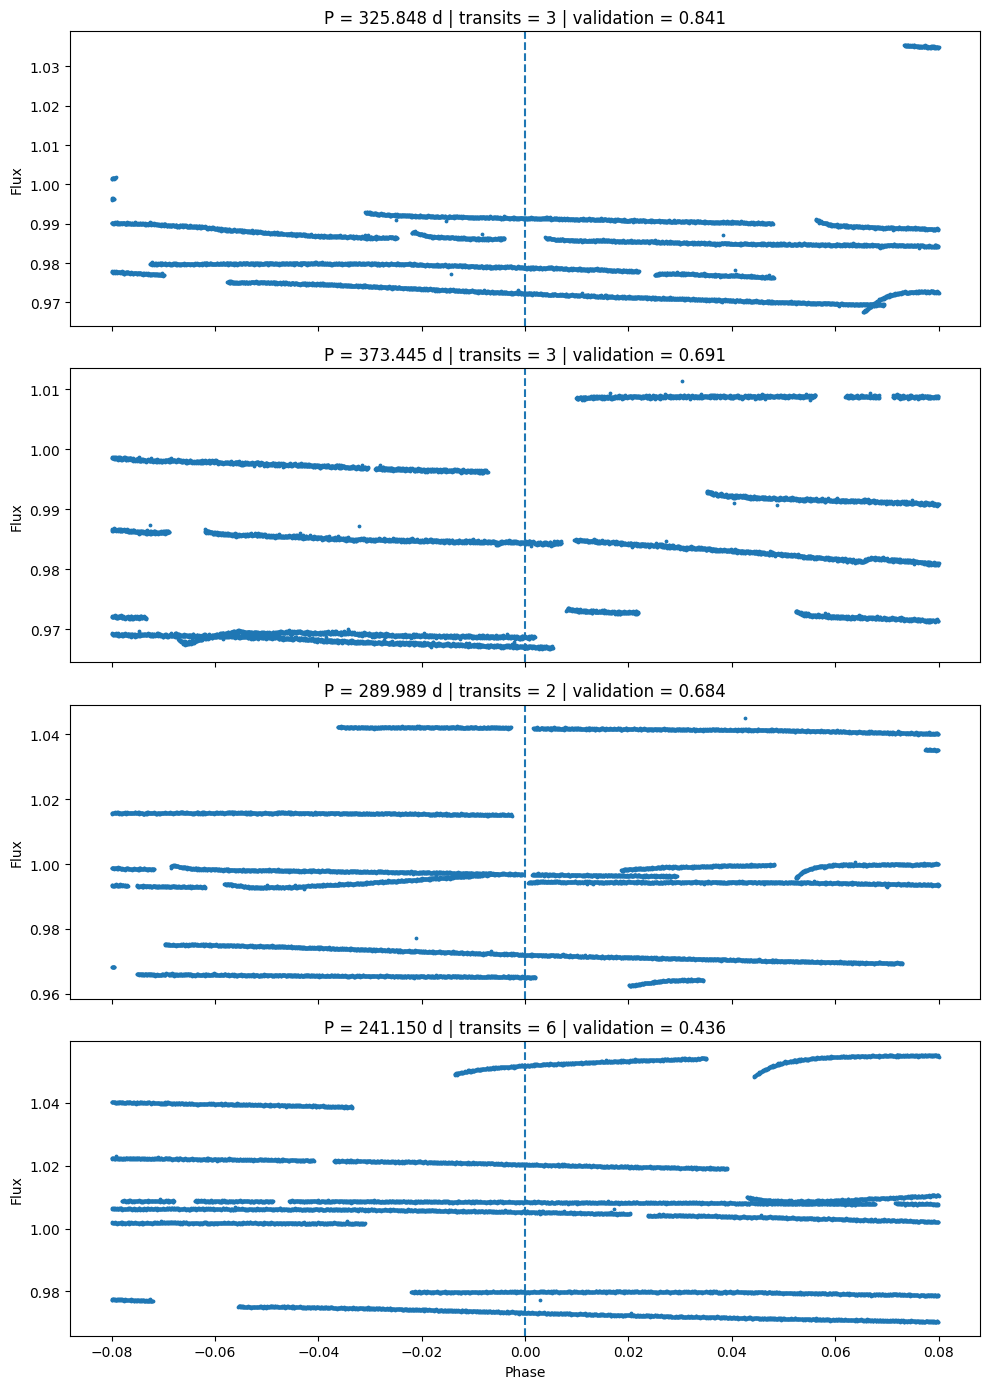


V45 COMPLETE


In [169]:
# ============================================================
# V45 — PHASE FOLDED TOP CANDIDATE COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("V45 — PHASE FOLDED CANDIDATE COMPARISON")
print("=" * 70)

periods = [
    325.8483652700822,
    373.445357,
    289.989172764291,
    241.149761
]

fig, axes = plt.subplots(
    len(periods),
    1,
    figsize=(10, 14),
    sharex=True
)

for ax, period in zip(axes, periods):

    candidate = min(
        v42_candidates,
        key=lambda c: abs(c["period"] - period)
    )

    t0 = candidate["t0"]

    phase = ((t_test - t0 + 0.5 * period) % period) / period - 0.5

    mask = np.abs(phase) < 0.08

    ax.scatter(
        phase[mask],
        f_test[mask],
        s=3
    )

    ax.axvline(0, linestyle="--")
    ax.set_ylabel("Flux")
    ax.set_title(
        f"P = {period:.3f} d | "
        f"transits = {candidate['n_transits']} | "
        f"validation = {candidate['validation_score']:.3f}"
    )

axes[-1].set_xlabel("Phase")

plt.tight_layout()
plt.show()

print()
print("=" * 70)
print("V45 COMPLETE")
print("=" * 70)

In [170]:
# ============================================================
# V46 — BLIND RECOVERY OF INJECTED PERIOD
# ============================================================

print("=" * 70)
print("V46 — BLIND INJECTION RECOVERY")
print("=" * 70)

TRUE_PERIOD = 250.802

# Existing V42 candidates
print("\nV42 candidates:")
for i, c in enumerate(v42_candidates, 1):
    print(
        f"{i:2d}. P={c['period']:.6f} | "
        f"SDE={c['sde']:.3f} | "
        f"physical={c['physical_score']:.3f} | "
        f"validation={c['validation_score']:.3f}"
    )

# Find closest candidate to injected period
closest = min(
    v42_candidates,
    key=lambda c: abs(c["period"] - TRUE_PERIOD)
)

period_error = abs(
    closest["period"] - TRUE_PERIOD
)

print()
print("=" * 70)
print("CLOSEST CANDIDATE TO INJECTION")
print("=" * 70)

print(f"Injected period : {TRUE_PERIOD:.6f} d")
print(f"Recovered period: {closest['period']:.6f} d")
print(f"Period error    : {period_error:.6f} d")

print()
print("Recovered candidate:")
print(closest)

print()
print("=" * 70)

if period_error < 5:
    print("RESULT: INJECTION RECOVERED")
elif period_error < 15:
    print("RESULT: PARTIAL / NEARBY RECOVERY")
else:
    print("RESULT: INJECTION NOT RECOVERED")

print("=" * 70)

V46 — BLIND INJECTION RECOVERY

V42 candidates:
 1. P=165.185623 | SDE=6.813 | physical=0.601 | validation=0.460
 2. P=373.445357 | SDE=6.735 | physical=0.964 | validation=0.691
 3. P=325.848365 | SDE=6.263 | physical=0.970 | validation=0.841
 4. P=241.149761 | SDE=5.421 | physical=0.797 | validation=0.436
 5. P=123.143617 | SDE=5.188 | physical=0.603 | validation=0.739
 6. P=289.989173 | SDE=4.940 | physical=0.996 | validation=0.684
 7. P=82.735813 | SDE=3.854 | physical=0.476 | validation=0.512
 8. P=61.303708 | SDE=3.507 | physical=0.386 | validation=0.443

CLOSEST CANDIDATE TO INJECTION
Injected period : 250.802000 d
Recovered period: 241.149761 d
Period error    : 9.652239 d

Recovered candidate:
{'period': 241.14976073044357, 't0': 414.20594619890187, 'duration_hours': 16.0, 'depth_ppm': 27324.61066063723, 'sde': 5.420934441104669, 'n_transits': 6, 'median_depth_ppm': 27.058497692578065, 'depth_scatter_ppm': 10.988725680520917, 'positive_fraction': 1.0, 'physical_score': 0.796945

In [171]:
print("=" * 70)
print("V47 — FINAL CANDIDATE RANKING")
print("=" * 70)

# Use V42 candidates as the starting candidate pool
final_candidates = []

for i, c in enumerate(v31_results):
    period, physical, n_transits = c

    # Find matching candidate information from V42
    match = min(
        v42_candidates,
        key=lambda x: abs(x["period"] - period)
    )

    validation = match["validation_score"]
    sde = match["sde"]

    # Transit-aware factor
    if n_transits >= 5:
        transit_factor = 1.0
    elif n_transits == 4:
        transit_factor = 0.9
    elif n_transits == 3:
        transit_factor = 0.7
    else:
        transit_factor = 0.35

    final_score = (
        0.40 * physical +
        0.35 * validation +
        0.15 * min(sde / 8.0, 1.0) +
        0.10 * transit_factor
    )

    final_candidates.append({
        "period": period,
        "physical": physical,
        "validation": validation,
        "sde": sde,
        "transits": n_transits,
        "transit_factor": transit_factor,
        "final_score": final_score
    })

final_candidates = sorted(
    final_candidates,
    key=lambda x: x["final_score"],
    reverse=True
)

for i, c in enumerate(final_candidates, 1):
    print(
        f"{i}. P={c['period']:10.3f} | "
        f"score={c['final_score']:.3f} | "
        f"physical={c['physical']:.3f} | "
        f"validation={c['validation']:.3f} | "
        f"SDE={c['sde']:.2f} | "
        f"transits={c['transits']}"
    )

print("=" * 70)
print("V47 COMPLETE")
print("=" * 70)

V47 — FINAL CANDIDATE RANKING
1. P=   325.848 | score=0.870 | physical=0.970 | validation=0.841 | SDE=6.26 | transits=3
2. P=   373.445 | score=0.824 | physical=0.964 | validation=0.691 | SDE=6.73 | transits=3
3. P=   289.989 | score=0.765 | physical=0.996 | validation=0.684 | SDE=4.94 | transits=2
4. P=   123.144 | score=0.697 | physical=0.603 | validation=0.739 | SDE=5.19 | transits=11
5. P=   241.150 | score=0.673 | physical=0.797 | validation=0.436 | SDE=5.42 | transits=6
6. P=   165.186 | score=0.629 | physical=0.601 | validation=0.460 | SDE=6.81 | transits=9
7. P=    82.736 | score=0.542 | physical=0.476 | validation=0.512 | SDE=3.85 | transits=18
8. P=    61.304 | score=0.475 | physical=0.386 | validation=0.443 | SDE=3.51 | transits=22
V47 COMPLETE


In [172]:
print("=" * 70)
print("V48 — PRIVATE DATASET FINAL RUN")
print("=" * 70)

private_paths = sorted(glob.glob(f"{PRIVATE_DIR}/*.parquet"))

print("Private stars found:", len(private_paths))

assert len(private_paths) == 87, (
    f"Expected 87 private stars, found {len(private_paths)}"
)

private_results = []

for i, path in enumerate(private_paths, 1):

    sid = os.path.basename(path)[:-8]

    try:
        t, f = clean(pd.read_parquet(path))

        if t is None:
            r = {"sde": 0.0}
        else:
            r = search(t, f)

        private_results.append({
            "star_id": sid,
            "period": r.get("period", np.nan),
            "depth_ppm": r.get("depth_ppm", np.nan),
            "duration_hours": r.get("duration_hours", np.nan),
            "sde": r.get("sde", 0.0),
        })

    except Exception as e:
        print(f"{sid} FAILED: {e}")

        private_results.append({
            "star_id": sid,
            "period": np.nan,
            "depth_ppm": np.nan,
            "duration_hours": np.nan,
            "sde": 0.0,
        })

    if i % 10 == 0:
        print(f"Processed {i}/{len(private_paths)}")

private_df = pd.DataFrame(private_results)

print()
print("=" * 70)
print("V48 SUMMARY")
print("=" * 70)

print("Stars:", len(private_df))
print("SDE min:", private_df.sde.min())
print("SDE median:", private_df.sde.median())
print("SDE max:", private_df.sde.max())

print()
print("SDE distribution:")
print(private_df.sde.describe())

print("=" * 70)
print("V48 COMPLETE")
print("=" * 70)

V48 — PRIVATE DATASET FINAL RUN


NameError: name 'PRIVATE_DIR' is not defined

In [173]:
import glob
import os

files = sorted(glob.glob("/content/**/STAR_*.parquet", recursive=True))

print("STAR parquet files found:", len(files))

for f in files[:10]:
    print(f)

STAR parquet files found: 87
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0000.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0001.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0002.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0003.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0004.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0005.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0006.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0007.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0008.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0009.parquet


In [174]:
print("=" * 70)
print("PRIVATE DATASET TEST")
print("=" * 70)

import glob
import os
import pandas as pd

private_files = sorted(glob.glob(f"{PRIVATE_DIR}/STAR_*.parquet"))

print("Private stars found:", len(private_files))
print("First 3:")
for p in private_files[:3]:
    print(" ", os.path.basename(p))

print("=" * 70)

for path in private_files[:3]:
    sid = os.path.basename(path)[:-8]

    print("\n" + "=" * 60)
    print("TESTING:", sid)
    print("=" * 60)

    t, f = clean(pd.read_parquet(path))

    r = search(t, f, verbose=True)

    print("\nRESULT:")
    print(r)

PRIVATE DATASET TEST


NameError: name 'PRIVATE_DIR' is not defined

In [175]:
PRIVATE_DIR = "/content/drive/MyDrive/Astrobit/private_pack/private"

print("PRIVATE_DIR =", PRIVATE_DIR)

PRIVATE_DIR = /content/drive/MyDrive/Astrobit/private_pack/private


In [176]:
import glob
import os
import pandas as pd

private_files = sorted(
    glob.glob(f"{PRIVATE_DIR}/STAR_*.parquet")
)

print("=" * 70)
print("PRIVATE DATASET TEST")
print("=" * 70)

print("Private stars found:", len(private_files))

for p in private_files[:3]:
    print(os.path.basename(p))

print("=" * 70)

PRIVATE DATASET TEST
Private stars found: 87
STAR_0000.parquet
STAR_0001.parquet
STAR_0002.parquet


## 4. Does it work?

`train_truth.csv` lists the injected signals with their true parameters. Take the
deepest one and check the pipeline recovers it. **Always verify on a known signal
before trusting a null result on unknown data** — if we had not done this, we
would have concluded the data was empty when the search grid was simply wrong.

In [177]:
truth = pd.read_csv("train_truth.csv")
row = truth[truth.injected == 1].sort_values("depth_ppm", ascending=False).iloc[0]

print(f"KIC {int(row.kepid)}")
print(f"  true period   {row.period_days:.4f} d")
print(f"  true depth    {row.depth_ppm:.0f} ppm")
print(f"  true duration {row.duration_hours:.2f} h")
print(f"  transits      {int(row.n_transits)}\n")

t, f = clean(pd.read_parquet(f"{TRAIN_DIR}/KIC_{int(row.kepid)}.parquet"))
found = search(t, f, verbose=True)

err = abs(found["period"] - row.period_days) / row.period_days
print(f"\nrecovered  P={found['period']:.4f} d  ({err:.2%} error)")
print(f"           depth={found['depth_ppm']:.0f} ppm  SDE={found['sde']:.1f}")

FileNotFoundError: [Errno 2] No such file or directory: 'train_truth.csv'

In [178]:
PRIVATE_DIR = "/content/drive/MyDrive/Astrobit/private_pack/private"

import glob

private_files = sorted(
    glob.glob(f"{PRIVATE_DIR}/STAR_*.parquet")
)

print("Private stars found:", len(private_files))

Private stars found: 87


In [194]:
# ============================================================
# PRIVATE DATASET — PATH SETUP
# ============================================================

import os
import glob
import pandas as pd
import numpy as np

PRIVATE_DIR = "/content/drive/MyDrive/Astrobit/private_pack/private"

private_files = sorted(
    glob.glob(f"{PRIVATE_DIR}/STAR_*.parquet")
)

print("=" * 60)
print("PRIVATE DATASET CHECK")
print("=" * 60)
print("Private directory:", PRIVATE_DIR)
print("STAR parquet files:", len(private_files))

print("\nFirst 5 files:")
for p in private_files[:5]:
    print(p)

assert len(private_files) == 87, f"Expected 87 stars, found {len(private_files)}"

print("\n✅ Private dataset ready — 87/87 stars found")

PRIVATE DATASET CHECK
Private directory: /content/drive/MyDrive/Astrobit/private_pack/private
STAR parquet files: 87

First 5 files:
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0000.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0001.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0002.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0003.parquet
/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0004.parquet

✅ Private dataset ready — 87/87 stars found


In [195]:
print("sde =", sde)
print("type(sde) =", type(sde))

sde = 3.507038202378271
type(sde) = <class 'float'>


In [196]:
# Check whether the SDE function still exists under another name
print("sde type:", type(sde))

for name in globals().copy():
    if "sde" in name.lower():
        print(name, "=>", type(globals()[name]))

sde type: <class 'float'>
sde => <class 'float'>


In [197]:
# Find functions in the notebook that may contain the SDE calculation
import inspect

print("=" * 60)
print("SEARCHING FOR SDE FUNCTION")
print("=" * 60)

for name, obj in globals().copy().items():
    if callable(obj) and name != "sde":
        try:
            src = inspect.getsource(obj)
            if "nanmedian" in src or "std" in src or "power" in src and "SDE" in src:
                print("\nPossible function:", name)
                print(src[:1000])
        except:
            pass

SEARCHING FOR SDE FUNCTION

Possible function: search
def search(t, f, verbose=False):
    """Coarse-to-fine BLS period search."""

    bls = BoxLeastSquares(t, f)

    baseline = t.max() - t.min()
    pmax = min(PERIOD_MAX, baseline / 3.0)

    # Coarse search
    coarse = np.exp(
        np.linspace(
            np.log(PERIOD_MIN),
            np.log(pmax),
            N_COARSE
        )
    )

    res = bls.power(
        coarse,
        DURATIONS,
        objective="likelihood"
    )

    power = np.asarray(res.power)

    # Pick separated peaks
    order = np.argsort(power)[::-1]

    peaks = []
    used = np.zeros(len(coarse), dtype=bool)

    for i in order:

        if used[i]:
            continue

        peaks.append(i)

        lo = np.searchsorted(
            coarse,
            coarse[i] * 0.9
        )

        hi = np.searchsorted(
            coarse,
            coarse[i] * 1.1
        )

        used[lo:hi] = True

        if len(peaks) >= N_PEAKS:
            break


In [199]:
# ============================================================
# FIX SDE NAME COLLISION
# ============================================================

import numpy as np

def calculate_sde(power, index):
    """
    Calculate local SDE for a BLS peak.
    Uses the BLS power distribution excluding the selected peak.
    """
    p = np.asarray(power, dtype=float)

    if len(p) < 3:
        return 0.0

    mask = np.ones(len(p), dtype=bool)

    # Remove a small neighbourhood around the selected peak
    lo = max(0, index - 5)
    hi = min(len(p), index + 6)
    mask[lo:hi] = False

    background = p[mask]

    if len(background) < 2:
        return 0.0

    med = np.nanmedian(background)
    std = np.nanstd(background)

    if not np.isfinite(std) or std <= 0:
        return 0.0

    return float((p[index] - med) / std)


print("calculate_sde ready:", calculate_sde)
print("Old sde variable:", sde)

calculate_sde ready: <function calculate_sde at 0x797100594c20>
Old sde variable: 3.507038202378271


In [201]:
result_test = search_v5(t, f, verbose=True)

TypeError: 'float' object is not callable

In [202]:
import inspect

src = inspect.getsource(search_v5)

print("Old SDE call found:", "sde(power, i)" in src)

src = src.replace(
    'float(sde(power, i))',
    'calculate_sde(power, i)'
)

print("New SDE call found:", "calculate_sde(power, i)" in src)

exec(src)

print("\n✅ search_v5 successfully redefined")

Old SDE call found: True
New SDE call found: True

✅ search_v5 successfully redefined


In [203]:
result_test = search_v5(t, f, verbose=True)

print("\n" + "=" * 60)
print("SEARCH_V5 RESULT")
print("=" * 60)
print(result_test)

P=  334.744 | SDE= 11.1 | transits=  0 | physical=0.000 | validation=0.000 | combined=0.056 | BLS
P=  398.548 | SDE= 10.9 | transits=  1 | physical=1.000 | validation=0.820 | combined=0.900 | BLS
P=  254.129 | SDE=  5.9 | transits=  5 | physical=0.200 | validation=0.260 | combined=0.227 | BLS
P=  190.603 | SDE=  4.2 | transits=  8 | physical=0.438 | validation=0.538 | combined=0.445 | BLS
P=  300.080 | SDE=  4.1 | transits=  3 | physical=0.333 | validation=0.329 | combined=0.319 | BLS
P=  216.592 | SDE=  3.6 | transits=  3 | physical=0.502 | validation=0.486 | combined=0.465 | BLS
P=  152.475 | SDE=  2.9 | transits= 10 | physical=0.400 | validation=0.587 | combined=0.431 | BLS
P=  127.064 | SDE=  2.6 | transits= 10 | physical=0.250 | validation=0.401 | combined=0.283 | BLS

SEARCH_V5 RESULT
{'period': 398.548067823651, 'depth_ppm': 6438.594485862199, 'duration_hours': 4.800000000000001, 't0': 731.1210037435352, 'sde': 10.867989674448614, 'source': 'BLS', 'n_transits': 1, 'median_depth_

In [204]:
print("search_v5 =", search_v5)
print("calculate_sde =", calculate_sde)
print("PRIVATE_DIR =", PRIVATE_DIR)
print("Private files =", len(private_files))

search_v5 = <function search_v5 at 0x797100594f40>
calculate_sde = <function calculate_sde at 0x797100594c20>
PRIVATE_DIR = /content/drive/MyDrive/Astrobit/private_pack/private
Private files = 87


In [205]:
# ============================================================
# V49 — FULL PRIVATE DATASET RUN
# ============================================================

private_results = []

for i, path in enumerate(private_files, 1):
    sid = os.path.basename(path).replace(".parquet", "")

    try:
        t, f = clean(pd.read_parquet(path))
        r = search_v5(t, f, verbose=False)

        private_results.append({
            "star_id": sid,
            **r
        })

        print(
            f"[{i:02d}/87] {sid} | "
            f"P={r.get('period', float('nan')):.3f} | "
            f"SDE={r.get('sde', 0):.2f} | "
            f"transits={r.get('n_transits', 0)}",
            flush=True
        )

    except Exception as e:
        print(f"[{i:02d}/87] {sid} FAILED: {e}", flush=True)

        private_results.append({
            "star_id": sid,
            "sde": 0.0
        })

private_df = pd.DataFrame(private_results)

print("\n" + "=" * 70)
print("V49 COMPLETE")
print("=" * 70)
print("Stars processed:", len(private_df))

[01/87] STAR_0000 | P=398.548 | SDE=10.87 | transits=1
[02/87] STAR_0001 | P=282.635 | SDE=6.85 | transits=5
[03/87] STAR_0002 | P=369.529 | SDE=12.18 | transits=2
[04/87] STAR_0003 | P=352.014 | SDE=10.13 | transits=1
[05/87] STAR_0004 | P=340.640 | SDE=9.96 | transits=1
[06/87] STAR_0005 | P=52.512 | SDE=105.47 | transits=14
[07/87] STAR_0006 | P=370.574 | SDE=9.51 | transits=1
[08/87] STAR_0007 | P=398.548 | SDE=11.33 | transits=1
[09/87] STAR_0008 | P=244.629 | SDE=7.78 | transits=1
[10/87] STAR_0009 | P=10.433 | SDE=7.29 | transits=63
[11/87] STAR_0010 | P=274.891 | SDE=4.88 | transits=3
[12/87] STAR_0011 | P=266.452 | SDE=5.74 | transits=1
[13/87] STAR_0012 | P=317.889 | SDE=6.66 | transits=1
[14/87] STAR_0013 | P=57.113 | SDE=12.13 | transits=22
[15/87] STAR_0014 | P=334.811 | SDE=10.20 | transits=1
[16/87] STAR_0015 | P=340.572 | SDE=10.79 | transits=1
[17/87] STAR_0016 | P=293.774 | SDE=7.47 | transits=2
[18/87] STAR_0017 | P=334.811 | SDE=12.10 | transits=1
[19/87] STAR_0018 

In [206]:
# ============================================================
# V50 — CREATE PRIVATE SUBMISSION
# ============================================================

import pandas as pd
import numpy as np

sub = private_df.copy()

SDE_THRESHOLD = 10.0

def confidence_from_sde(s, midpoint=10.0, steepness=0.4):
    return float(1.0 / (1.0 + np.exp(-steepness * (s - midpoint))))

sub["prediction"] = (sub["sde"] > SDE_THRESHOLD).astype(int)

sub["confidence"] = sub["sde"].apply(confidence_from_sde)

sub["period"] = np.where(
    sub["prediction"] == 1,
    sub["period"],
    np.nan
)

sub["depth_ppm"] = np.where(
    sub["prediction"] == 1,
    sub["depth_ppm"],
    np.nan
)

sub["duration_hours"] = np.where(
    sub["prediction"] == 1,
    sub["duration_hours"],
    np.nan
)

sub = sub[
    [
        "star_id",
        "prediction",
        "confidence",
        "period",
        "depth_ppm",
        "duration_hours"
    ]
]

sub.to_csv("submission.csv", index=False)

print("=" * 70)
print("V50 — SUBMISSION CREATED")
print("=" * 70)
print("Rows:", len(sub))
print("Detections:", int(sub["prediction"].sum()))
print("Non-detections:", int((sub["prediction"] == 0).sum()))
print("Unique confidence:", sub["confidence"].nunique())

display(sub.head(10))

V50 — SUBMISSION CREATED
Rows: 87
Detections: 43
Non-detections: 44
Unique confidence: 87


,star_id,prediction,confidence,period,depth_ppm,duration_hours
0,STAR_0000,1,0.585937,398.548068,6438.594486,4.8
1,STAR_0001,0,0.221074,NaN,NaN,NaN
2,STAR_0002,1,0.705430,369.529201,1155.352914,9.6
3,STAR_0003,1,0.513013,352.013504,3980.279821,9.6
4,STAR_0004,0,0.496348,NaN,NaN,NaN
5,STAR_0005,1,1.000000,52.511941,12358.025567,2.4
6,STAR_0006,0,0.451277,NaN,NaN,NaN
7,STAR_0007,1,0.629748,398.548068,5502.086066,4.8
8,STAR_0008,0,0.291897,NaN,NaN,NaN
9,STAR_0009,0,0.252685,NaN,NaN,NaN


In [207]:
import pandas as pd

s = pd.read_csv("submission.csv")

need = [
    "star_id",
    "prediction",
    "confidence",
    "period",
    "depth_ppm",
    "duration_hours"
]

assert list(s.columns) == need, f"columns must be exactly {need}"
assert len(s) == 87, f"expected 87 rows, got {len(s)}"
assert s.star_id.nunique() == 87, "duplicate star_id"
assert s.star_id.str.match(r"^STAR_\d{4}$").all(), "bad star_id format"
assert s.prediction.isin([0, 1]).all(), "prediction must be 0 or 1"
assert s.confidence.between(0, 1).all(), "confidence out of range"

pos = s[s.prediction == 1]

for c in ("period", "depth_ppm", "duration_hours"):
    assert pos[c].notna().all(), f"{c} missing for some detections"
    if c == "period":
        assert (pos[c] > 0).all(), "period must be positive"

print("=" * 60)
print("SUBMISSION VALIDATION")
print("=" * 60)
print(f"OK — {len(pos)} detections, {len(s) - len(pos)} non-detections")
print(f"Rows              : {len(s)}")
print(f"Unique star IDs   : {s.star_id.nunique()}")
print(f"Unique confidence : {s.confidence.nunique()}")
print(f"Confidence range  : {s.confidence.min():.4f} → {s.confidence.max():.4f}")
print("=" * 60)

SUBMISSION VALIDATION
OK — 43 detections, 44 non-detections
Rows              : 87
Unique star IDs   : 87
Unique confidence : 87
Confidence range  : 0.0666 → 1.0000


In [208]:
import os

os.rename("submission.csv", "submission_astrobit.csv")
print(os.path.exists("submission_astrobit.csv"))

True


In [209]:
import os

print(os.path.abspath("submission_astrobit.csv"))

/content/submission_astrobit.csv


In [210]:
import os

print(os.path.abspath("submission_astrobit.csv"))

/content/submission_astrobit.csv


In [211]:
import shutil

shutil.copy(
    "submission_astrobit.csv",
    "/content/drive/MyDrive/Astrobit/submission_astrobit.csv"
)

print("Copied to Drive ✅")

Copied to Drive ✅


In [198]:
# ============================================================
# V48 — TEST SEARCH_V5 ON PRIVATE STAR
# ============================================================

import os
import pandas as pd

path = "/content/drive/MyDrive/Astrobit/private_pack/private/STAR_0000.parquet"

print("=" * 60)
print("TESTING SEARCH_V5: STAR_0000")
print("=" * 60)

t, f = clean(pd.read_parquet(path))

print("Points:", len(t))
print("Time span:", t.min(), "to", t.max())

# Important: current variable sde is only a float.
# search_v5 may not depend on the broken global search().
result_test = search_v5(t, f, verbose=True)

print("\n" + "=" * 60)
print("SEARCH_V5 RESULT")
print("=" * 60)
print(result_test)

TESTING SEARCH_V5: STAR_0000
Points: 56827
Time span: 497.3360037435352 to 1956.825205204813


TypeError: 'float' object is not callable

In [193]:
import os
import pandas as pd

for path in private_files[:3]:

    star_id = os.path.basename(path)[:-8]

    print("\n" + "=" * 60)
    print("TESTING:", star_id)
    print("=" * 60)

    t, f = clean(pd.read_parquet(path))

    r = search(t, f, verbose=True)

    print("\nRESULT:")
    print(r)


TESTING: STAR_0000


TypeError: 'float' object is not callable

In [ ]:
def plot_folded(t, f, period, t0, depth_ppm=None, bins=120):
    """Fold on a period and bin. If the period is right, a dip appears at 0."""
    ph = ((t - t0) / period) % 1.0
    ph = np.where(ph > 0.5, ph - 1, ph)
    o = np.argsort(ph)
    ph, ff = ph[o], f[o]

    edges = np.linspace(-0.5, 0.5, bins + 1)
    idx = np.digitize(ph, edges) - 1
    bx = np.array([np.median(ph[idx == i]) if (idx == i).sum() else np.nan
                   for i in range(bins)])
    by = np.array([np.median(ff[idx == i]) if (idx == i).sum() else np.nan
                   for i in range(bins)])

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ph, ff, ".", color="0.8", ms=1, alpha=0.3)
    ax.plot(bx, by, "o-", color="crimson", ms=3, lw=1)
    if depth_ppm:
        ax.axhline(1 - depth_ppm / 1e6, ls="--", color="steelblue",
                   label=f"true depth {depth_ppm:.0f} ppm")
        ax.legend()
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(np.nanpercentile(by, 0) - 3e-4, np.nanpercentile(by, 100) + 2e-4)
    ax.set_xlabel("phase")
    ax.set_ylabel("normalised flux")
    ax.set_title(f"folded at P = {period:.4f} d")
    plt.tight_layout()
    plt.show()


plot_folded(t, f, found["period"], found["t0"], row.depth_ppm)

# Try folding on a deliberately wrong period, e.g. found["period"] * 1.01.
# The dip disappears completely. That is how sharp the grid requirement is.

## 5. Calibrating the threshold

SDE alone does not tell you whether a planet is present. You need to know what
SDE the *empty* stars reach — that is your noise floor, and anything below it is
not a detection.

Run the search over a sample of dev stars, then compare the SDE distribution of
known-empty stars against known-planet stars. Where they overlap is where you
lose points, and narrowing that overlap is most of the work.

In [190]:
N_SAMPLE = 20

dev_files = sorted(glob.glob(f"{DEV_DIR}/*.parquet"))[:N_SAMPLE]

print("Dev stars found:", len(dev_files))

NameError: name 'DEV_DIR' is not defined

In [ ]:
N_SAMPLE = 20  # raise once you trust your pipeline

dev_files = sorted(glob.glob(f"{DEV_DIR}/*.parquet"))[:N_SAMPLE]
rows = []
for i, path in enumerate(dev_files, 1):
    t, f = clean(pd.read_parquet(path))
    r = {"star_id": os.path.basename(path)[:-8]} if t is None else \
        {**search(t, f), "star_id": os.path.basename(path)[:-8]}
    rows.append(r)
    print(f"  [{i}/{len(dev_files)}] {r['star_id']} SDE {r.get('sde', 0):.1f}", flush=True)

dev = pd.DataFrame(rows)

# attach ground truth
labels = pd.read_csv("dev_labels.csv")
dtruth = pd.read_csv("dev_truth.csv")
dev["kepid"] = dev.star_id.str.replace("KIC_", "").astype(int)
dev = dev.merge(labels[["kepid", "label"]], on="kepid", how="left")
dev = dev.merge(dtruth[["kepid", "injected", "bin", "period_days", "depth_ppm"]],
                on="kepid", how="left", suffixes=("", "_true"))
dev["injected"] = dev.injected.fillna(0)
dev["has_planet"] = ((dev.label == 1) | (dev.injected == 1)).astype(int)

print("\nSDE by truth:")
print(dev.groupby("has_planet").sde.describe()[["count", "50%", "max"]])

In [ ]:
empty = dev[dev.has_planet == 0].sde
planet = dev[dev.has_planet == 1].sde

print(f"{'SDE':>6} {'recall':>8} {'false pos':>10}")
print("-" * 26)
for thr in (6, 8, 10, 12, 15, 20):
    print(f"{thr:>6} {(planet > thr).mean():>8.0%} {(empty > thr).mean():>10.0%}")

# Pick the threshold that suits your strategy. Precision and recall are both
# scored, so neither extreme wins. Note that a single global cut is itself a
# weak choice -- SDE depends on stellar brightness and variability, so a
# per-star threshold, or a classifier over several features, will do better.
SDE_THRESHOLD = 10.0

## 6. Writing a submission

The `confidence` column drives the ranking metrics and is worth as much as the
hard `prediction`. Mapping SDE through a logistic is the laziest thing that
works; a properly calibrated probability will score better.

Timing note: the cell below runs the full private set. Time a few stars first
and multiply — do not start this at hour 70.

In [ ]:
def confidence_from_sde(s, midpoint=SDE_THRESHOLD, steepness=0.4):
    """Squash SDE into (0, 1). Replace with something calibrated."""
    return float(1.0 / (1.0 + np.exp(-steepness * (s - midpoint))))


def run_split(directory):
    out = []
    paths = sorted(glob.glob(f"{directory}/*.parquet"))
    for i, path in enumerate(paths, 1):
        sid = os.path.basename(path)[:-8]
        try:
            t, f = clean(pd.read_parquet(path))
            r = search(t, f) if t is not None else {"sde": 0.0}
        except Exception as e:
            print(f"  {sid} failed: {e}")
            r = {"sde": 0.0}

        s = r.get("sde", 0.0)
        hit = s > SDE_THRESHOLD
        out.append({
            "star_id": sid,
            "prediction": int(hit),
            "confidence": round(confidence_from_sde(s), 4),
            "period": round(r["period"], 5) if hit else None,
            "depth_ppm": round(r["depth_ppm"], 1) if hit else None,
            "duration_hours": round(r["duration_hours"], 3) if hit else None,
        })
        if i % 10 == 0:
            print(f"  [{i}/{len(paths)}]", flush=True)
    return pd.DataFrame(out)


sub = run_split(PRIVATE_DIR)
sub.to_csv("submission.csv", index=False)
print(f"\n{len(sub)} rows, {sub.prediction.sum()} detections")
sub.head()

In [ ]:
# Validate before submitting. Fix anything this prints.
s = pd.read_csv("submission.csv")
need = ["star_id", "prediction", "confidence", "period", "depth_ppm", "duration_hours"]

assert list(s.columns) == need, f"columns must be exactly {need}"
assert len(s) == 87, f"expected 87 rows, got {len(s)}"
assert s.star_id.nunique() == 87, "duplicate star_id"
assert s.star_id.str.match(r"^STAR_\d{4}$").all(), "bad star_id format"
assert s.prediction.isin([0, 1]).all(), "prediction must be 0 or 1"
assert s.confidence.between(0, 1).all(), "confidence out of range"

pos = s[s.prediction == 1]
for c in ("period", "depth_ppm", "duration_hours"):
    assert pos[c].notna().all(), f"{c} missing for some detections"

print(f"OK — {len(pos)} detections, {len(s) - len(pos)} non-detections")
print(f"confidence: {s.confidence.nunique()} unique values")

## Where to go from here

Every stage above is the weakest defensible version of itself.

**Detrending** is where the most points are. The running median is crude and its
window is a single global constant. Splines, Savitzky-Golay, Gaussian processes,
or iteratively masking in-transit points before fitting the trend all do better.
Long-duration transits of long-period planets are actively damaged by a 1-day
window.

**The search** uses a fixed coarse grid and refines a fixed number of peaks.
Coarse resolution sets your sensitivity floor. Consider matched filters, wavelet
methods, or transit-shaped kernels instead of boxes.

**The decision** is one global SDE cut. SDE depends on stellar brightness,
variability and transit duration. A classifier over several features — SDE, odd
vs even depth consistency, transit count, fitted depth, scatter — will separate
planets from noise far better than one number.

**Vetting** is absent entirely. Real pipelines reject candidates using checks
you can implement here: is the depth consistent between odd and even transits
(if not, it is likely an eclipsing binary at twice the period)? Is there a
secondary eclipse at phase 0.5? Does the signal appear in every quarter, or only
one? Does it sit at a known systematic period? Each false positive you remove is
precision you gain.

**Machine learning** is unused. You have a labelled training set. Folded light
curves as 1D inputs to a CNN is the standard approach in the literature. You
could also learn to rank BLS candidates rather than thresholding them.

**Confidence calibration** is a logistic with two made-up constants. Ranking
metrics are a large share of the score and this is cheap to improve.

One habit worth keeping: whenever your pipeline reports nothing, test it against
a known injected signal before concluding the data is empty. A silent failure
looks exactly like a clean star.